# SDV Models: Comprehensive Evaluation

This notebook contains a comprehensive evaluation of four synthetic data generation models:
1. **CTGAN** - Conditional Tabular GAN
2. **CopulaGAN** - GAN-based with copula modeling
3. **Gaussian Copula** - Statistical copula-based approach
4. **TVAE** - Tabular Variational Autoencoder

Each model is evaluated using multiple fidelity metrics including KS test, JS divergence, Wasserstein distance, and more.


# SDV Models: Comprehensive Evaluation

This notebook contains a comprehensive evaluation of four synthetic data generation models:
1. **CTGAN** - Conditional Tabular GAN
2. **CopulaGAN** - GAN-based with copula modeling
3. **Gaussian Copula** - Statistical copula-based approach
4. **TVAE** - Tabular Variational Autoencoder

Each model is evaluated using multiple fidelity metrics including KS test, JS divergence, Wasserstein distance, and more.


## Data Loading and Setup


In [1]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
bank_marketing = fetch_ucirepo(id=222) 
  
# data (as pandas dataframes) 
X = bank_marketing.data.features 
y = bank_marketing.data.targets 
  
# metadata 
print(bank_marketing.metadata) 
  
# variable information 
print(bank_marketing.variables)

{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

In [2]:
import pandas as pd

data = pd.concat([X, y], axis=1)
data.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no
5,35,management,married,tertiary,no,231,yes,no,NaN,5,may,139,1,-1,0,NaN,no
6,28,management,single,tertiary,no,447,yes,yes,NaN,5,may,217,1,-1,0,NaN,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,NaN,5,may,380,1,-1,0,NaN,no
8,58,retired,married,primary,no,121,yes,no,NaN,5,may,50,1,-1,0,NaN,no
9,43,technician,single,secondary,no,593,yes,no,NaN,5,may,55,1,-1,0,NaN,no


In [3]:
# for quick computaiton we are considering first 10000 sample 

data = data.sample(n=10000, random_state=48)

# Generating synthetic data

In [4]:
import pandas as pd, warnings
warnings.filterwarnings('ignore')
from sdv.metadata import SingleTableMetadata
from sdv.single_table import (
    CTGANSynthesizer,
    CopulaGANSynthesizer,
    TVAESynthesizer,
    GaussianCopulaSynthesizer
)
from sdv.evaluation.single_table import evaluate_quality, run_diagnostic

# If already loaded, keep this line out
# data = pd.read_csv("bank_marketing.csv", sep=";")

data.columns = data.columns.str.strip()

# Feature columns + binary target
columns_to_use = [
    "age", "job", "marital", "education", "default", "balance",
    "housing", "loan", "contact", "day_of_week", "month",
    "duration", "campaign", "pdays", "previous", "poutcome", "y"
]

data = data[columns_to_use].copy()

# Build metadata
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data)

# Explicit schema for Bank Marketing dataset
column_sdtypes = {
    "age": "numerical",
    "job": "categorical",
    "marital": "categorical",
    "education": "categorical",
    "default": "categorical",
    "balance": "numerical",
    "housing": "categorical",
    "loan": "categorical",
    "contact": "categorical",
    "day_of_week": "categorical",
    "month": "categorical",
    "duration": "numerical",
    "campaign": "numerical",
    "pdays": "numerical",
    "previous": "numerical",
    "poutcome": "categorical",
    "y": "categorical"
}

for col, sdtype in column_sdtypes.items():
    if col in data.columns:
        metadata.update_column(column_name=col, sdtype=sdtype)

# Number of synthetic rows
n_samples = 10000

# Define models
models = {
    "CTGAN": CTGANSynthesizer(metadata=metadata),
    "CopulaGAN": CopulaGANSynthesizer(metadata=metadata),
    "TVAE": TVAESynthesizer(metadata=metadata),
    "GaussianCopula": GaussianCopulaSynthesizer(metadata=metadata)
}

# Store outputs
synthetic_datasets = {}
diagnostic_reports = {}
quality_reports = {}
summary = []

# Train, sample, evaluate
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(data)

    synthetic_data = model.sample(n_samples)
    synthetic_datasets[name] = synthetic_data

    diagnostic_report = run_diagnostic(
        real_data=data,
        synthetic_data=synthetic_data,
        metadata=metadata
    )

    quality_report = evaluate_quality(
        real_data=data,
        synthetic_data=synthetic_data,
        metadata=metadata
    )

    diagnostic_reports[name] = diagnostic_report
    quality_reports[name] = quality_report

    summary.append((
        name,
        diagnostic_report.get_score(),
        quality_report.get_score()
    ))

# Compare models
summary_df = pd.DataFrame(
    summary,
    columns=["Model", "Diagnostic Score", "Quality Score"]
).sort_values("Quality Score", ascending=False).reset_index(drop=True)

print("\nModel comparison:")
display(summary_df)

# Best model output
best_model_name = summary_df.loc[0, "Model"]
best_synthetic_data = synthetic_datasets[best_model_name]

print(f"\nBest model by quality score: {best_model_name}")
display(best_synthetic_data.head())


Training CTGAN...
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 17/17 [00:00<00:00, 470.29it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 286.34it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 17/17 [00:00<00:00, 255.71it/s]|
Column Shapes Score: 89.99%

(2/2) Evaluating Column Pair Trends: |██████████| 136/136 [00:00<00:00, 201.88it/s]|
Column Pair Trends Score: 83.55%

Overall Score (Average): 86.77%


Training CopulaGAN...
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 17/17 [00:00<00:00, 895.96it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 243.11it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 17/17 [00:00<00:00, 306.24it/s]|
Column Shapes Score: 86.07%

(2/2) 

,Model,Diagnostic Score,Quality Score
0,CTGAN,1.0,0.867679
1,CopulaGAN,1.0,0.845611
2,TVAE,1.0,0.828657
3,GaussianCopula,1.0,0.821755



Best model by quality score: CTGAN


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,37,blue-collar,married,primary,no,-148,yes,no,cellular,29,may,196,3,349,2,other,no
1,42,management,married,primary,no,23,yes,no,cellular,8,apr,48,5,377,2,failure,no
2,30,technician,married,secondary,no,240,yes,yes,NaN,14,jun,314,3,-1,0,NaN,no
3,56,unemployed,married,tertiary,no,6026,yes,no,cellular,30,apr,152,3,-1,0,NaN,no
4,30,services,married,primary,no,349,yes,no,cellular,1,may,103,3,0,0,NaN,no


# 1. Univariate Analysis

### 1.1.  Kolmogorov-Smirnov (K-S) test

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 16/16 [00:00<00:00, 361.68it/s]|
Column Shapes Score: 90.19%

(2/2) Evaluating Column Pair Trends: |██████████| 120/120 [00:00<00:00, 335.85it/s]|
Column Pair Trends Score: 86.46%

Overall Score (Average): 88.33%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 16/16 [00:00<00:00, 318.52it/s]|
Column Shapes Score: 86.3%

(2/2) Evaluating Column Pair Trends: |██████████| 120/120 [00:00<00:00, 317.37it/s]|
Column Pair Trends Score: 86.56%

Overall Score (Average): 86.43%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 16/16 [00:00<00:00, 332.15it/s]|
Column Shapes Score: 88.15%

(2/2) Evaluating Column Pair Trends: |██████████| 120/120 [00:00<00:00, 287.81it/s]|
Column Pair Trends Score: 84.42%

Overall Score (Average): 86.29%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 16/16 [00:00<00:00, 249.75it/s]|
Column Shapes Score: 86.42%

(2/2) Evaluating Column P

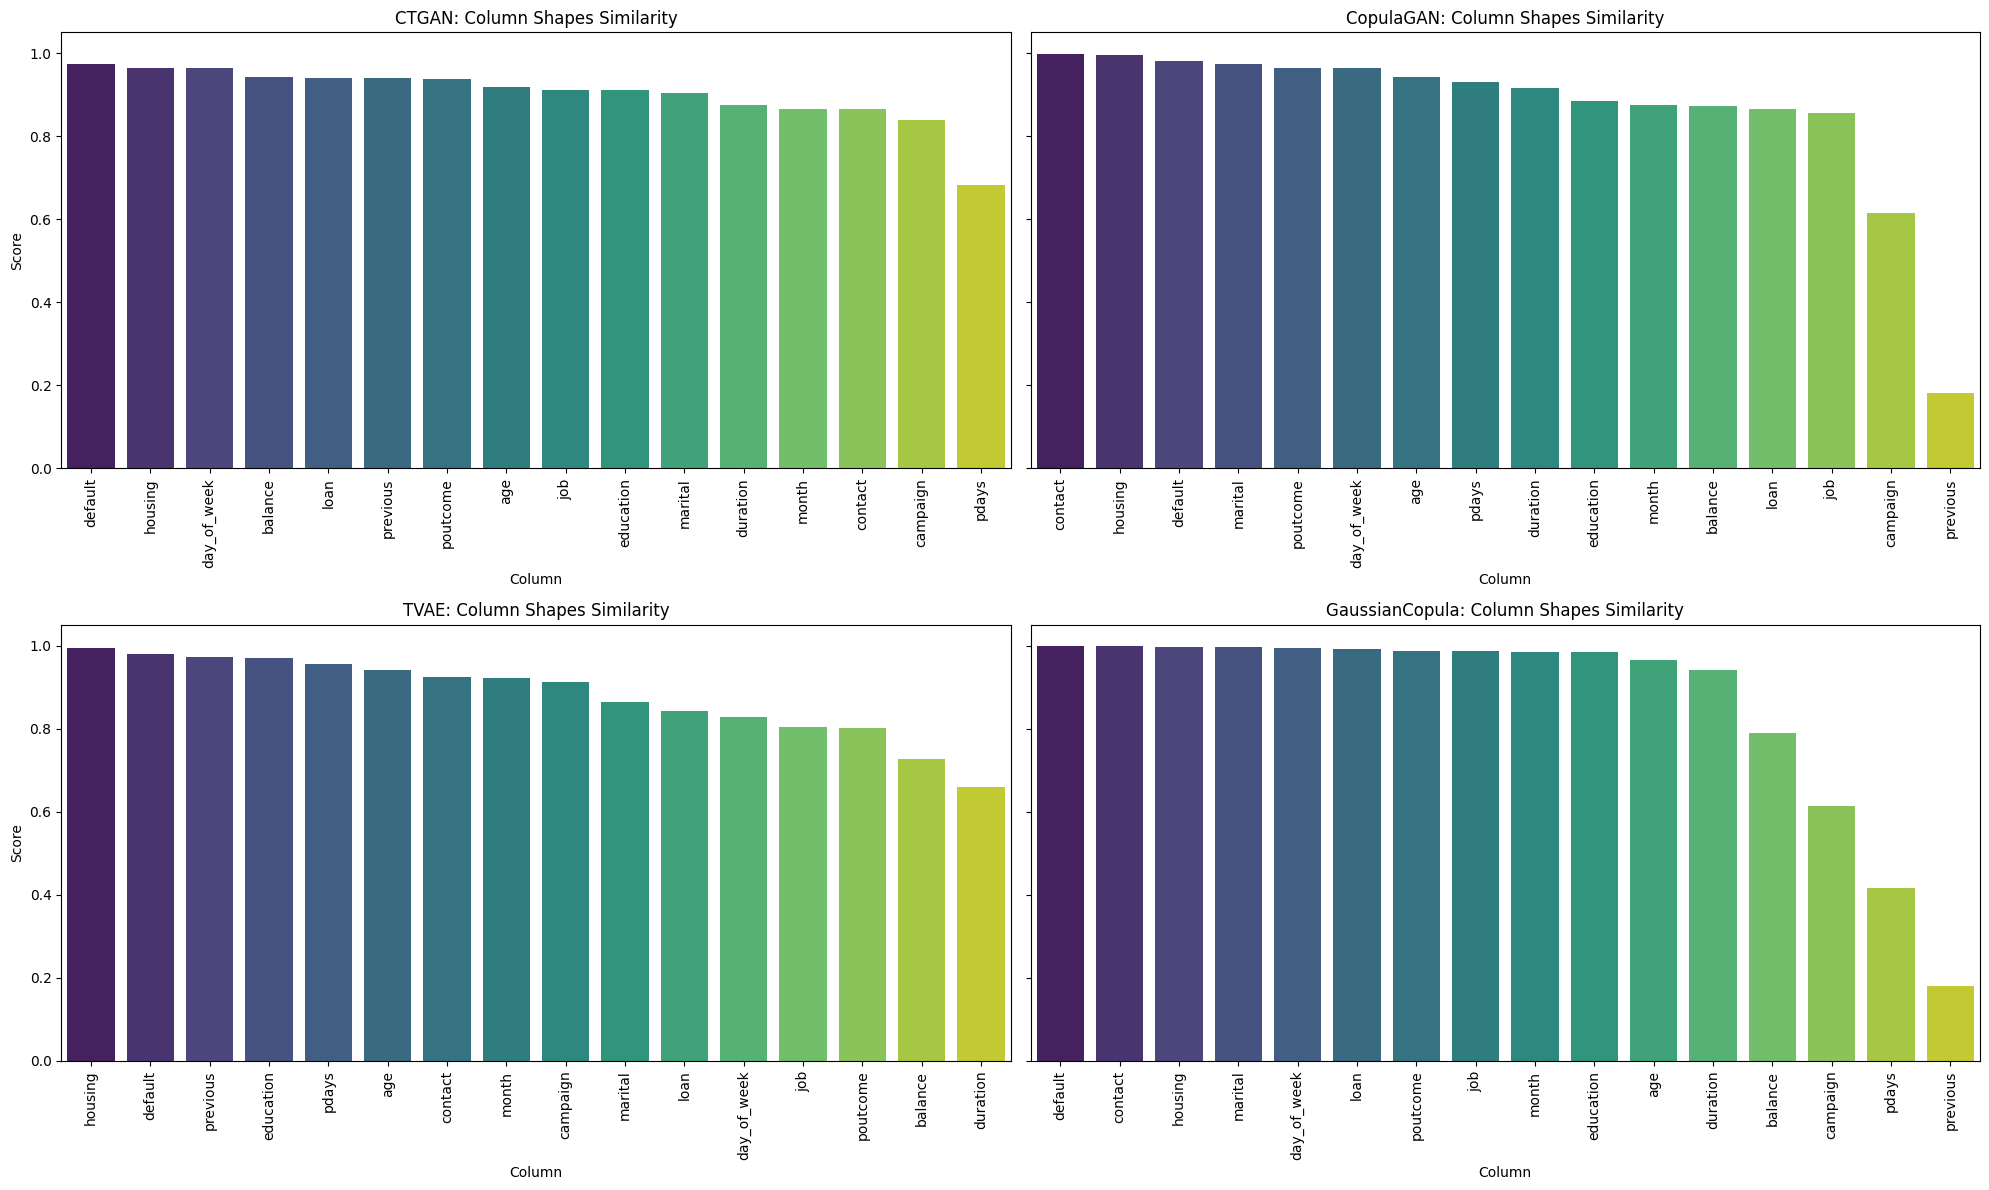

         Column        Metric     Score      Model
0       default  TVComplement  0.972700      CTGAN
1       housing  TVComplement  0.963900      CTGAN
2   day_of_week  KSComplement  0.963400      CTGAN
3       balance  KSComplement  0.941900      CTGAN
4          loan  TVComplement  0.939100      CTGAN
5      previous  KSComplement  0.939000      CTGAN
6      poutcome  TVComplement  0.937097      CTGAN
7           age  KSComplement  0.918900      CTGAN
8           job  TVComplement  0.912257      CTGAN
9     education  TVComplement  0.912156      CTGAN
10      marital  TVComplement  0.905000      CTGAN
11     duration  KSComplement  0.874500      CTGAN
12        month  TVComplement  0.866200      CTGAN
13      contact  TVComplement  0.864922      CTGAN
14     campaign  KSComplement  0.837700      CTGAN
15        pdays  KSComplement  0.681500      CTGAN
16      contact  TVComplement  0.997021  CopulaGAN
17      housing  TVComplement  0.994700  CopulaGAN
18      default  TVComplement  

In [5]:
import warnings
warnings.filterwarnings("ignore")

from sdv.evaluation.single_table import QualityReport
from sdv.metadata import SingleTableMetadata
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "y"

# Exclude target for feature-distribution comparison
real_eval = data.drop(columns=[target_col], errors="ignore").copy()

metadata_eval = SingleTableMetadata()
metadata_eval.detect_from_dataframe(real_eval)

column_shape_details = {}

for model_name in model_order:
    synth_eval = synthetic_datasets[model_name].drop(columns=[target_col], errors="ignore").copy()
    synth_eval = synth_eval.reindex(columns=real_eval.columns)

    qr = QualityReport()
    qr.generate(
        real_data=real_eval,
        synthetic_data=synth_eval,
        metadata=metadata_eval.to_dict()
    )

    details = qr.get_details("Column Shapes").sort_values("Score", ascending=False)
    column_shape_details[model_name] = details

fig, axes = plt.subplots(2, 2, figsize=(20, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    details = column_shape_details[model_name]
    sns.barplot(
        x="Column",
        y="Score",
        data=details,
        palette="viridis",
        ax=ax
    )
    ax.set_title(f"{model_name}: Column Shapes Similarity")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Column")
    ax.set_ylabel("Score")

plt.tight_layout()
plt.show()

combined_details = pd.concat(
    [df.assign(Model=name) for name, df in column_shape_details.items()],
    ignore_index=True
)

print(combined_details.head(20))

### 1.2. Jensen–Shannon divergence

In [6]:
import numpy as np
import pandas as pd
from pandas.api.types import is_numeric_dtype
from scipy.spatial.distance import jensenshannon
from sklearn.preprocessing import MinMaxScaler

def _prob_vectors_numeric(real, synth, bins=30, eps=1e-12):
    real = pd.to_numeric(real, errors="coerce").dropna().to_numpy()
    synth = pd.to_numeric(synth, errors="coerce").dropna().to_numpy()

    if len(real) == 0 or len(synth) == 0:
        return np.array([0.5, 0.5]), np.array([0.5, 0.5])

    edges = np.histogram_bin_edges(np.concatenate([real, synth]), bins=bins)
    r_hist, _ = np.histogram(real, bins=edges)
    s_hist, _ = np.histogram(synth, bins=edges)

    r = r_hist.astype(float) + eps
    s = s_hist.astype(float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s

def _prob_vectors_categorical(real, synth, eps=1e-12):
    r_counts = real.astype(str).value_counts(dropna=False)
    s_counts = synth.astype(str).value_counts(dropna=False)
    keys = r_counts.index.union(s_counts.index)

    r = r_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    s = s_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s, keys

def compute_js_divergence(real_df: pd.DataFrame, synth_df: pd.DataFrame, bins=30, normalize=True) -> pd.DataFrame:
    common_cols = [c for c in real_df.columns if c in synth_df.columns]
    real = real_df[common_cols].copy()
    synth = synth_df[common_cols].copy()

    if normalize:
        num_cols = [c for c in common_cols if is_numeric_dtype(real[c])]
        if num_cols:
            scaler = MinMaxScaler()
            real[num_cols] = scaler.fit_transform(real[num_cols])
            synth[num_cols] = scaler.transform(synth[num_cols])

    results = []
    for col in common_cols:
        r_col, s_col = real[col], synth[col]

        if is_numeric_dtype(r_col):
            p, q = _prob_vectors_numeric(r_col, s_col, bins=bins)
        else:
            p, q, _ = _prob_vectors_categorical(r_col, s_col)

        js_div = jensenshannon(p, q, base=2) ** 2
        results.append({"Feature": col, "JS_Divergence": float(js_div)})

    return pd.DataFrame(results).sort_values("JS_Divergence", ascending=False).reset_index(drop=True)

In [7]:
model_js_results = {}

real_features = data.drop(columns=["y"], errors="ignore")

for model_name, synth_df in synthetic_datasets.items():
    synth_features = synth_df.drop(columns=["y"], errors="ignore")

    js_df = compute_js_divergence(
        real_df=real_features,
        synth_df=synth_features,
        bins=30,
        normalize=True
    )
    model_js_results[model_name] = js_df
    print(f"\n{model_name} - Top JS divergence features")
    display(js_df.head(10))


CTGAN - Top JS divergence features


,Feature,JS_Divergence
0,contact,0.018801
1,month,0.018104
2,day_of_week,0.017907
3,pdays,0.014671
4,duration,0.013645
5,age,0.013076
6,job,0.011596
7,previous,0.011153
8,campaign,0.009598
9,marital,0.008316



CopulaGAN - Top JS divergence features


,Feature,JS_Divergence
0,campaign,0.047178
1,pdays,0.040630
2,job,0.021970
3,loan,0.018718
4,month,0.017300
5,day_of_week,0.016506
6,duration,0.016124
7,age,0.015399
8,balance,0.014032
9,education,0.011829



TVAE - Top JS divergence features


,Feature,JS_Divergence
0,duration,0.124151
1,day_of_week,0.089179
2,job,0.077703
3,loan,0.077383
4,marital,0.065644
5,balance,0.031618
6,education,0.022056
7,contact,0.021216
8,campaign,0.018852
9,month,0.018494



GaussianCopula - Top JS divergence features


,Feature,JS_Divergence
0,previous,0.173711
1,pdays,0.109190
2,campaign,0.022342
3,balance,0.016534
4,age,0.011781
5,duration,0.008651
6,day_of_week,0.000625
7,month,0.000365
8,job,0.000362
9,education,0.000185


### 1.3 Wasserstein Distance



CTGAN - Wasserstein Distance:
age: 0.0184
balance: 0.0023
day_of_week: 0.0111
duration: 0.0134
campaign: 0.0097
pdays: 0.0106
previous: 0.0065

CopulaGAN - Wasserstein Distance:
age: 0.0143
balance: 0.0034
day_of_week: 0.0195
duration: 0.0148
campaign: 0.0183
pdays: 0.0187
previous: 0.0175

TVAE - Wasserstein Distance:
age: 0.0127
balance: 0.0094
day_of_week: 0.0652
duration: 0.0464
campaign: 0.0103
pdays: 0.0052
previous: 0.0033

GaussianCopula - Wasserstein Distance:
age: 0.0093
balance: 0.0092
day_of_week: 0.0021
duration: 0.0091
campaign: 0.0197
pdays: 0.0356
previous: 0.0360

Model summary (lower is better):


,Model,Mean_Wasserstein,Median_Wasserstein,Max_Wasserstein
0,CTGAN,0.010308,0.010613,0.018380
1,CopulaGAN,0.015207,0.017455,0.019543
2,GaussianCopula,0.017279,0.009267,0.036000
3,TVAE,0.021784,0.010302,0.065177


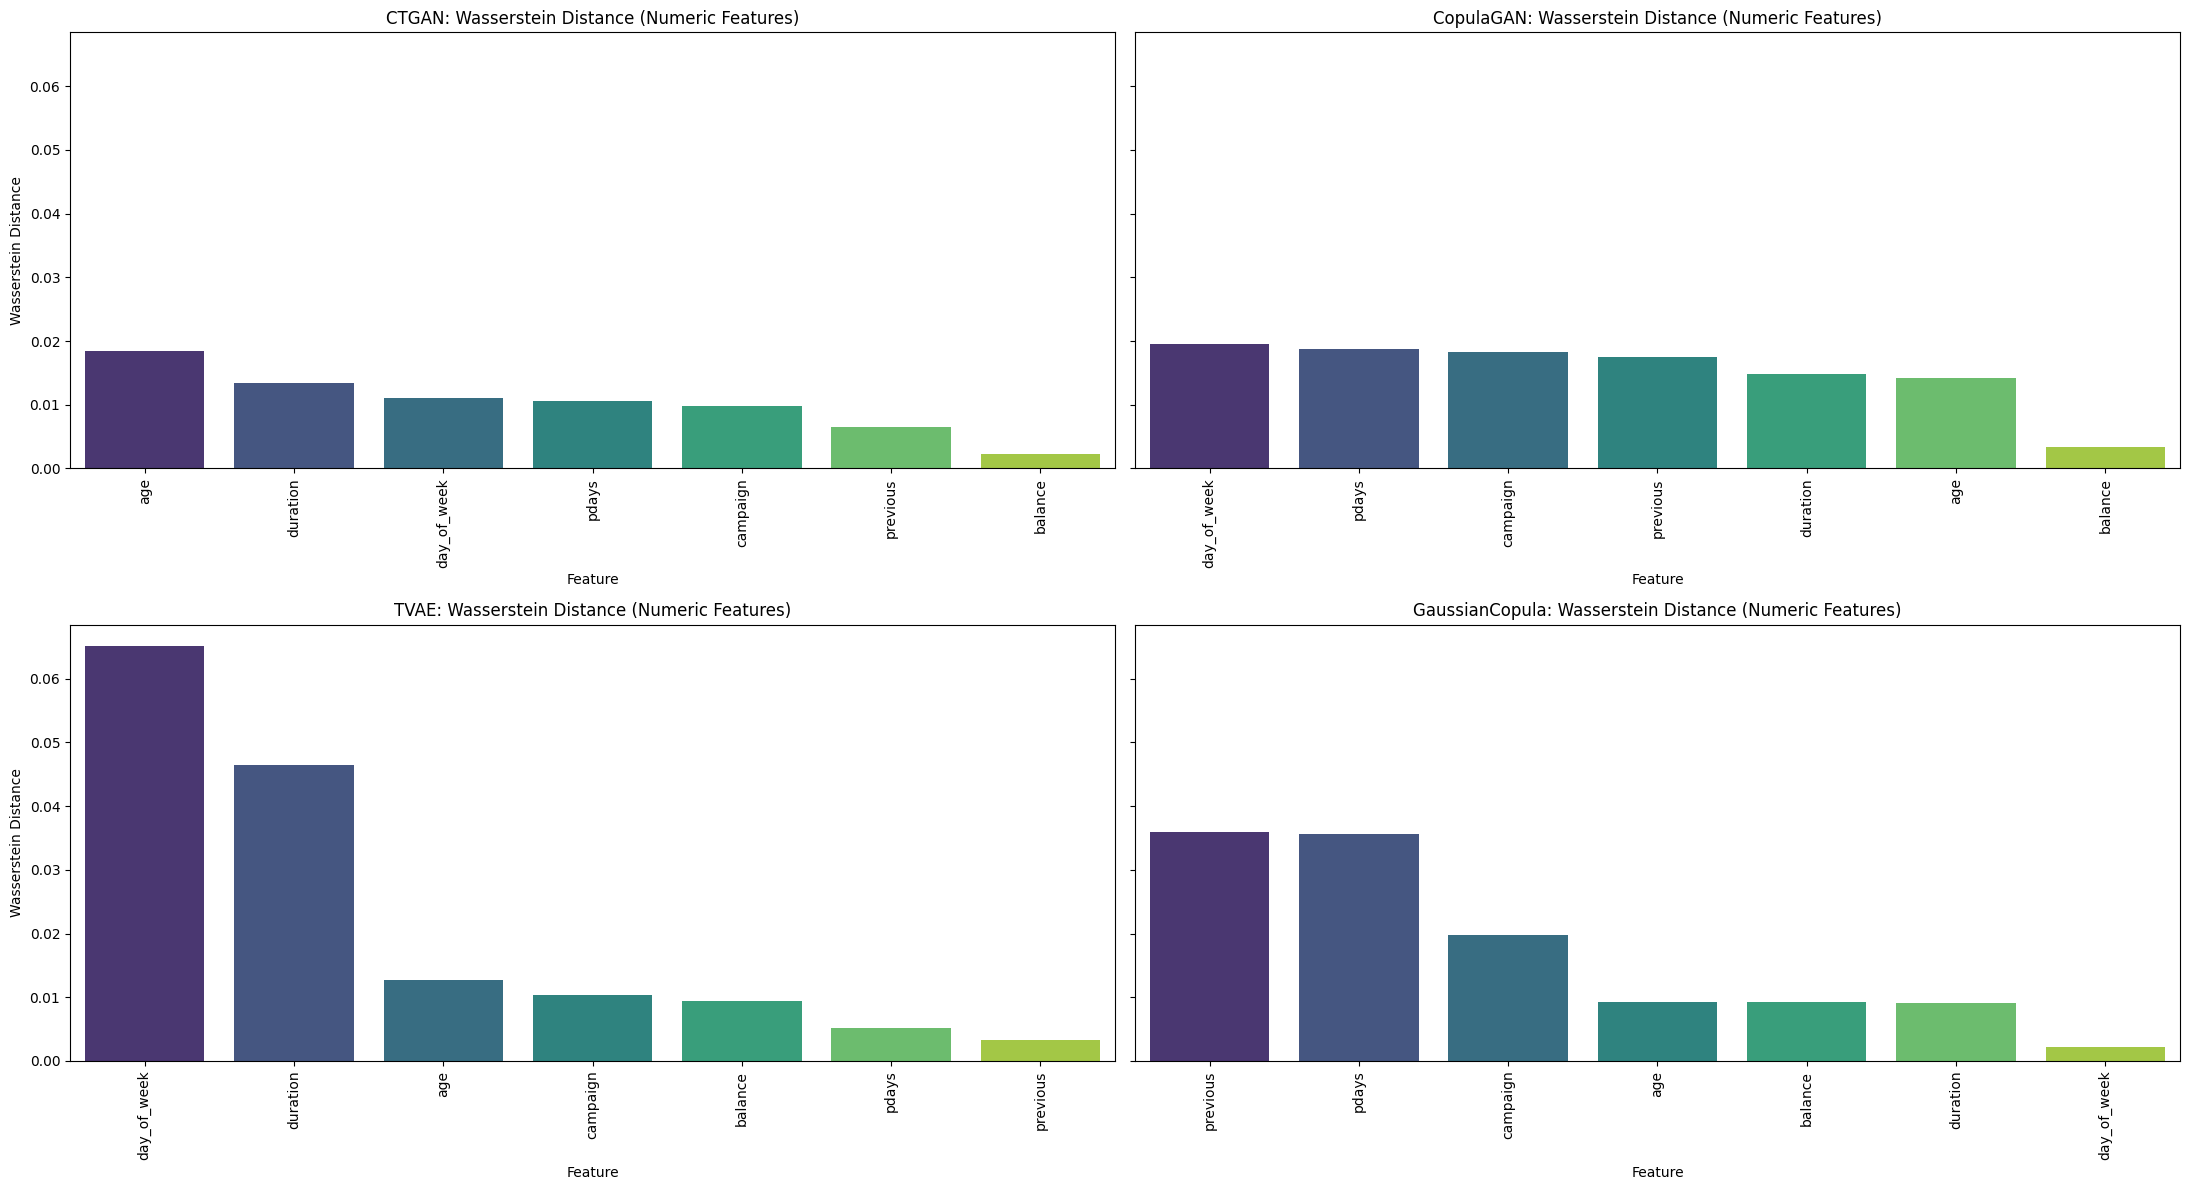

In [8]:
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "y"

# Numeric features only
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c != target_col]

scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(data[feature_cols]),
    columns=feature_cols
)

wasserstein_by_model = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()

    # Keep only the same numeric feature set/order
    synth_num = synth_df[feature_cols].copy()

    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_num),
        columns=feature_cols
    )

    dists = []
    print(f"\n{model_name} - Wasserstein Distance:")
    for col in feature_cols:
        dist = wasserstein_distance(real_scaled[col], synthetic_scaled[col])
        dists.append((col, float(dist)))
        print(f"{col}: {dist:.4f}")

    dist_df = pd.DataFrame(
        dists,
        columns=["Feature", "Wasserstein_Distance"]
    ).sort_values("Wasserstein_Distance", ascending=False)

    wasserstein_by_model[model_name] = dist_df

    summary_rows.append({
        "Model": model_name,
        "Mean_Wasserstein": float(dist_df["Wasserstein_Distance"].mean()),
        "Median_Wasserstein": float(dist_df["Wasserstein_Distance"].median()),
        "Max_Wasserstein": float(dist_df["Wasserstein_Distance"].max()),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Wasserstein").reset_index(drop=True)

print("\nModel summary (lower is better):")
display(summary_df)

fig, axes = plt.subplots(2, 2, figsize=(22, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    df_plot = wasserstein_by_model[model_name]
    sns.barplot(
        x="Feature",
        y="Wasserstein_Distance",
        data=df_plot,
        palette="viridis",
        ax=ax
    )
    ax.set_title(f"{model_name}: Wasserstein Distance (Numeric Features)")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Feature")
    ax.set_ylabel("Wasserstein Distance")

plt.tight_layout()
plt.show()

### 1.4 Gower Distance

In [9]:
import numpy as np
import pandas as pd
import gower

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

target_col = "y"
drop_cols = [target_col]

X_real = data.drop(columns=drop_cols, errors="ignore").copy()

gower_results = []

for model_name in model_order:
    X_synth = synthetic_datasets[model_name].drop(columns=drop_cols, errors="ignore").copy()

    common_cols = X_real.columns.intersection(X_synth.columns)
    Xr = X_real[common_cols].reset_index(drop=True).copy()
    Xs = X_synth[common_cols].reset_index(drop=True).copy()

    num_cols = Xr.select_dtypes(include=[np.number]).columns
    Xr[num_cols] = Xr[num_cols].astype(np.float64)
    Xs[num_cols] = Xs[num_cols].astype(np.float64)

    gower_real = 1.0 - gower.gower_matrix(Xr)
    gower_synth = 1.0 - gower.gower_matrix(Xs)

    real_upper = gower_real[np.triu_indices_from(gower_real, k=1)]
    synth_upper = gower_synth[np.triu_indices_from(gower_synth, k=1)]

    max_intra_real = float(np.max(real_upper))
    avg_intra_real = float(np.mean(real_upper))
    max_intra_synth = float(np.max(synth_upper))
    avg_intra_synth = float(np.mean(synth_upper))

    combined = pd.concat([Xr, Xs], axis=0, ignore_index=True)
    gower_combined = 1.0 - gower.gower_matrix(combined)
    n_real = len(Xr)
    cross_block = gower_combined[:n_real, n_real:]

    max_cross = float(np.max(cross_block))
    avg_cross = float(np.mean(cross_block))

    print(f"\n{model_name} - Gower Similarity:")
    print("Intra-set Similarity (Real):")
    print(f"Max = {max_intra_real:.4f}, Avg = {avg_intra_real:.4f}\n")
    print("Intra-set Similarity (Synthetic):")
    print(f"Max = {max_intra_synth:.4f}, Avg = {avg_intra_synth:.4f}\n")
    print("Cross-set Similarity (Real vs Synthetic):")
    print(f"Max = {max_cross:.4f}, Avg = {avg_cross:.4f}")

    gower_results.append({
        "Model": model_name,
        "Max_Intra_Real": max_intra_real,
        "Avg_Intra_Real": avg_intra_real,
        "Max_Intra_Synth": max_intra_synth,
        "Avg_Intra_Synth": avg_intra_synth,
        "Max_Cross_Real_vs_Synth": max_cross,
        "Avg_Cross_Real_vs_Synth": avg_cross,
    })

gower_summary_df = pd.DataFrame(gower_results)
display(gower_summary_df)


CTGAN - Gower Similarity:
Intra-set Similarity (Real):
Max = 0.9992, Avg = 0.6280

Intra-set Similarity (Synthetic):
Max = 0.9965, Avg = 0.6124

Cross-set Similarity (Real vs Synthetic):
Max = 0.9985, Avg = 0.6273

CopulaGAN - Gower Similarity:
Intra-set Similarity (Real):
Max = 0.9992, Avg = 0.6280

Intra-set Similarity (Synthetic):
Max = 0.9951, Avg = 0.5968

Cross-set Similarity (Real vs Synthetic):
Max = 0.9941, Avg = 0.6173

TVAE - Gower Similarity:
Intra-set Similarity (Real):
Max = 0.9992, Avg = 0.6280

Intra-set Similarity (Synthetic):
Max = 0.9982, Avg = 0.6590

Cross-set Similarity (Real vs Synthetic):
Max = 0.9983, Avg = 0.6478

GaussianCopula - Gower Similarity:
Intra-set Similarity (Real):
Max = 0.9992, Avg = 0.6280

Intra-set Similarity (Synthetic):
Max = 0.9913, Avg = 0.6121

Cross-set Similarity (Real vs Synthetic):
Max = 0.9889, Avg = 0.6262


,Model,Max_Intra_Real,Avg_Intra_Real,Max_Intra_Synth,Avg_Intra_Synth,Max_Cross_Real_vs_Synth,Avg_Cross_Real_vs_Synth
0,CTGAN,0.999192,0.627976,0.996500,0.612360,0.998533,0.627346
1,CopulaGAN,0.999192,0.627976,0.995142,0.596808,0.994079,0.617333
2,TVAE,0.999192,0.627976,0.998218,0.658998,0.998275,0.647807
3,GaussianCopula,0.999192,0.627976,0.991346,0.612074,0.988868,0.626154


### 1.5 t-SNE Visualization


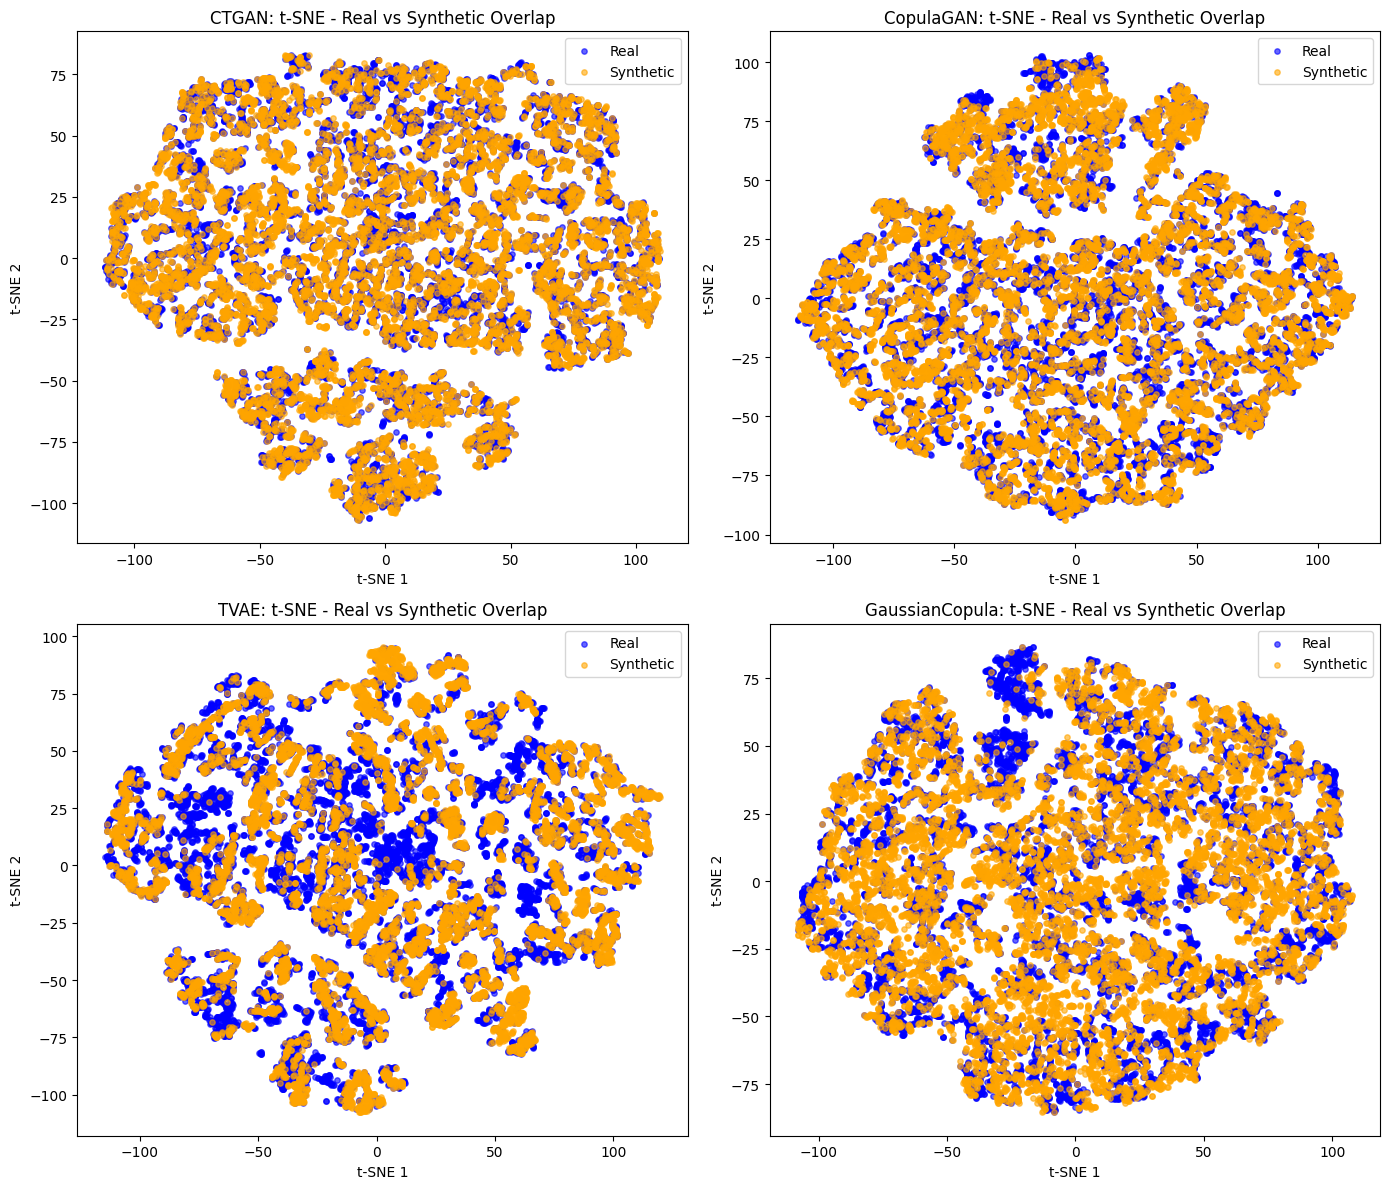

In [10]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "y"

# Keep only numeric feature columns and exclude the target
feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != target_col]

real_num = data[feature_cols].copy()

scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(real_num),
    columns=feature_cols
)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    synth_df = synthetic_datasets[model_name].copy()

    # Keep only matching numeric feature columns
    synth_num = synth_df.reindex(columns=feature_cols).copy()

    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_num),
        columns=feature_cols
    )

    combined = np.vstack([real_scaled.values, synthetic_scaled.values])
    labels = np.array(["Real"] * len(real_scaled) + ["Synthetic"] * len(synthetic_scaled))

    tsne = TSNE(
        n_components=2,
        random_state=42,
        init="pca",
        learning_rate="auto"
    )
    tsne_result = tsne.fit_transform(combined)

    ax.scatter(
        tsne_result[labels == "Real", 0],
        tsne_result[labels == "Real", 1],
        c="blue",
        alpha=0.6,
        s=15,
        label="Real"
    )
    ax.scatter(
        tsne_result[labels == "Synthetic", 0],
        tsne_result[labels == "Synthetic", 1],
        c="orange",
        alpha=0.6,
        s=15,
        label="Synthetic"
    )

    ax.set_title(f"{model_name}: t-SNE - Real vs Synthetic Overlap")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend()

plt.tight_layout()
plt.show()

### 1.6 MMD (Maximum Mean Discrepancy)


In [11]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel

def _sample_rows(X, max_rows=2000, seed=42):
    if X.shape[0] <= max_rows:
        return X
    rng = np.random.default_rng(seed)
    idx = rng.choice(X.shape[0], size=max_rows, replace=False)
    return X[idx]

def _median_gamma(X, Y):
    Z = np.vstack([X, Y])
    n = Z.shape[0]
    take = min(1200, n)
    idx = np.random.default_rng(42).choice(n, size=take, replace=False)
    Zs = Z[idx]
    d2 = np.sum((Zs[:, None, :] - Zs[None, :, :]) ** 2, axis=2)
    vals = d2[np.triu_indices_from(d2, k=1)]
    med = np.median(vals[vals > 0]) if np.any(vals > 0) else 1.0
    return 1.0 / (2.0 * med)

def compute_mmd_rbf_safe(X, Y, gamma=None):
    if gamma is None:
        gamma = _median_gamma(X, Y)
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)
    return float(Kxx.mean() + Kyy.mean() - 2.0 * Kxy.mean())

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

target_col = "y"
drop_cols = [target_col]

real_features = data.drop(columns=drop_cols, errors="ignore").copy()

# Keep numeric only for RBF MMD
real_features = real_features.select_dtypes(include=[np.number]).copy()

mmd_results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_features = synth_df.drop(columns=drop_cols, errors="ignore").copy()
    synth_features = synth_features.select_dtypes(include=[np.number]).copy()

    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = real_features[common_cols].to_numpy(dtype=np.float64)
    X_synth = synth_features[common_cols].to_numpy(dtype=np.float64)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    Xr = _sample_rows(X_real_scaled, max_rows=2000, seed=42)
    Xs = _sample_rows(X_synth_scaled, max_rows=2000, seed=42)

    mmd_score = compute_mmd_rbf_safe(Xr, Xs, gamma=None)
    mmd_results.append({"Model": model_name, "MMD_Score": float(mmd_score)})

    print(f"{model_name} - MMD score: {mmd_score:.6f}")

mmd_summary_df = pd.DataFrame(mmd_results).sort_values("MMD_Score").reset_index(drop=True)

print("\nMMD comparison (lower is better):")
display(mmd_summary_df)

CTGAN - MMD score: 0.005335
CopulaGAN - MMD score: 0.021132
TVAE - MMD score: 0.022188
GaussianCopula - MMD score: 0.063279

MMD comparison (lower is better):


,Model,MMD_Score
0,CTGAN,0.005335
1,CopulaGAN,0.021132
2,TVAE,0.022188
3,GaussianCopula,0.063279


### 1.7 Cosine Similarity


In [12]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

target_col = "y"
drop_cols = [target_col]

real_features = data.drop(columns=drop_cols, errors="ignore").copy()
real_features = real_features.select_dtypes(include=[np.number]).copy()

similarity_results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_features = synth_df.drop(columns=drop_cols, errors="ignore").copy()
    synth_features = synth_features.select_dtypes(include=[np.number]).copy()

    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = real_features[common_cols].astype(np.float64)
    X_synth = synth_features[common_cols].astype(np.float64)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    cross_sim = cosine_similarity(X_real_scaled, X_synth_scaled)
    avg_sim = float(np.mean(cross_sim))
    max_sim = float(np.max(cross_sim))

    print(f"\n{model_name} - Sample-Level Similarity:")
    print(f"Average cosine similarity: {avg_sim:.4f}")
    print(f"Maximum cosine similarity: {max_sim:.4f}")

    similarity_results.append({
        "Model": model_name,
        "Average_Cosine_Similarity": avg_sim,
        "Maximum_Cosine_Similarity": max_sim
    })

similarity_summary_df = pd.DataFrame(similarity_results).sort_values(
    "Average_Cosine_Similarity", ascending=False
).reset_index(drop=True)

print("\nCosine similarity comparison (higher means more similar):")
display(similarity_summary_df)


CTGAN - Sample-Level Similarity:
Average cosine similarity: 0.0162
Maximum cosine similarity: 1.0000

CopulaGAN - Sample-Level Similarity:
Average cosine similarity: -0.0049
Maximum cosine similarity: 0.9997

TVAE - Sample-Level Similarity:
Average cosine similarity: 0.0478
Maximum cosine similarity: 1.0000

GaussianCopula - Sample-Level Similarity:
Average cosine similarity: -0.0208
Maximum cosine similarity: 0.9984

Cosine similarity comparison (higher means more similar):


,Model,Average_Cosine_Similarity,Maximum_Cosine_Similarity
0,TVAE,0.047822,0.999997
1,CTGAN,0.016167,0.999998
2,CopulaGAN,-0.004861,0.999667
3,GaussianCopula,-0.020781,0.998391


### 1.8 Nearest Neighbours 


In [13]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

target_col = "y"
drop_cols = [target_col]

real_features = data.drop(columns=drop_cols, errors="ignore").copy()
real_features = real_features.select_dtypes(include=[np.number]).copy()

privacy_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_features = synth_df.drop(columns=drop_cols, errors="ignore").copy()
    synth_features = synth_features.select_dtypes(include=[np.number]).copy()

    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = real_features[common_cols].astype(np.float64)
    X_synth = synth_features[common_cols].astype(np.float64)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    nn = NearestNeighbors(n_neighbors=1).fit(X_real_scaled)
    distances, _ = nn.kneighbors(X_synth_scaled)

    avg_nn_dist = float(np.mean(distances))
    min_nn_dist = float(np.min(distances))
    p5_nn_dist = float(np.percentile(distances, 5))

    print(f"\n{model_name} - Privacy Check:")
    print(f"Average NN Distance (Synthetic -> Real): {avg_nn_dist:.4f}")
    print(f"Minimum NN Distance (Synthetic -> Real): {min_nn_dist:.4f}")
    print(f"5th Percentile NN Distance: {p5_nn_dist:.4f}")

    privacy_rows.append({
        "Model": model_name,
        "Avg_NN_Distance": avg_nn_dist,
        "Min_NN_Distance": min_nn_dist,
        "P5_NN_Distance": p5_nn_dist
    })

privacy_summary_df = pd.DataFrame(privacy_rows).sort_values(
    "Avg_NN_Distance", ascending=False
).reset_index(drop=True)

print("\nPrivacy distance summary (higher generally safer):")
display(privacy_summary_df)


CTGAN - Privacy Check:
Average NN Distance (Synthetic -> Real): 0.4384
Minimum NN Distance (Synthetic -> Real): 0.0036
5th Percentile NN Distance: 0.1079

CopulaGAN - Privacy Check:
Average NN Distance (Synthetic -> Real): 0.6714
Minimum NN Distance (Synthetic -> Real): 0.0787
5th Percentile NN Distance: 0.4960

TVAE - Privacy Check:
Average NN Distance (Synthetic -> Real): 0.2473
Minimum NN Distance (Synthetic -> Real): 0.0039
5th Percentile NN Distance: 0.0693

GaussianCopula - Privacy Check:
Average NN Distance (Synthetic -> Real): 0.8748
Minimum NN Distance (Synthetic -> Real): 0.1140
5th Percentile NN Distance: 0.5197

Privacy distance summary (higher generally safer):


,Model,Avg_NN_Distance,Min_NN_Distance,P5_NN_Distance
0,GaussianCopula,0.874767,0.113986,0.519719
1,CopulaGAN,0.671442,0.078727,0.496017
2,CTGAN,0.438439,0.003588,0.107918
3,TVAE,0.247332,0.003945,0.069297


# 2. Stats

Average error by model for Bank Marketing


,Model,Mean Error %,Median Error %,Std Error %
0,CTGAN,15.683888,14.181028,11.198530
1,CopulaGAN,27.112464,12.072722,20.994955
2,TVAE,25.553935,16.731813,33.337731
3,GaussianCopula,59.045216,6.314740,15.253082


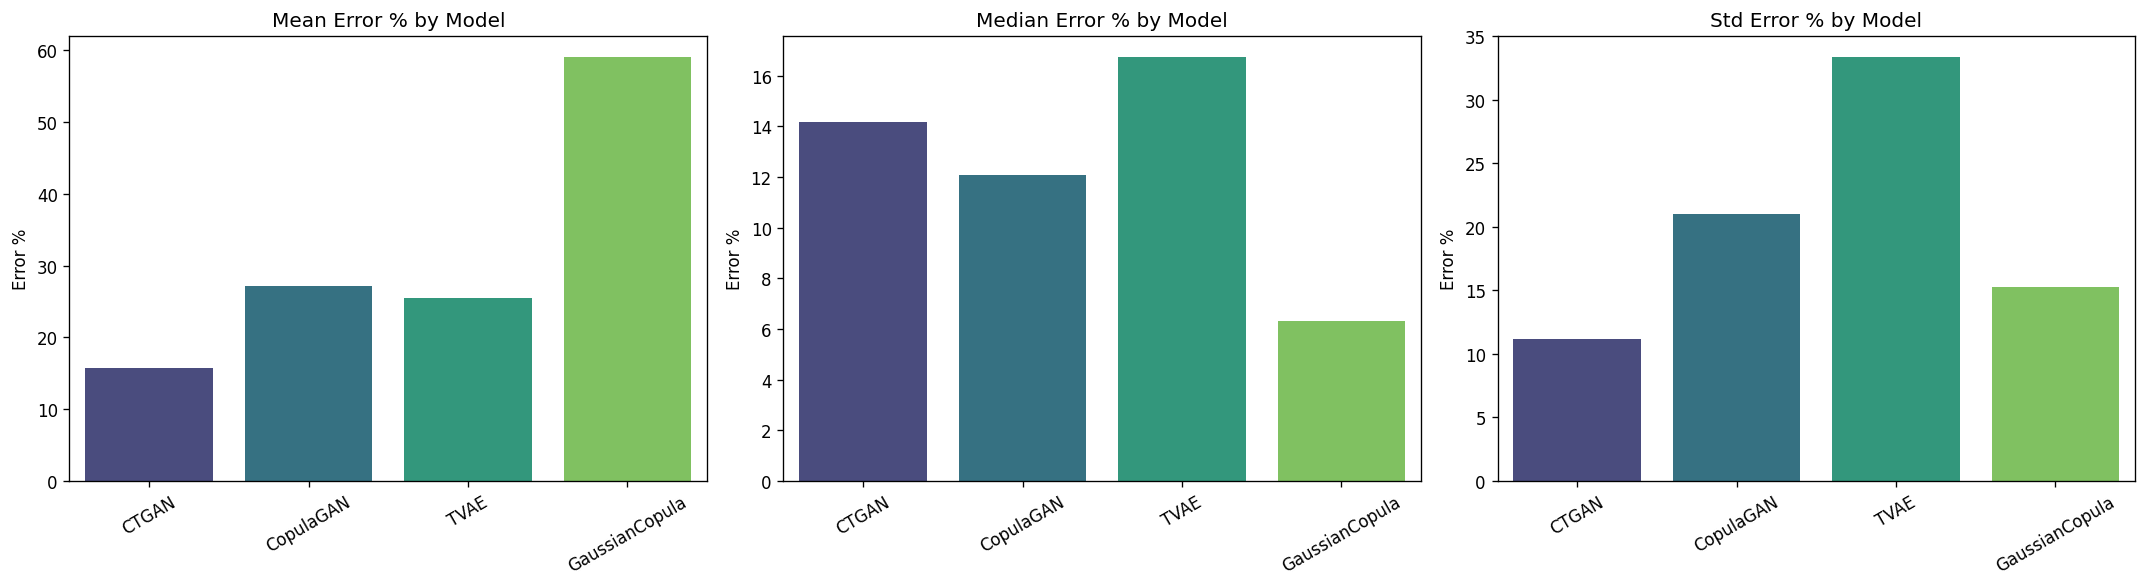


Top feature errors for CTGAN


,Feature,Mean_Error_%,Std_Error_%
6,previous,47.659054,12.776771
4,campaign,19.022780,19.648577
5,pdays,18.090709,3.480608
3,duration,14.181028,17.222350
1,balance,7.065729,17.455378
0,age,3.294175,6.687817
2,day_of_week,0.473739,1.118208



Top feature errors for CopulaGAN


,Feature,Mean_Error_%,Std_Error_%
6,previous,127.321535,56.660316
4,campaign,21.964339,15.695083
3,duration,15.753368,23.888326
5,pdays,12.072722,9.773152
1,balance,10.071950,31.404997
0,age,1.783532,2.745878
2,day_of_week,0.819801,6.796937



Top feature errors for TVAE


,Feature,Mean_Error_%,Std_Error_%
1,balance,70.746144,70.737603
3,duration,49.612702,68.929470
6,previous,25.024560,50.521817
4,campaign,16.731813,35.977865
2,day_of_week,13.421011,1.088926
5,pdays,2.861030,3.149657
0,age,0.480284,2.958778



Top feature errors for GaussianCopula


,Feature,Mean_Error_%,Std_Error_%
6,previous,332.724257,5.634732
5,pdays,38.763856,54.665987
4,campaign,33.408559,2.419754
1,balance,6.314740,29.047427
3,duration,1.048492,13.867751
2,day_of_week,0.812842,0.055765
0,age,0.243769,1.080155


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Build the real Bank Marketing dataframe
data = pd.concat([X.reset_index(drop=True), y.reset_index(drop=True)], axis=1)
data.columns = data.columns.str.strip()

if "y" not in data.columns and y.shape[1] == 1:
    data = data.rename(columns={y.columns[0]: "y"})

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "y"

real_df = data.copy()

# Bank Marketing numeric columns
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

summary_rows = []
feature_error_by_model = {}

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_df = synth_df.reindex(columns=real_df.columns)

    real_num = real_df[num_cols].apply(pd.to_numeric, errors="coerce")
    synth_num = synth_df[num_cols].apply(pd.to_numeric, errors="coerce")

    real_means = real_num.mean()
    synth_means = synth_num.mean()

    real_stds = real_num.std(ddof=1)
    synth_stds = synth_num.std(ddof=1)

    mean_error_pct = (
        np.abs(synth_means - real_means) /
        real_means.replace(0, np.nan).abs()
    ) * 100.0

    std_error_pct = (
        np.abs(synth_stds - real_stds) /
        real_stds.replace(0, np.nan).abs()
    ) * 100.0

    feature_error_df = pd.DataFrame({
        "Feature": num_cols,
        "Mean_Error_%": mean_error_pct.values,
        "Std_Error_%": std_error_pct.values
    }).replace([np.inf, -np.inf], np.nan)

    model_summary = {
        "Model": model_name,
        "Mean Error %": float(feature_error_df["Mean_Error_%"].mean(skipna=True)),
        "Median Error %": float(feature_error_df["Mean_Error_%"].median(skipna=True)),
        "Std Error %": float(feature_error_df["Std_Error_%"].mean(skipna=True))
    }

    summary_rows.append(model_summary)
    feature_error_by_model[model_name] = feature_error_df.sort_values(
        "Mean_Error_%", ascending=False
    )

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index("Model").loc[model_order].reset_index()

print("Average error by model for Bank Marketing")
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
axes[0].set_title("Mean Error % by Model")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
axes[1].set_title("Median Error % by Model")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Std Error %", ax=axes[2], palette="viridis")
axes[2].set_title("Std Error % by Model")
axes[2].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Error %")

plt.tight_layout()
plt.show()

# Optional: inspect top per-feature errors
for model_name in model_order:
    print(f"\nTop feature errors for {model_name}")
    display(feature_error_by_model[model_name].head(10))


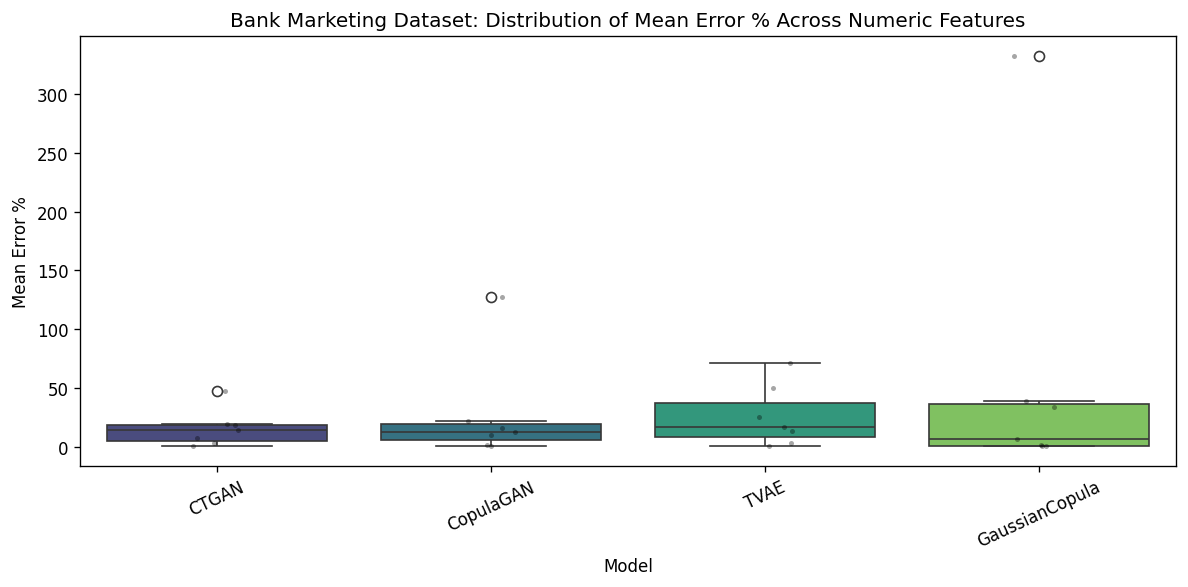

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

dist_df = pd.concat(
    [
        feature_error_by_model[m][["Feature", "Mean_Error_%"]].assign(Model=m)
        for m in model_order
    ],
    ignore_index=True
).replace([float("inf"), float("-inf")], pd.NA).dropna(subset=["Mean_Error_%"])

plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=dist_df, x="Model", y="Mean_Error_%", palette="viridis")
sns.stripplot(
    data=dist_df,
    x="Model",
    y="Mean_Error_%",
    color="black",
    alpha=0.35,
    size=3
)

plt.title("Bank Marketing Dataset: Distribution of Mean Error % Across Numeric Features")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

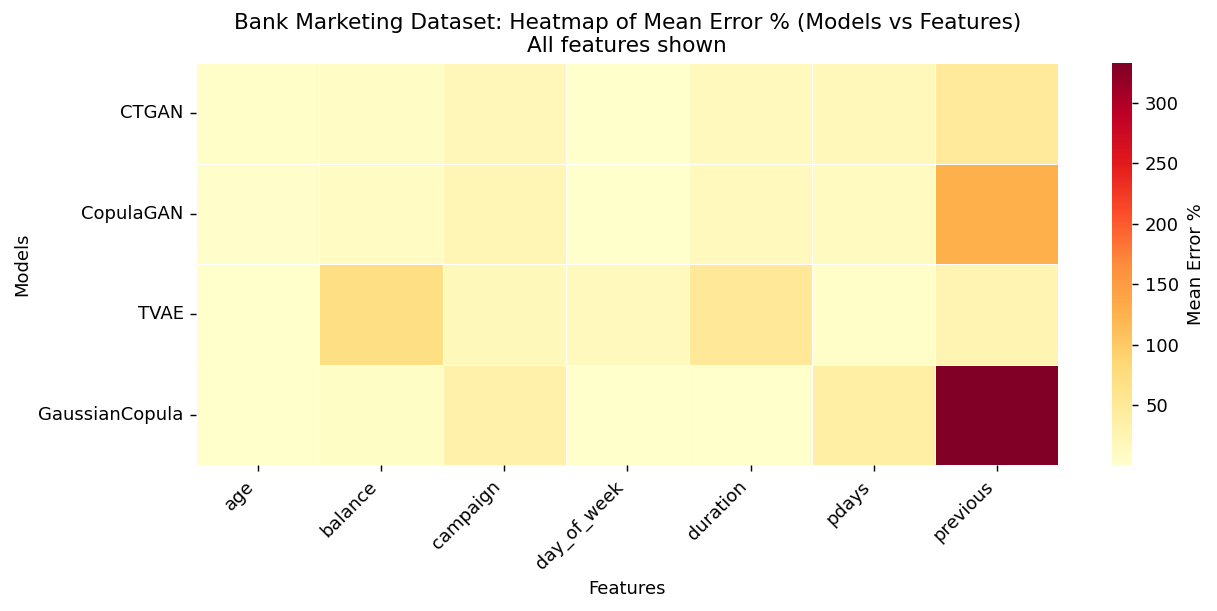

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
}).T

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

max_features = 20
if heatmap_df.shape[1] > max_features:
    top_features = (
        heatmap_df.mean(axis=0, skipna=True)
        .sort_values(ascending=False)
        .head(max_features)
        .index
    )
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"

def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 1] + "..."

display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)
sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"}
)

plt.title(f"Bank Marketing Dataset: Heatmap of Mean Error % (Models vs Features)\n{truncated_note}")
plt.xlabel("Features")
plt.ylabel("Models")
plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 2 Bivariate Analysis


In [15]:
from itertools import combinations
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

def bivariate_quality_bank_marketing(real_df, synth_df, target="y"):
    common_cols = real_df.columns.intersection(synth_df.columns)

    real_df = real_df[common_cols].copy()
    synth_df = synth_df[common_cols].copy()

    num_cols = real_df.select_dtypes(include=["number"]).columns.tolist()
    num_cols = [c for c in num_cols if c != target]

    if len(num_cols) == 0:
        return (
            pd.DataFrame(columns=["var_a", "var_b", "delta_corr"]),
            pd.DataFrame(columns=["feature", "delta_target_relation"])
        )

    scaler = MinMaxScaler()
    real_scaled = real_df.copy()
    synth_scaled = synth_df.copy()

    real_scaled[num_cols] = scaler.fit_transform(real_df[num_cols])
    synth_scaled[num_cols] = scaler.transform(synth_df[num_cols])

    results_corr = []
    for a, b in combinations(num_cols, 2):
        r_corr = real_scaled[[a, b]].corr().iloc[0, 1]
        s_corr = synth_scaled[[a, b]].corr().iloc[0, 1]
        results_corr.append({
            "var_a": a,
            "var_b": b,
            "delta_corr": abs(r_corr - s_corr)
        })

    corr_df = (
        pd.DataFrame(results_corr).sort_values("delta_corr", ascending=False)
        if results_corr else
        pd.DataFrame(columns=["var_a", "var_b", "delta_corr"])
    )

    target_df = pd.DataFrame(columns=["feature", "delta_target_relation"])
    return corr_df, target_df


In [16]:
import pandas as pd

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
real_df = data.copy()
target_col = "y"

all_corr_results = {}
all_target_results = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_df = synth_df.reindex(columns=real_df.columns)

    corr_results, target_results = bivariate_quality_bank_marketing(
        real_df=real_df,
        synth_df=synth_df,
        target=target_col
    )

    all_corr_results[model_name] = corr_results
    all_target_results[model_name] = target_results

    print(f"\n{model_name} - Largest differences in pairwise correlations:")
    display(corr_results.head(10))

    print(f"\n{model_name} - Features that differ most by relation to {target_col}:")
    display(target_results.head(10))

    summary_rows.append({
        "Model": model_name,
        "TopCorrDiff": corr_results["delta_corr"].iloc[0] if not corr_results.empty else None,
        "MeanTop10CorrDiff": corr_results["delta_corr"].head(10).mean() if not corr_results.empty else None,
        "TopTargetDiff": target_results["delta_target_relation"].iloc[0] if not target_results.empty else None,
        "MeanTop10TargetDiff": target_results["delta_target_relation"].head(10).mean() if not target_results.empty else None,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)


CTGAN - Largest differences in pairwise correlations:


,var_a,var_b,delta_corr
20,pdays,previous,0.104697
12,day_of_week,campaign,0.102474
3,age,campaign,0.068689
9,balance,pdays,0.062172
19,campaign,previous,0.058765
15,duration,campaign,0.056723
10,balance,previous,0.054093
5,age,previous,0.049280
2,age,duration,0.041147
1,age,day_of_week,0.037484



CTGAN - Features that differ most by relation to y:


,feature,delta_target_relation



CopulaGAN - Largest differences in pairwise correlations:


...


GaussianCopula - Largest differences in pairwise correlations:


,var_a,var_b,delta_corr
20,pdays,previous,0.231650
12,day_of_week,campaign,0.160321
13,day_of_week,pdays,0.097554
14,day_of_week,previous,0.048938
11,day_of_week,duration,0.038636
6,balance,day_of_week,0.023104
18,campaign,pdays,0.021114
0,age,balance,0.019565
1,age,day_of_week,0.013109
3,age,campaign,0.012211



GaussianCopula - Features that differ most by relation to y:


,feature,delta_target_relation


,Model,TopCorrDiff,MeanTop10CorrDiff,TopTargetDiff,MeanTop10TargetDiff
0,CTGAN,0.104697,0.063552,None,None
1,CopulaGAN,0.108287,0.055790,None,None
2,TVAE,0.275759,0.142665,None,None
3,GaussianCopula,0.231650,0.066620,None,None


### 3 Multivariate Analysis


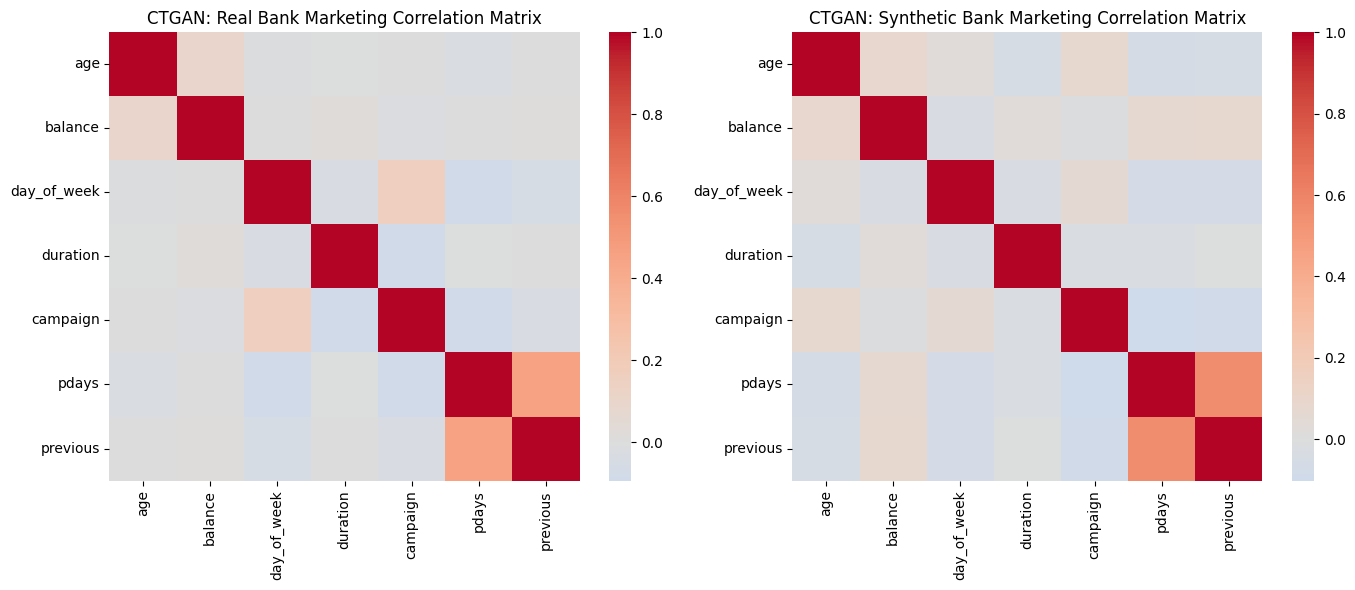

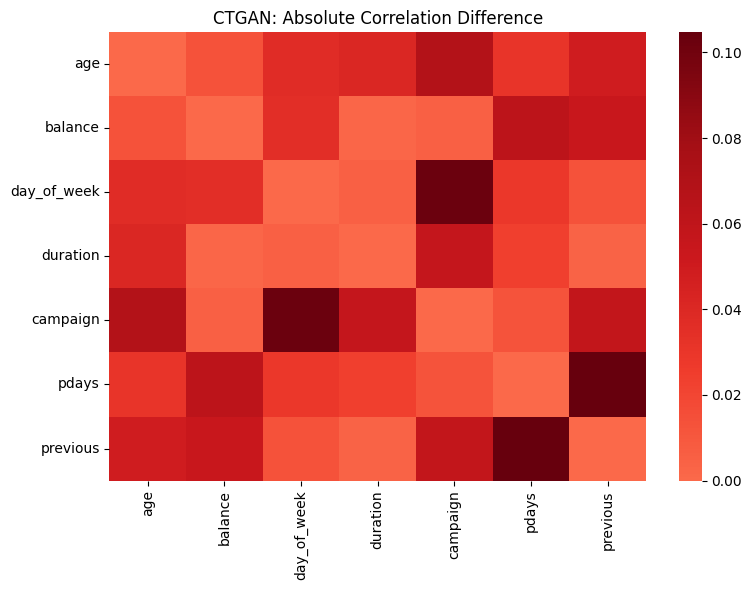

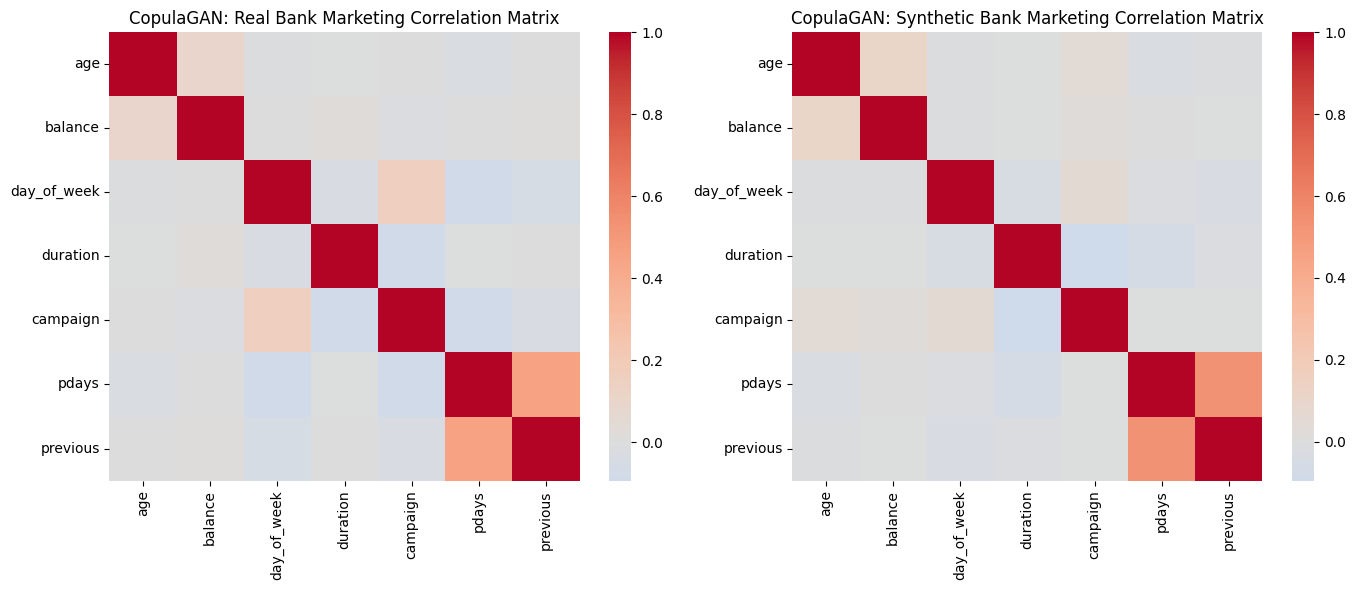

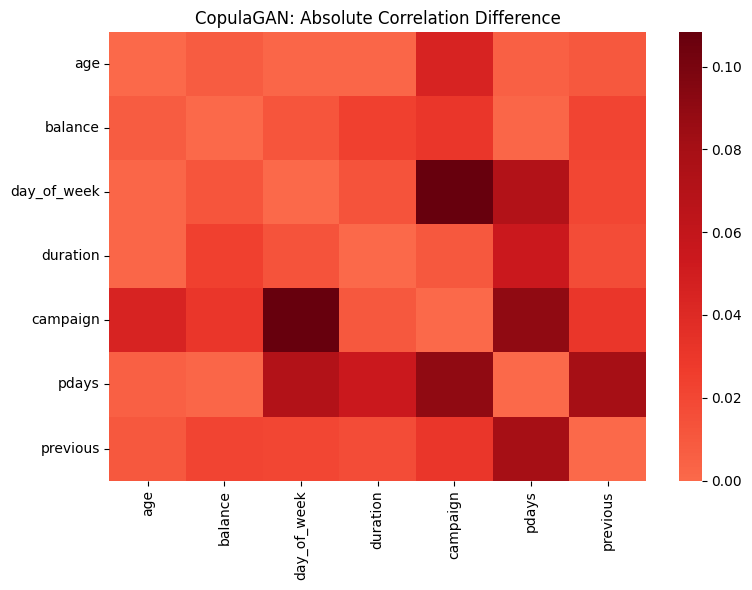

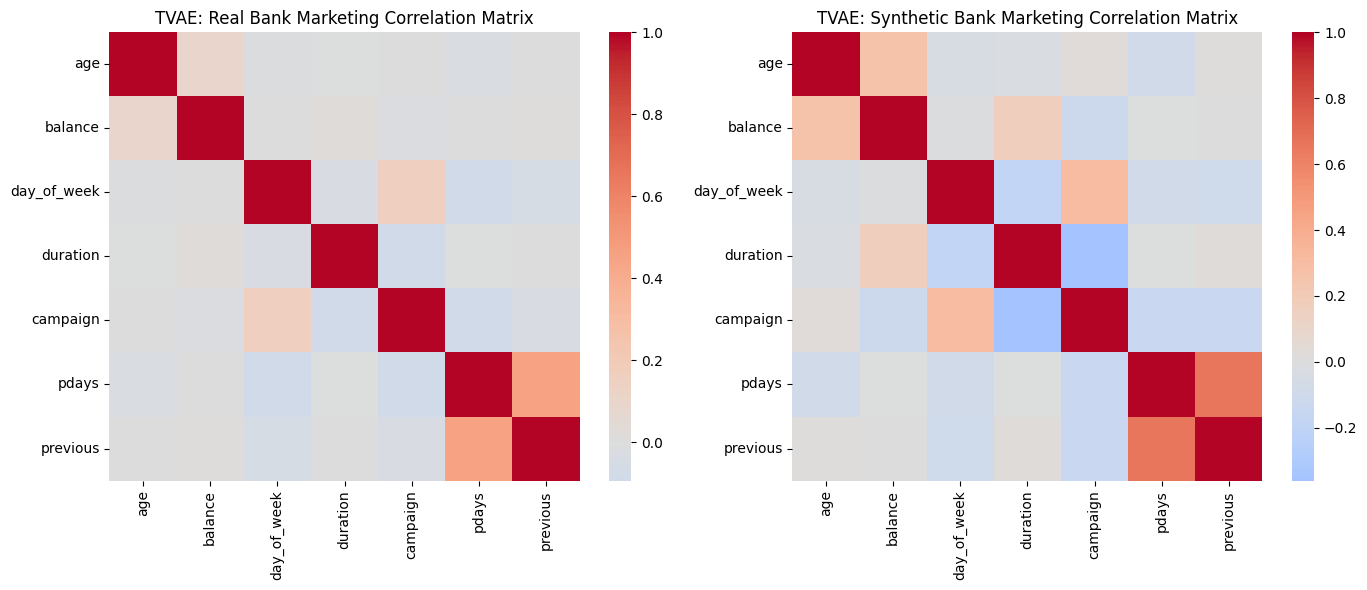

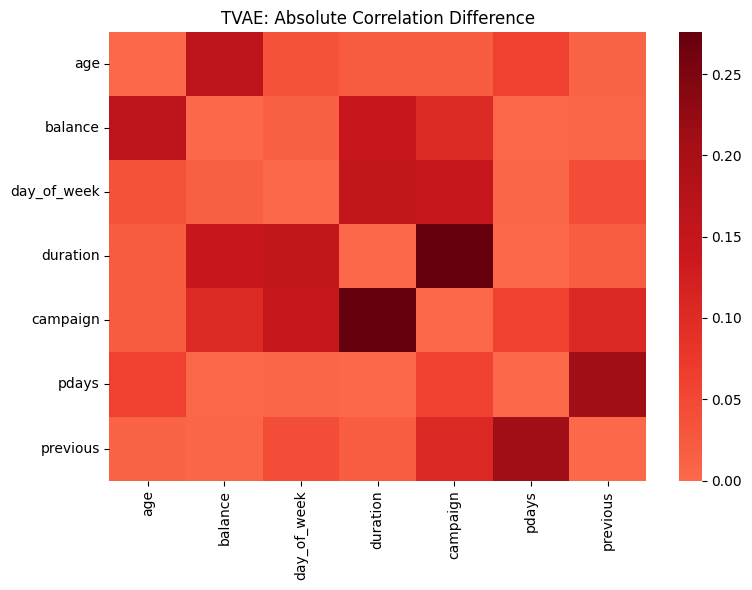

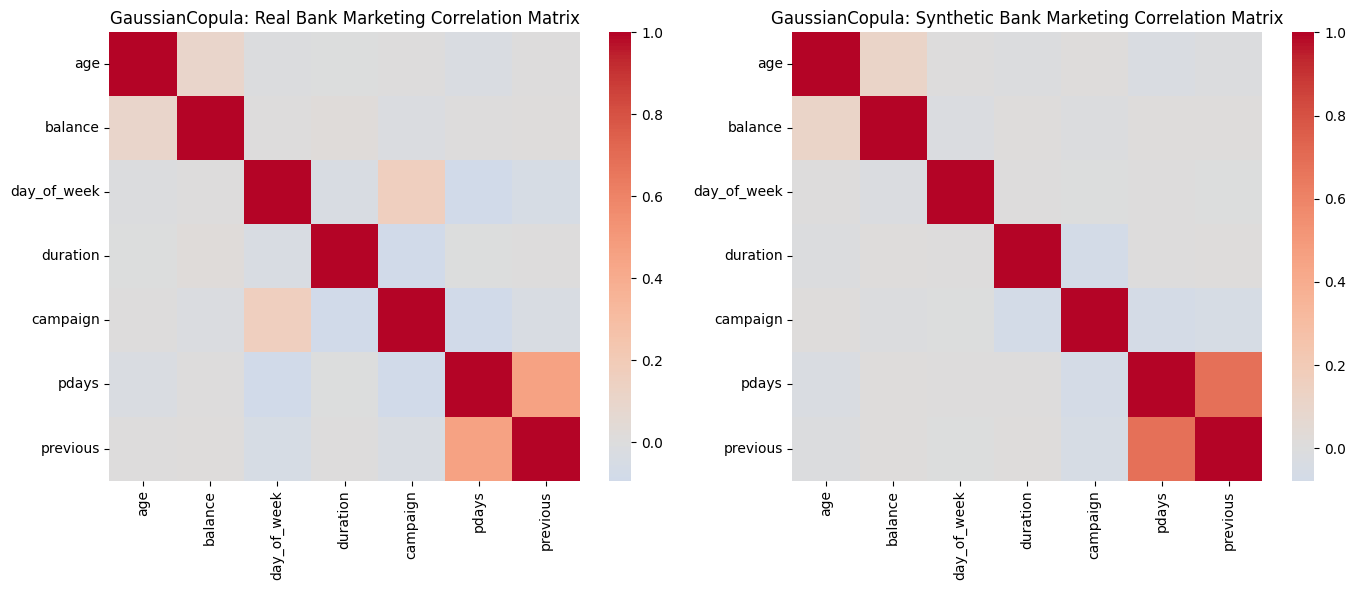

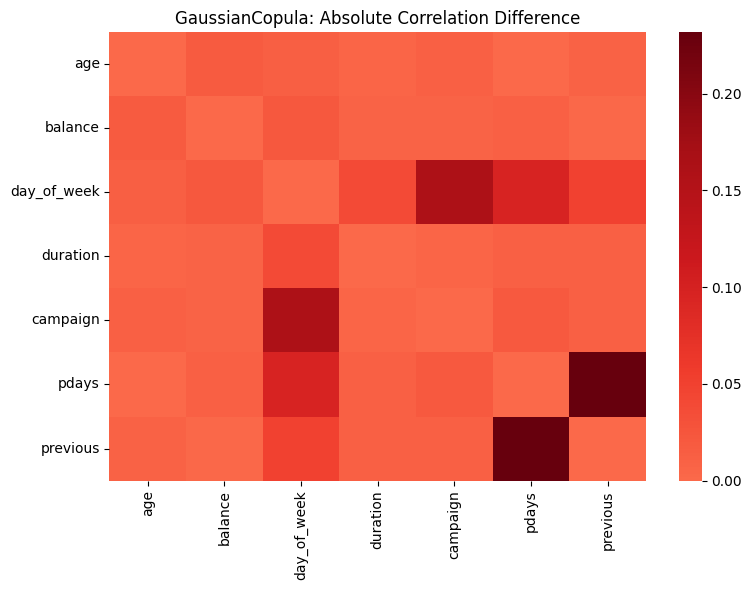

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = data.copy()
target_col = "y"

num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

real_num = real_df[num_cols].apply(pd.to_numeric, errors="coerce")
real_corr = real_num.corr()

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_df = synth_df.reindex(columns=real_df.columns)

    synth_num = synth_df[num_cols].apply(pd.to_numeric, errors="coerce")
    synth_corr = synth_num.corr()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.heatmap(real_corr, cmap="coolwarm", center=0, ax=axes[0])
    axes[0].set_title(f"{model_name}: Real Bank Marketing Correlation Matrix")

    sns.heatmap(synth_corr, cmap="coolwarm", center=0, ax=axes[1])
    axes[1].set_title(f"{model_name}: Synthetic Bank Marketing Correlation Matrix")

    plt.tight_layout()
    plt.show()

    diff_corr = (real_corr - synth_corr).abs()
    plt.figure(figsize=(8, 6))
    sns.heatmap(diff_corr, cmap="Reds", center=0)
    plt.title(f"{model_name}: Absolute Correlation Difference")
    plt.tight_layout()
    plt.show()


CTGAN - Global MMD (RBF): 0.003042


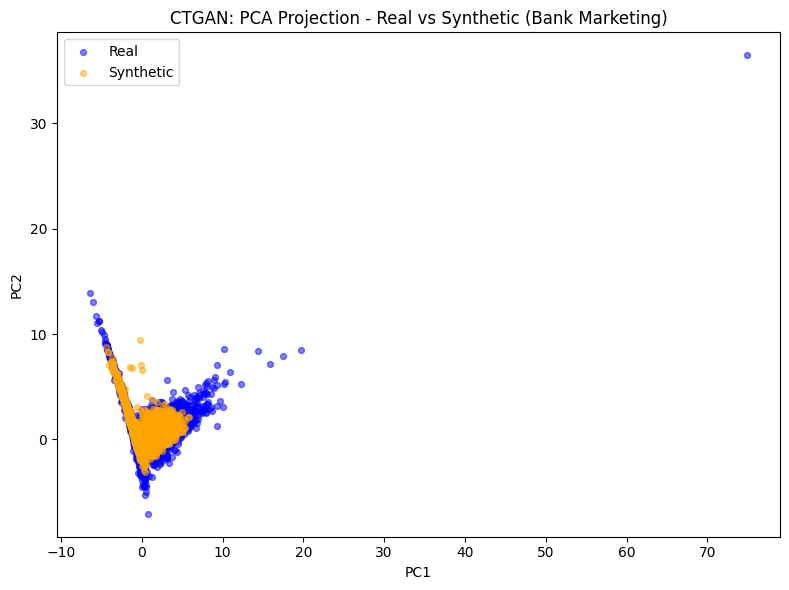

CTGAN - Two-Sample Classifier Accuracy: 0.8825

CopulaGAN - Global MMD (RBF): 0.014594


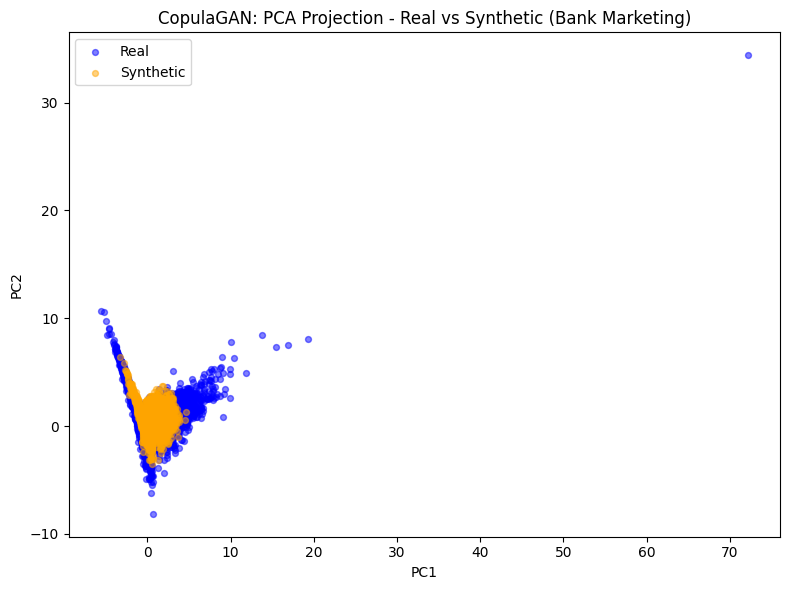

CopulaGAN - Two-Sample Classifier Accuracy: 0.9788

TVAE - Global MMD (RBF): 0.025269


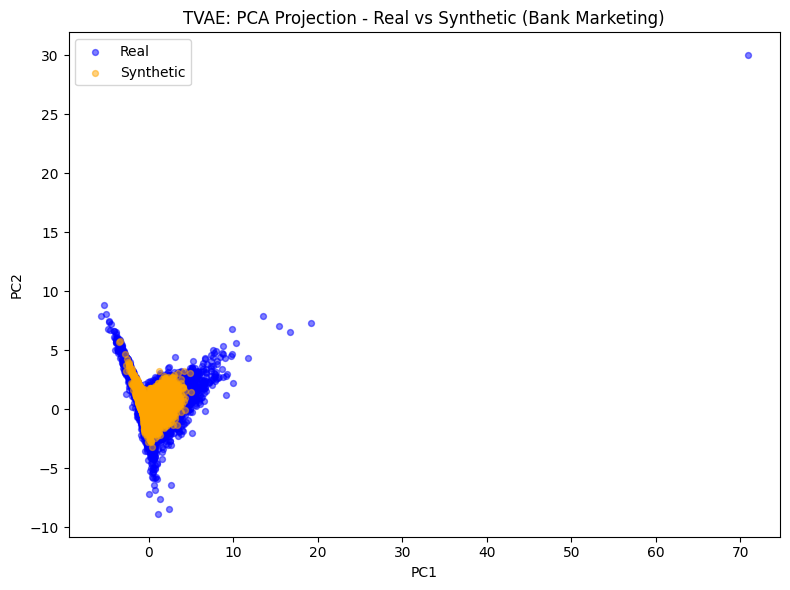

TVAE - Two-Sample Classifier Accuracy: 0.8785

GaussianCopula - Global MMD (RBF): 0.050541


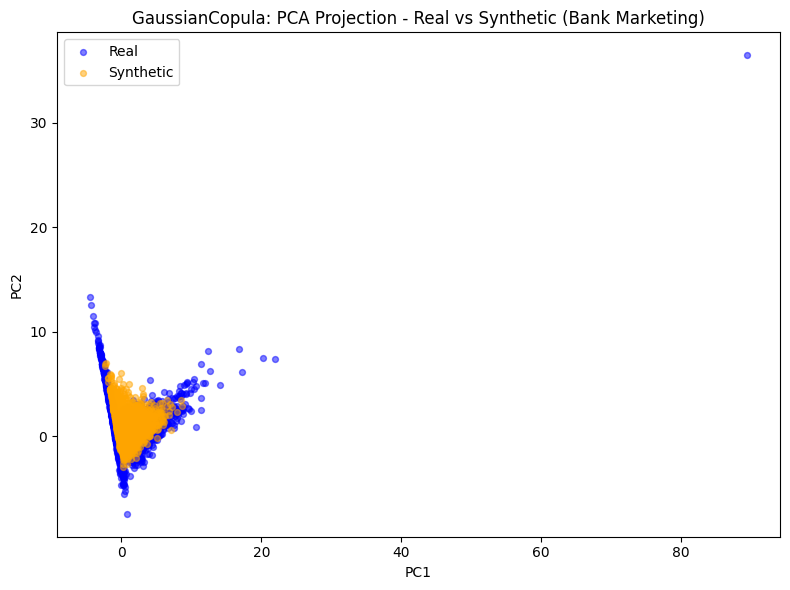

GaussianCopula - Two-Sample Classifier Accuracy: 0.9861

Summary (lower MMD and lower C2ST accuracy generally indicate better overlap):


,Model,Global_MMD_RBF,C2ST_Accuracy
0,CTGAN,0.003042,0.882456
1,CopulaGAN,0.014594,0.978809
2,TVAE,0.025269,0.878532
3,GaussianCopula,0.050541,0.986054


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

def mmd_rbf(X, Y, gamma=None, gamma_sample_size=1000, mmd_sample_size=2000):
    rng = np.random.default_rng(42)

    if gamma is None:
        Z = np.vstack([X, Y])
        n = len(Z)
        k = min(gamma_sample_size, n)
        idx = rng.choice(n, size=k, replace=False)
        Zs = Z[idx]

        p = min(300, len(Zs))
        idx2 = rng.choice(len(Zs), size=p, replace=False)
        Zp = Zs[idx2]
        d2 = np.sum((Zp[:, None, :] - Zp[None, :, :]) ** 2, axis=2)
        vals = d2[np.triu_indices_from(d2, k=1)]
        med = np.median(vals[vals > 0]) if np.any(vals > 0) else 1.0
        gamma = 1.0 / (2.0 * med)

    ix = rng.choice(len(X), size=min(mmd_sample_size, len(X)), replace=False)
    iy = rng.choice(len(Y), size=min(mmd_sample_size, len(Y)), replace=False)
    Xs = X[ix]
    Ys = Y[iy]

    Kxx = rbf_kernel(Xs, Xs, gamma=gamma)
    Kyy = rbf_kernel(Ys, Ys, gamma=gamma)
    Kxy = rbf_kernel(Xs, Ys, gamma=gamma)

    n, m = len(Xs), len(Ys)
    return ((Kxx.sum() - np.trace(Kxx)) / (n * (n - 1))
            + (Kyy.sum() - np.trace(Kyy)) / (m * (m - 1))
            - 2 * Kxy.mean())

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "y"

drop_cols = [target_col]

X_real_df = data.drop(columns=drop_cols, errors="ignore").copy()
X_real_df = X_real_df.select_dtypes(include=[np.number]).copy()

results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    X_synth_df = synth_df.drop(columns=drop_cols, errors="ignore").copy()
    X_synth_df = X_synth_df.select_dtypes(include=[np.number]).copy()

    common_cols = X_real_df.columns.intersection(X_synth_df.columns)
    X_real = X_real_df[common_cols].to_numpy(dtype=np.float64)
    X_synth = X_synth_df[common_cols].to_numpy(dtype=np.float64)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    mmd_value = mmd_rbf(X_real_scaled, X_synth_scaled)
    print(f"\n{model_name} - Global MMD (RBF): {mmd_value:.6f}")

    pca = PCA(n_components=2, random_state=42)
    X_all = np.vstack([X_real_scaled, X_synth_scaled])
    labels = np.array(["Real"] * len(X_real_scaled) + ["Synthetic"] * len(X_synth_scaled))
    X_pca = pca.fit_transform(X_all)

    plt.figure(figsize=(8, 6))
    plt.scatter(
        X_pca[labels == "Real", 0],
        X_pca[labels == "Real", 1],
        color="blue",
        alpha=0.5,
        label="Real",
        s=18
    )
    plt.scatter(
        X_pca[labels == "Synthetic", 0],
        X_pca[labels == "Synthetic", 1],
        color="orange",
        alpha=0.5,
        label="Synthetic",
        s=18
    )
    plt.title(f"{model_name}: PCA Projection - Real vs Synthetic (Bank Marketing)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

    y_real = np.ones(len(X_real_scaled))
    y_synth = np.zeros(len(X_synth_scaled))
    X_c2st = np.vstack([X_real_scaled, X_synth_scaled])
    y_c2st = np.hstack([y_real, y_synth])

    X_train, X_test, y_train, y_test = train_test_split(
        X_c2st, y_c2st, test_size=0.3, stratify=y_c2st, random_state=42
    )

    clf = RandomForestClassifier(n_estimators=200, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"{model_name} - Two-Sample Classifier Accuracy: {acc:.4f}")

    results.append({
        "Model": model_name,
        "Global_MMD_RBF": float(mmd_value),
        "C2ST_Accuracy": float(acc)
    })

results_df = pd.DataFrame(results).sort_values("Global_MMD_RBF").reset_index(drop=True)
print("\nSummary (lower MMD and lower C2ST accuracy generally indicate better overlap):")
display(results_df)

# 4 Utility with 10 classifiers 

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier


models = { 

    'LogReg': LogisticRegression(max_iter=5000, solver='liblinear', random_state=42),
    'SVM-RBF': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(),
    'NaiveBayes': GaussianNB(),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'ExtraTrees':  ExtraTreesClassifier(random_state=42),
    'GradientBoost': GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "MLP": MLPClassifier(max_iter=2000, random_state=42),
}

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import numpy as np

def evaluate_bank_marketing_classification(train_df, test_df, label_col="y", models=None, test_size=0.2, seed=42):
    if models is None:
        raise ValueError("`models` must be provided.")

    X_train = train_df.drop(columns=[label_col], errors="ignore").copy()
    y_train = train_df[label_col].copy()

    X_test = test_df.drop(columns=[label_col], errors="ignore").copy()
    y_test = test_df[label_col].copy()

    X_train, _, y_train, _ = train_test_split(
        X_train, y_train, test_size=test_size, random_state=seed, stratify=y_train
    )
    _, X_test, _, y_test = train_test_split(
        X_test, y_test, test_size=test_size, random_state=seed, stratify=y_test
    )

    num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    X_train_num = X_train[num_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)
    X_test_num = X_test[num_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)

    scaler = StandardScaler().fit(X_train_num)
    X_train_s = scaler.transform(X_train_num)
    X_test_s = scaler.transform(X_test_num)

    rows = []
    for name, clf in models.items():
        clf.fit(X_train_s, y_train)
        y_pred = clf.predict(X_test_s)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
        rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
        f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

        rows.append({
            "Model": name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1": f1
        })

    return pd.DataFrame(rows).sort_values(by="F1", ascending=False).reset_index(drop=True)



CTGAN - TSTR


,Model,Accuracy,Precision,Recall,F1
0,MLP,0.881234,0.852173,0.881234,0.858525
1,AdaBoost,0.875705,0.845355,0.875705,0.854207
2,GradientBoost,0.878912,0.846163,0.878912,0.853585
3,NaiveBayes,0.856906,0.849759,0.856906,0.853138
4,ExtraTrees,0.877253,0.841248,0.877253,0.849735
5,RandomForest,0.872609,0.838718,0.872609,0.849152
6,LogReg,0.880460,0.840338,0.880460,0.845345
7,SVM-RBF,0.885989,0.857960,0.885989,0.843001
8,KNN,0.858343,0.831778,0.858343,0.842666
9,DecisionTree,0.788676,0.819816,0.788676,0.802958


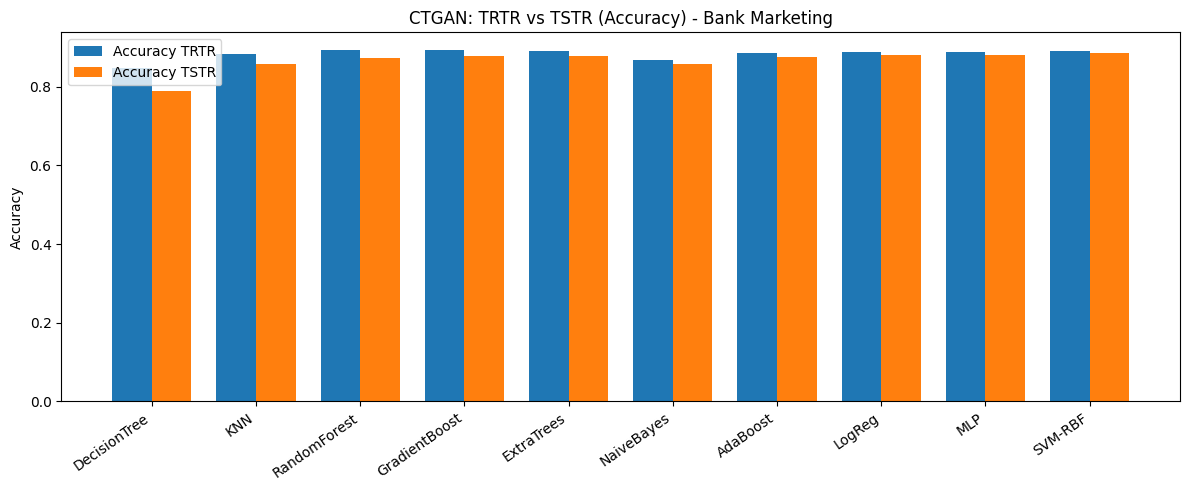

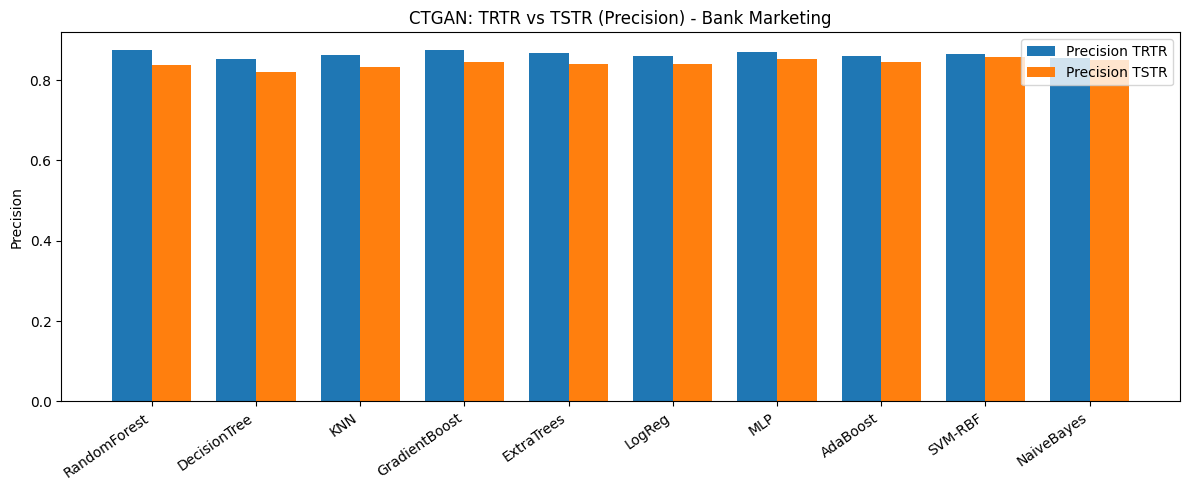

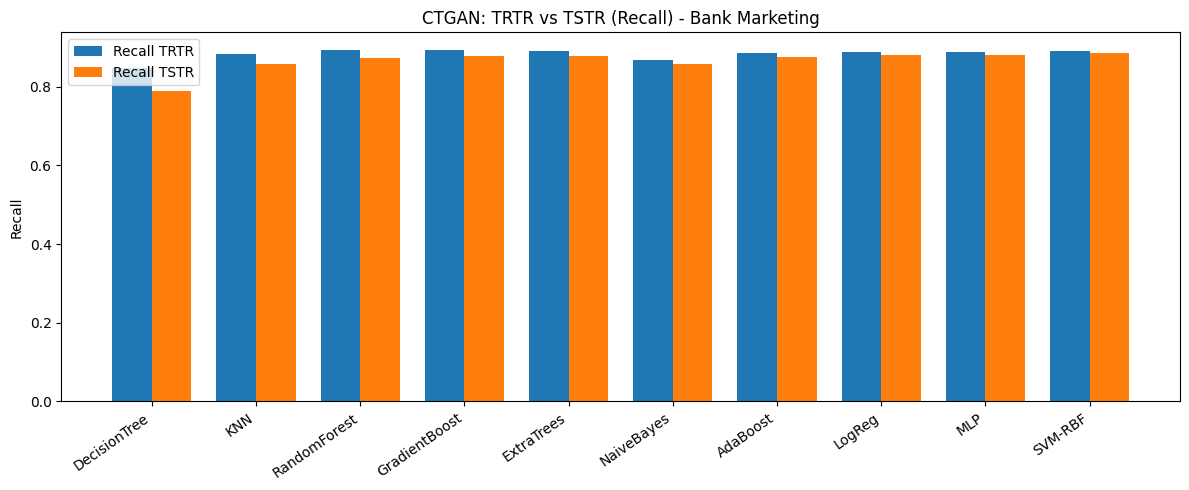

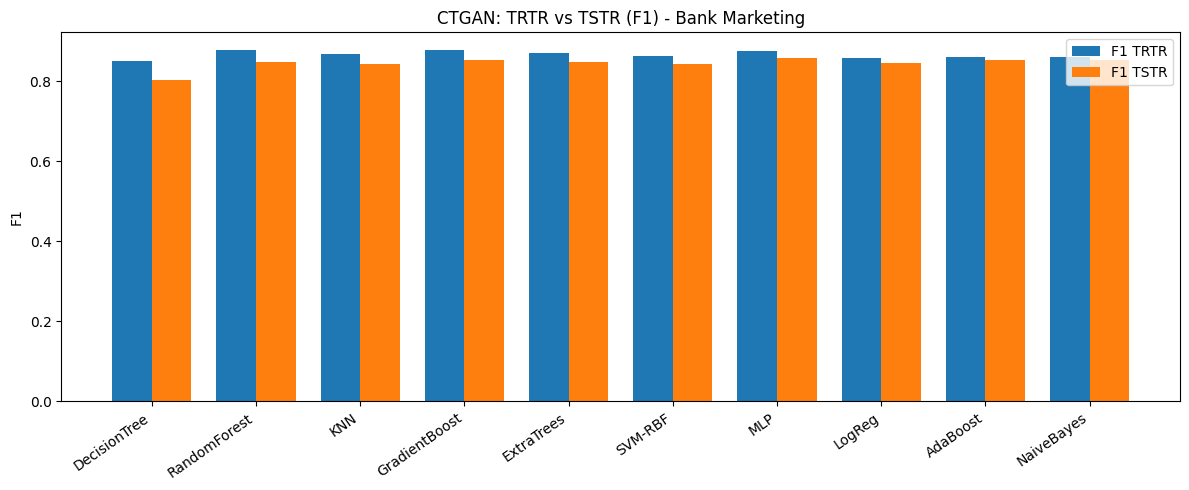

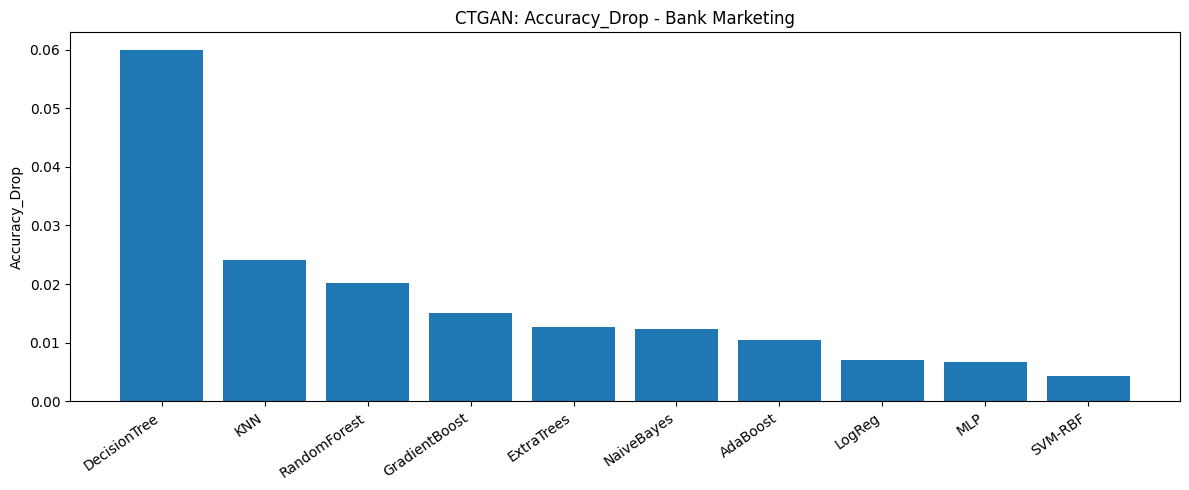

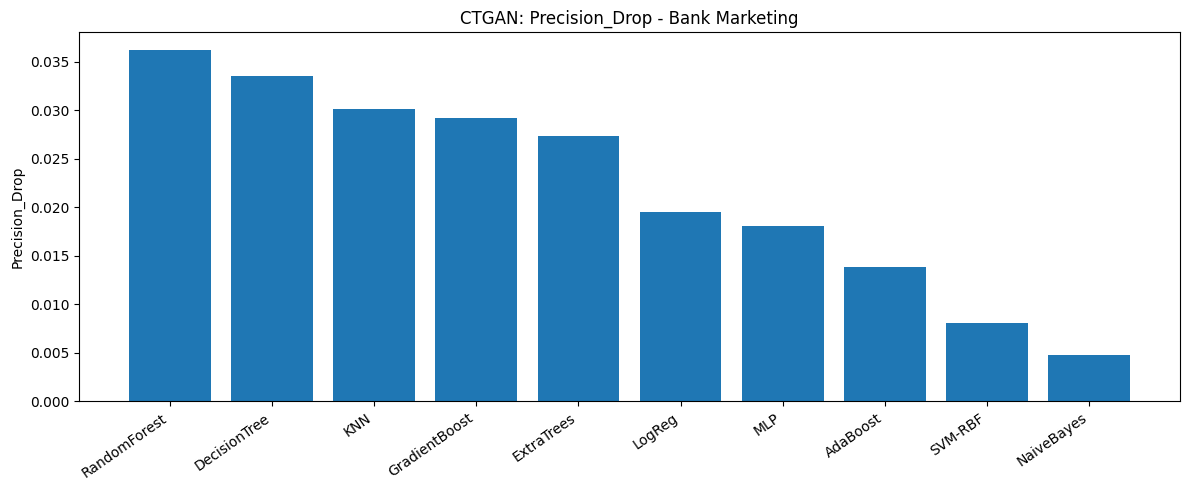

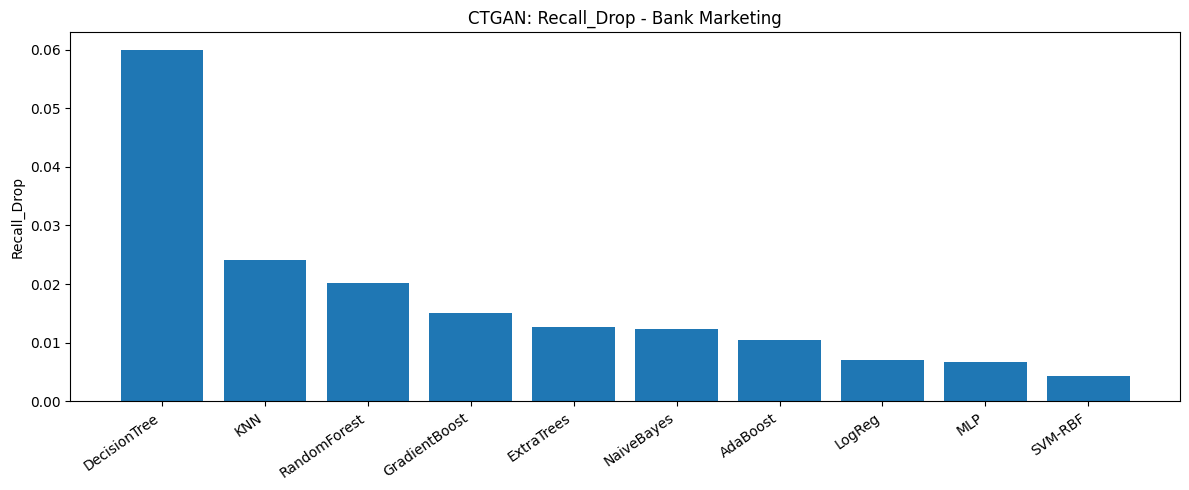

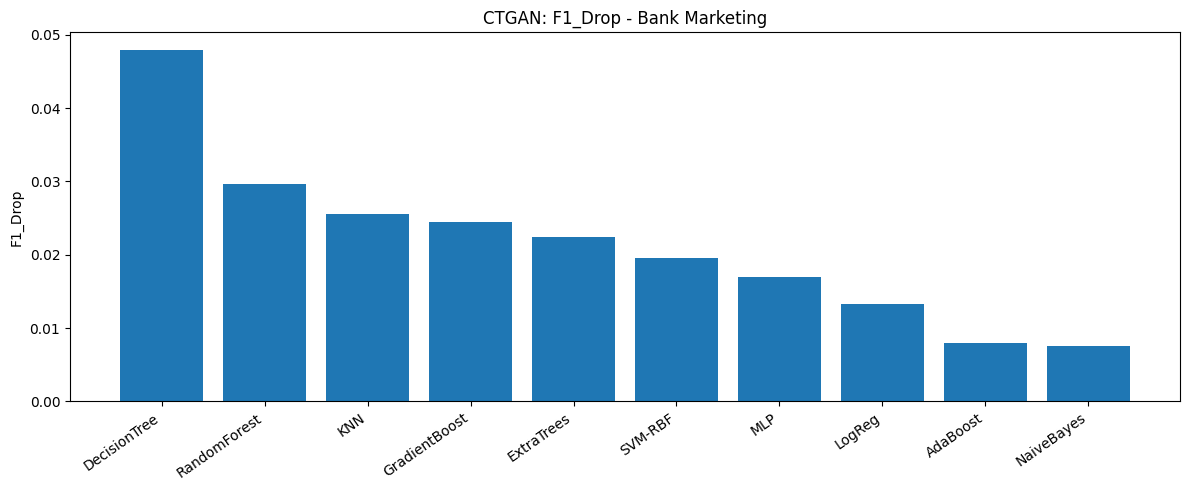


CopulaGAN - TSTR


,Model,Accuracy,Precision,Recall,F1
0,GradientBoost,0.881898,0.866559,0.881898,0.872253
1,LogReg,0.880571,0.863102,0.880571,0.869344
2,SVM-RBF,0.886653,0.860861,0.886653,0.864211
3,MLP,0.880128,0.856733,0.880128,0.863762
4,AdaBoost,0.878138,0.856332,0.878138,0.863606
5,RandomForest,0.863983,0.857691,0.863983,0.860656
6,ExtraTrees,0.864868,0.851530,0.864868,0.857370
7,NaiveBayes,0.839102,0.869350,0.839102,0.851583
8,KNN,0.849718,0.852960,0.849718,0.851304
9,DecisionTree,0.742895,0.830044,0.742895,0.777709


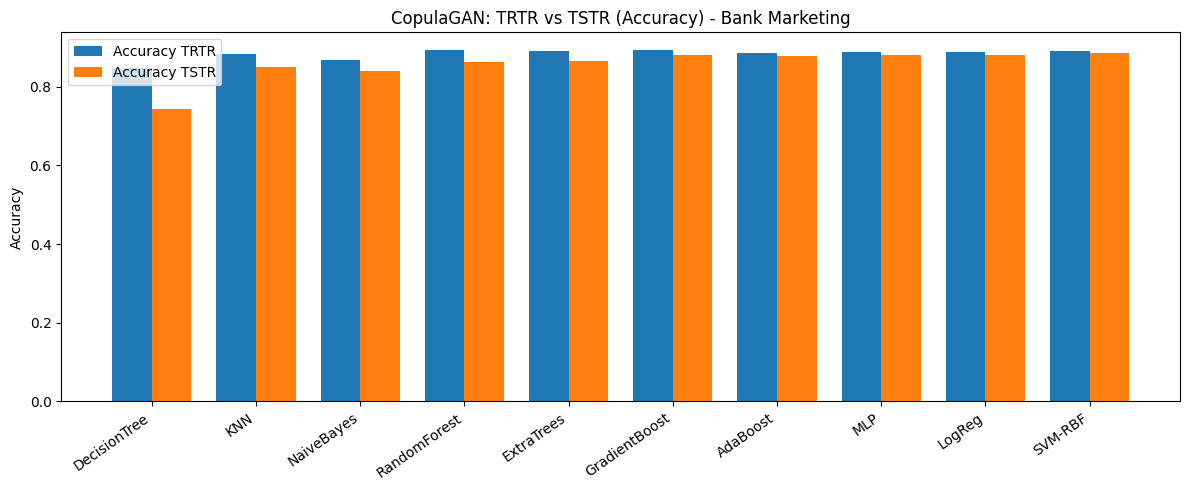

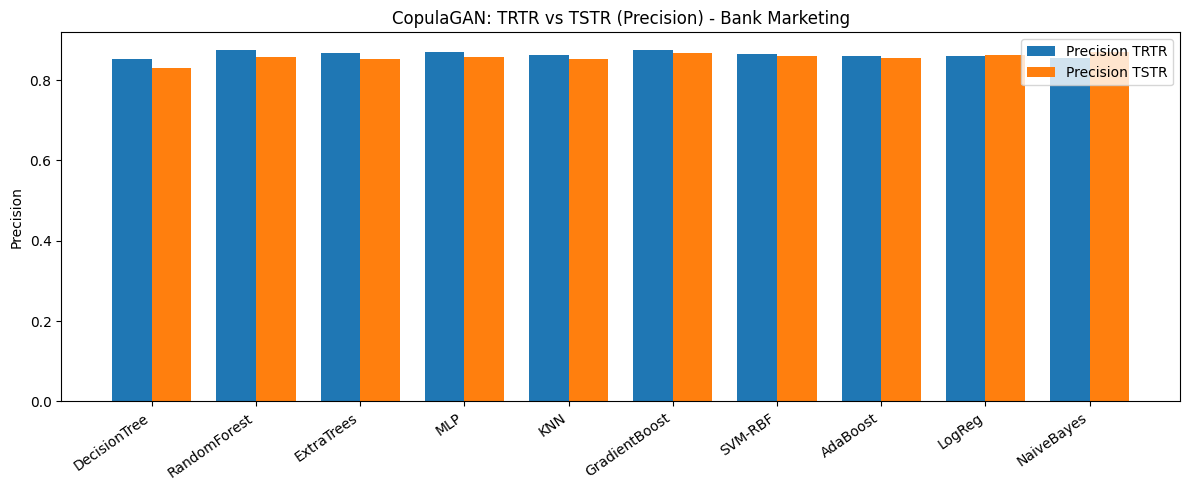

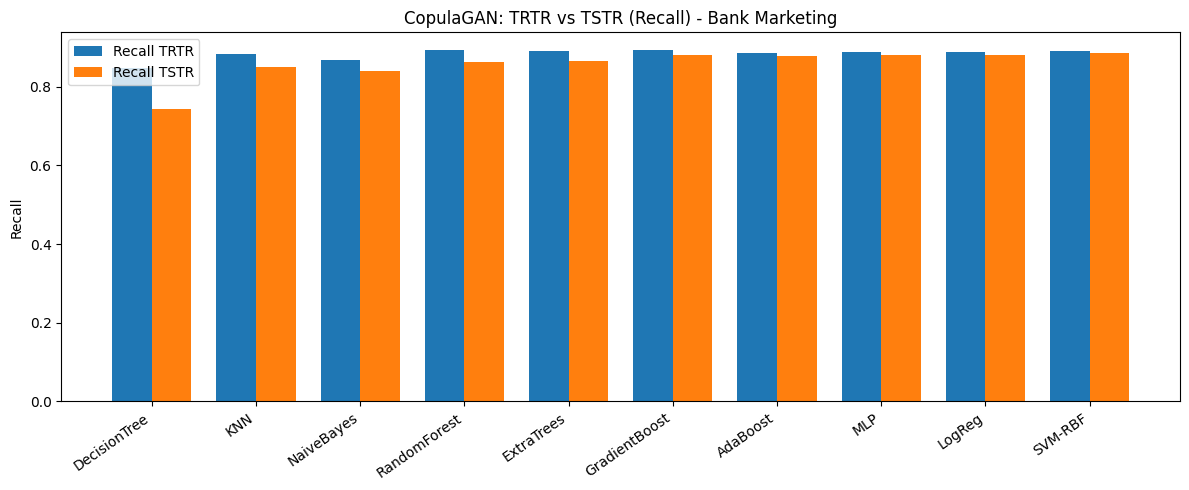

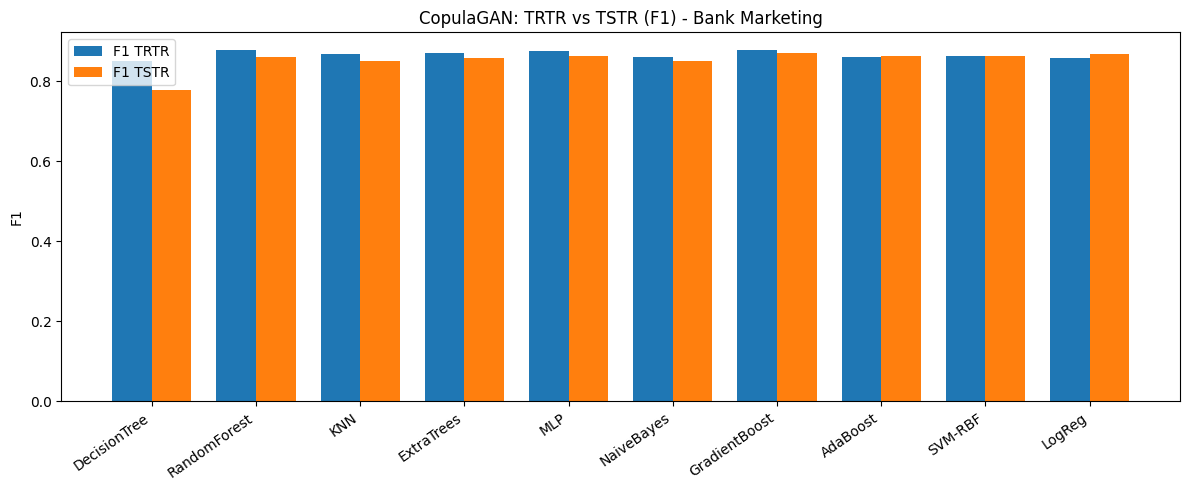

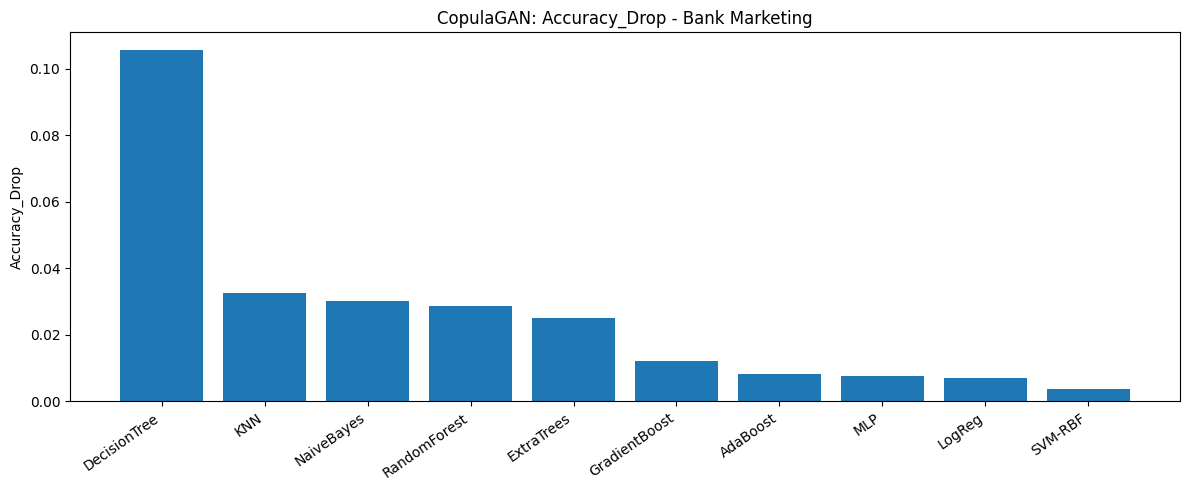

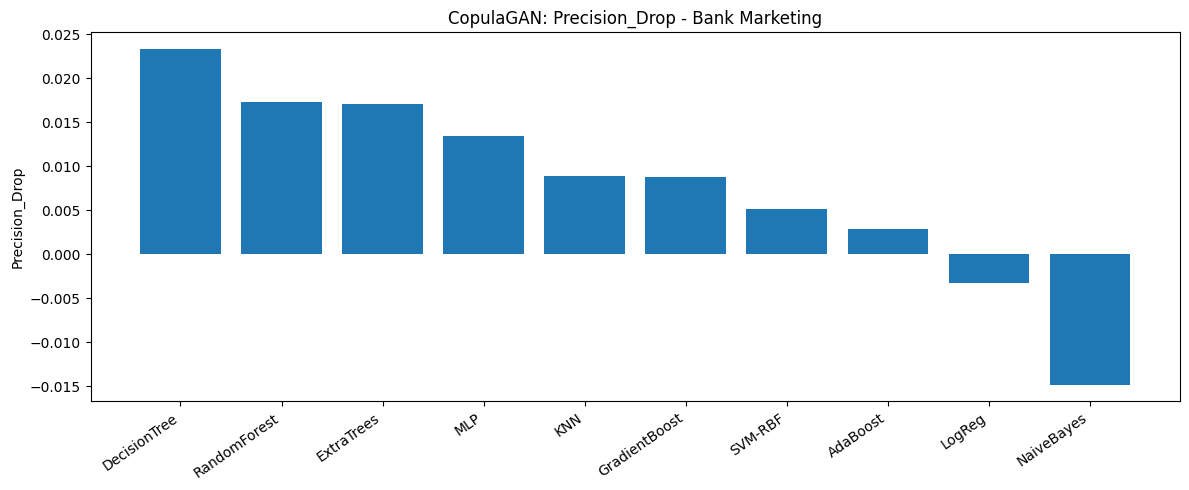

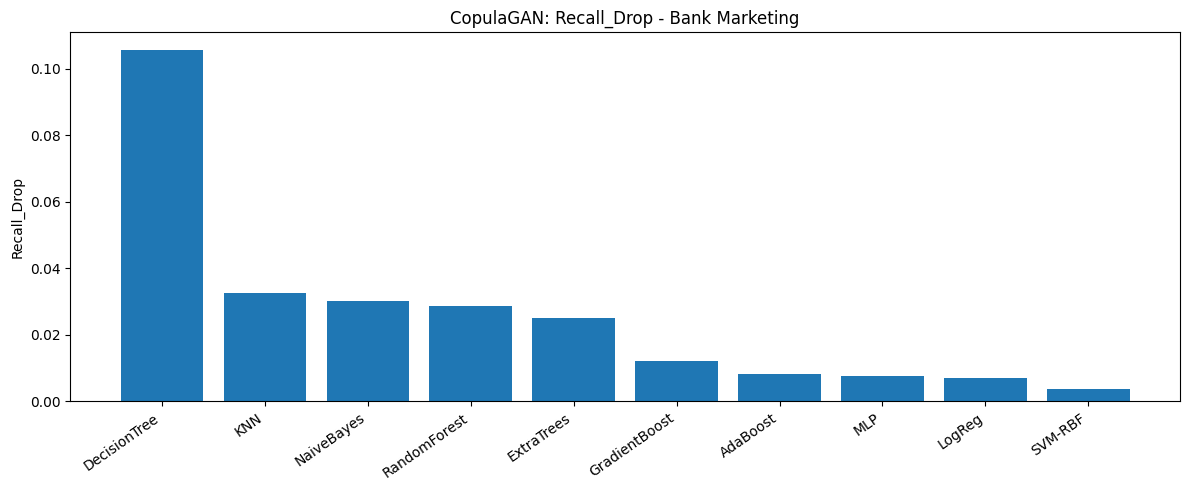

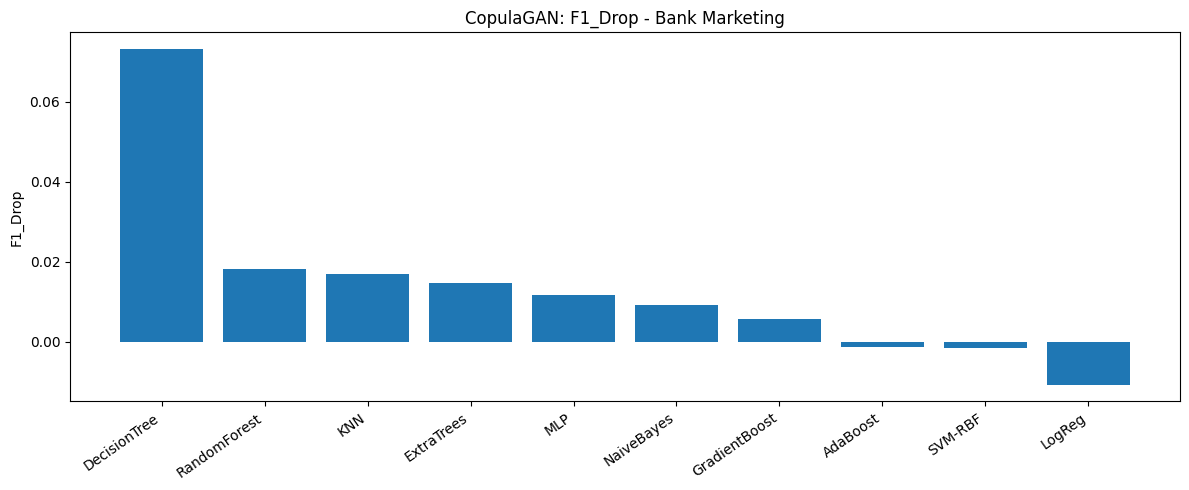


TVAE - TSTR


,Model,Accuracy,Precision,Recall,F1
0,ExtraTrees,0.833352,0.865926,0.833352,0.846806
1,LogReg,0.816101,0.871291,0.816101,0.836950
2,AdaBoost,0.822515,0.850758,0.822515,0.834838
3,MLP,0.812894,0.865181,0.812894,0.833219
4,RandomForest,0.812230,0.860109,0.812230,0.831376
5,SVM-RBF,0.819197,0.846401,0.819197,0.831223
6,KNN,0.804932,0.864867,0.804932,0.827795
7,GradientBoost,0.791994,0.878526,0.791994,0.821655
8,DecisionTree,0.757713,0.858086,0.757713,0.793724
9,NaiveBayes,0.723764,0.867839,0.723764,0.770287


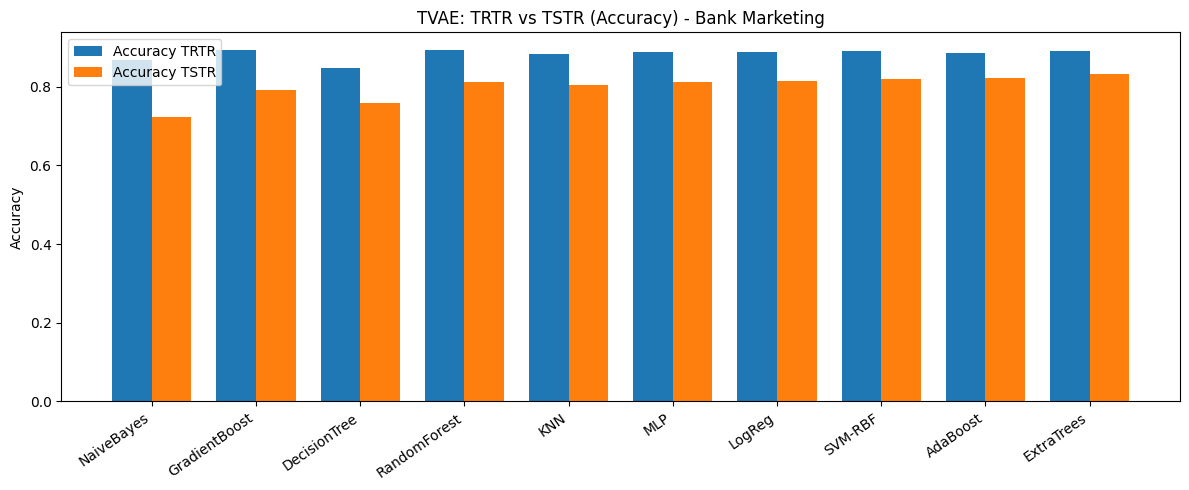

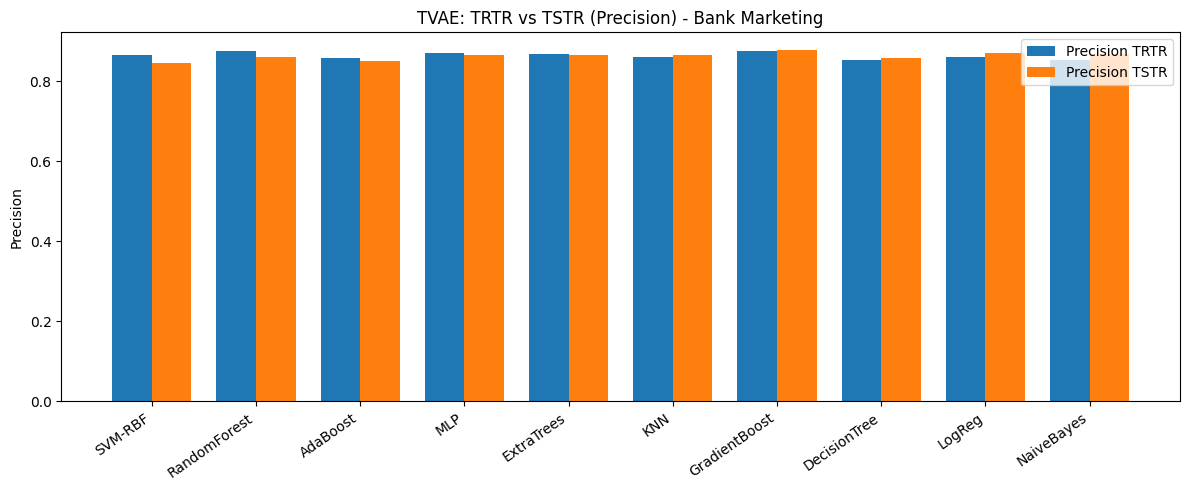

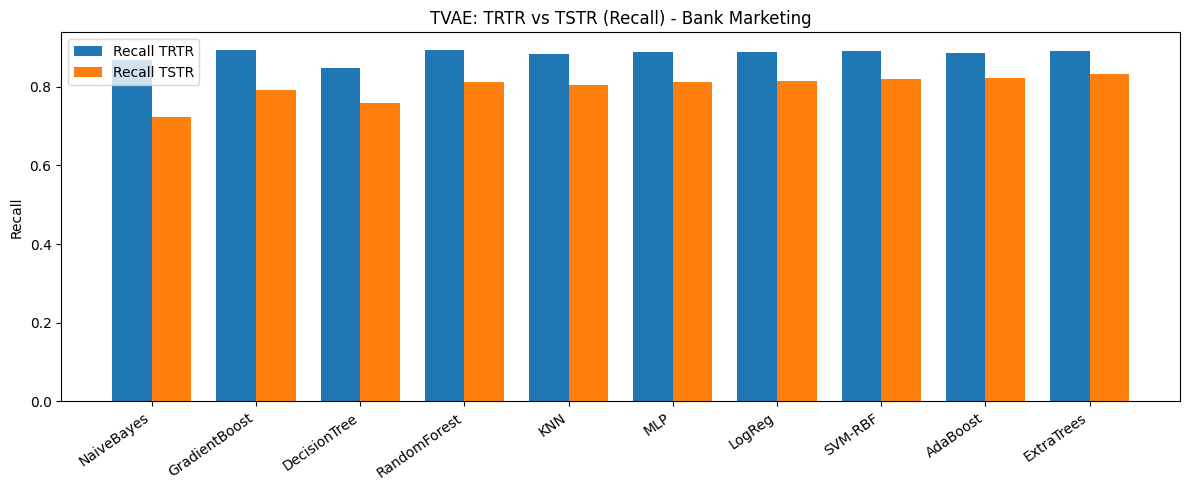

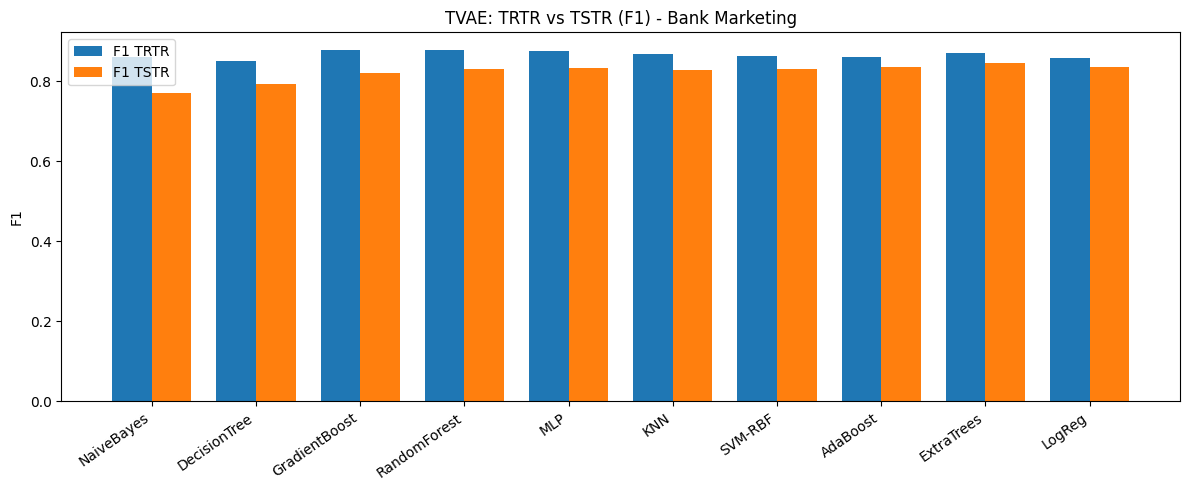

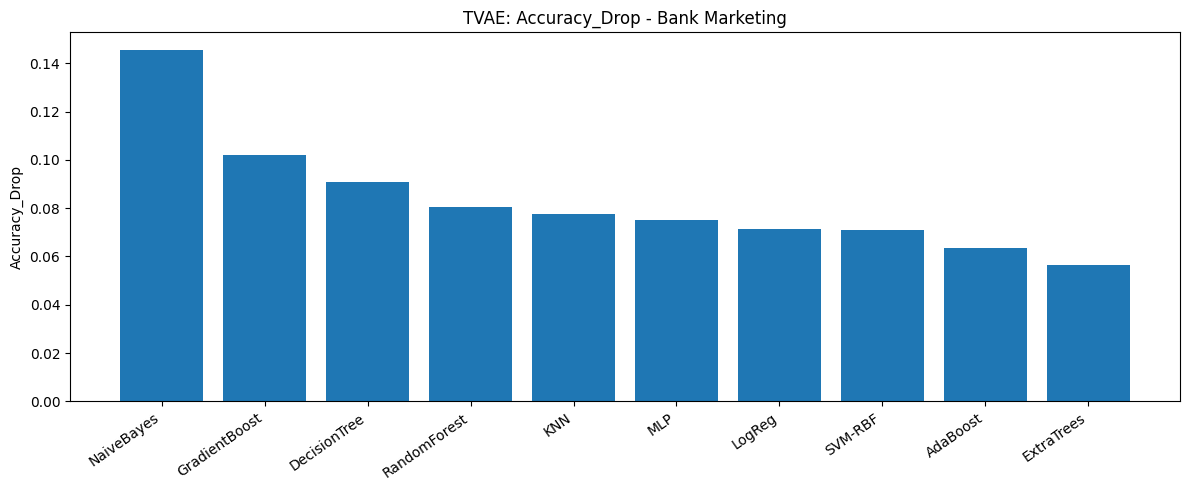

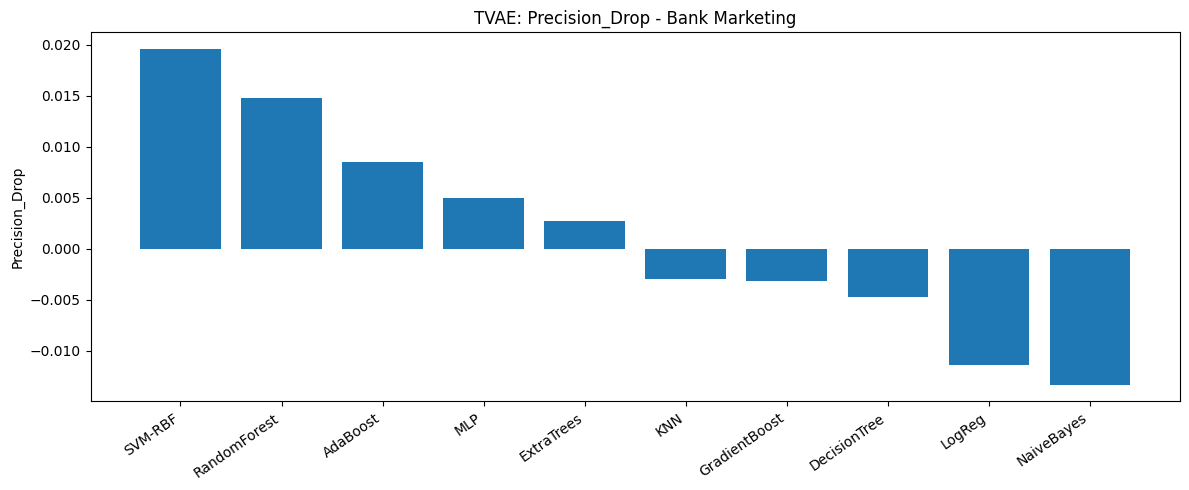

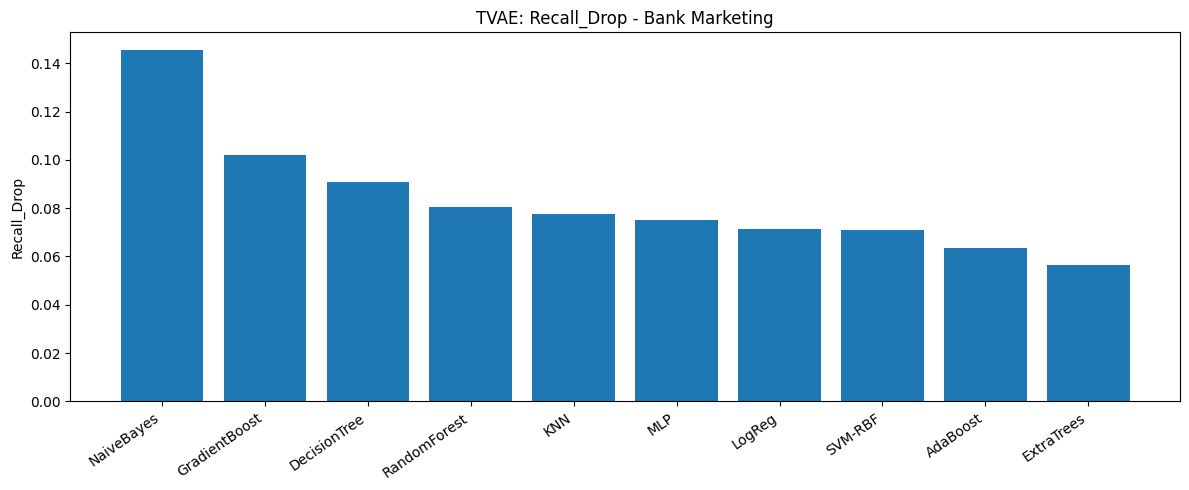

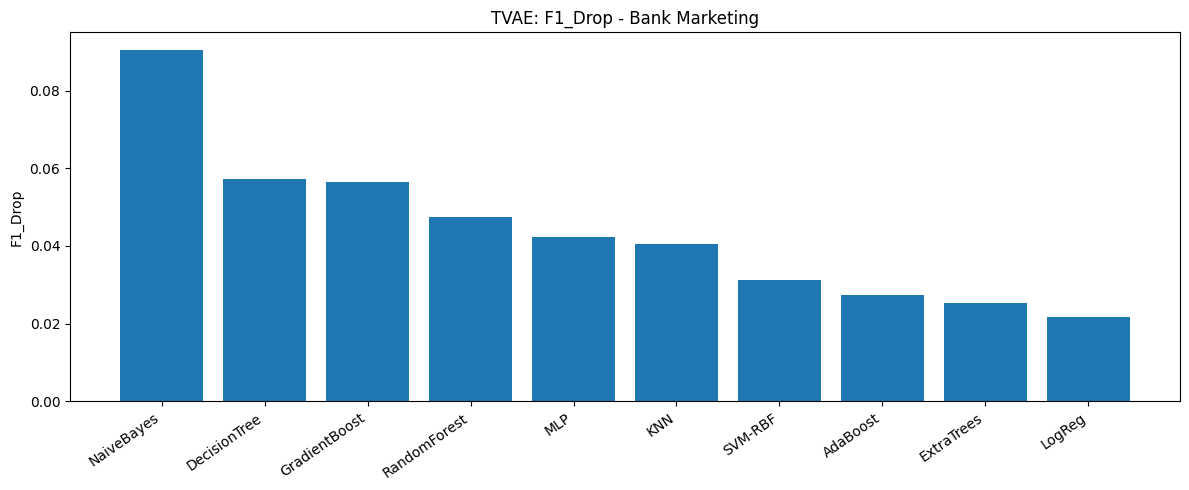


GaussianCopula - TSTR


,Model,Accuracy,Precision,Recall,F1
0,NaiveBayes,0.848170,0.827815,0.848170,0.836896
1,KNN,0.880018,0.827480,0.880018,0.835134
2,LogReg,0.882782,0.837636,0.882782,0.832943
3,MLP,0.883114,0.842033,0.883114,0.830303
4,RandomForest,0.883114,0.842320,0.883114,0.830096
5,GradientBoost,0.881345,0.810316,0.881345,0.828979
6,ExtraTrees,0.882008,0.810755,0.882008,0.828698
7,SVM-RBF,0.883003,0.779695,0.883003,0.828140
8,AdaBoost,0.883003,0.779695,0.883003,0.828140
9,DecisionTree,0.785912,0.806150,0.785912,0.795587


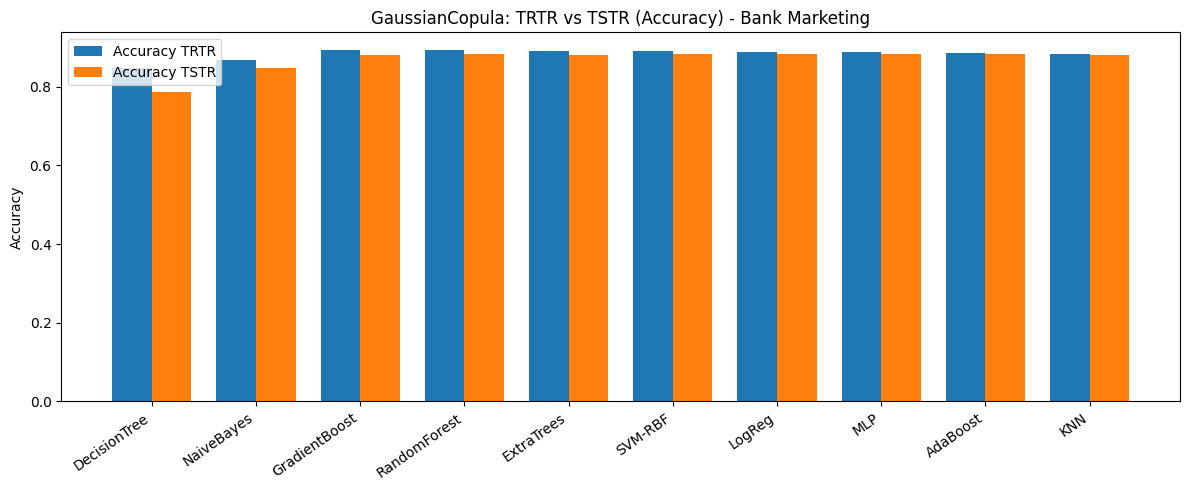

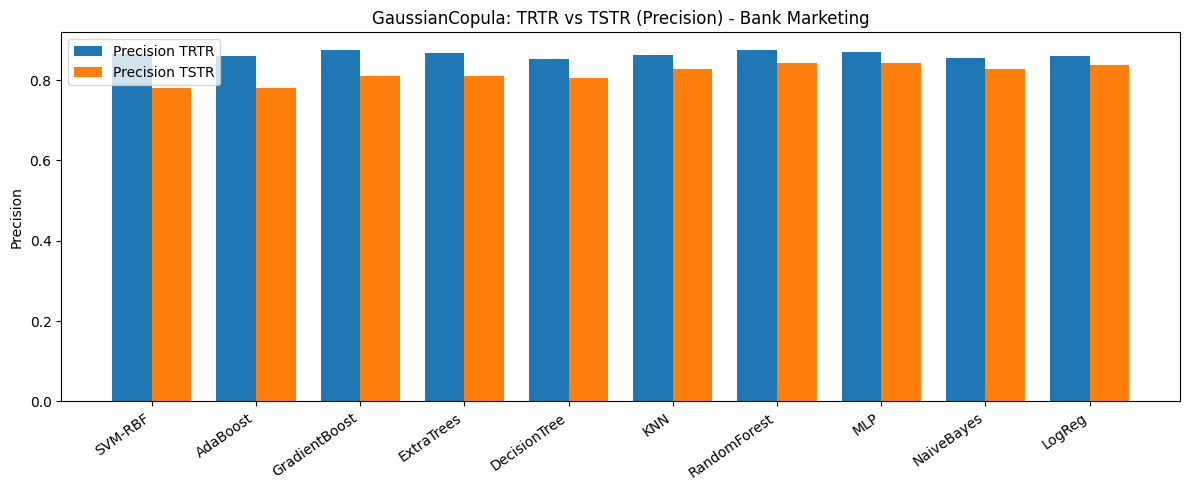

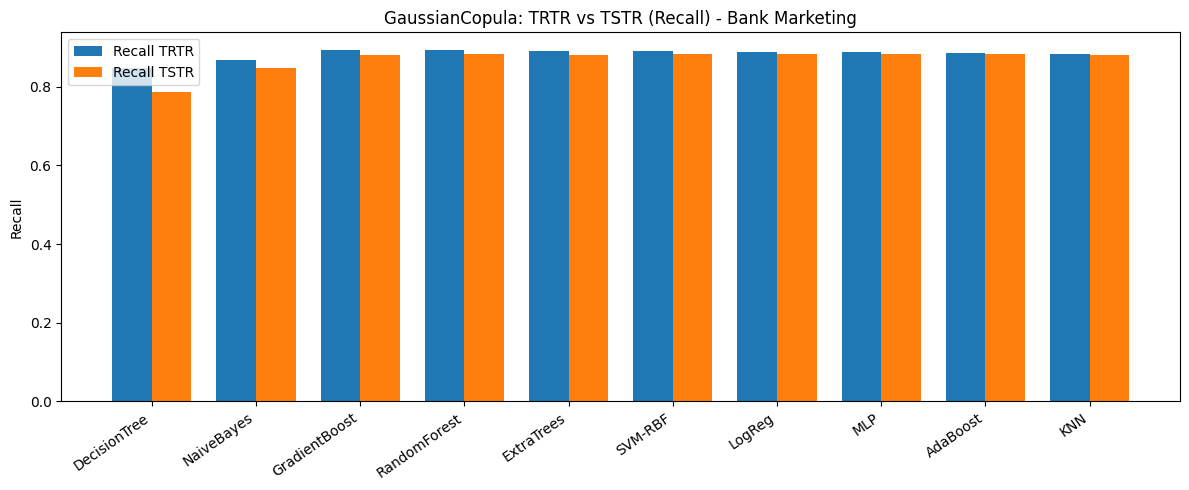

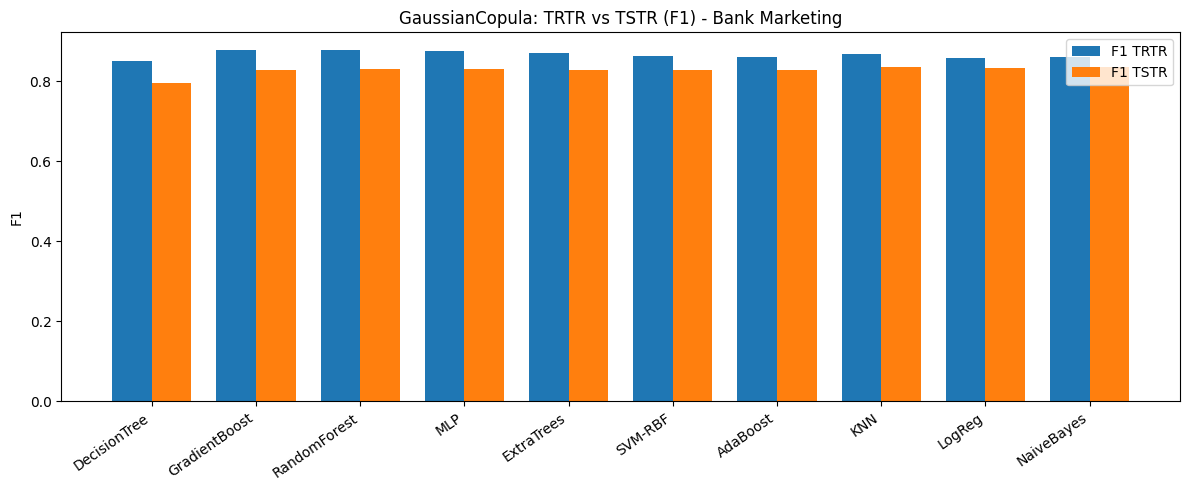

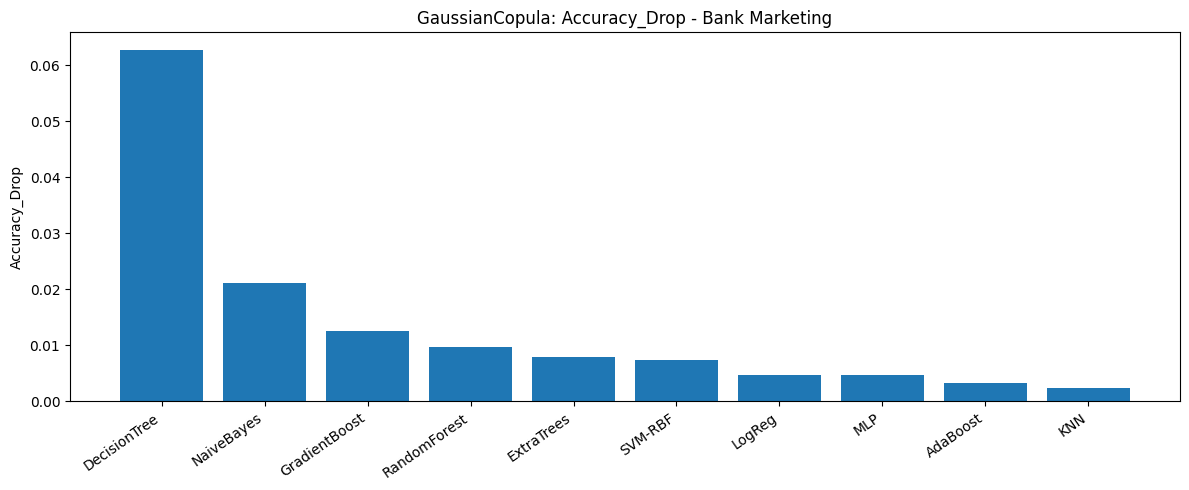

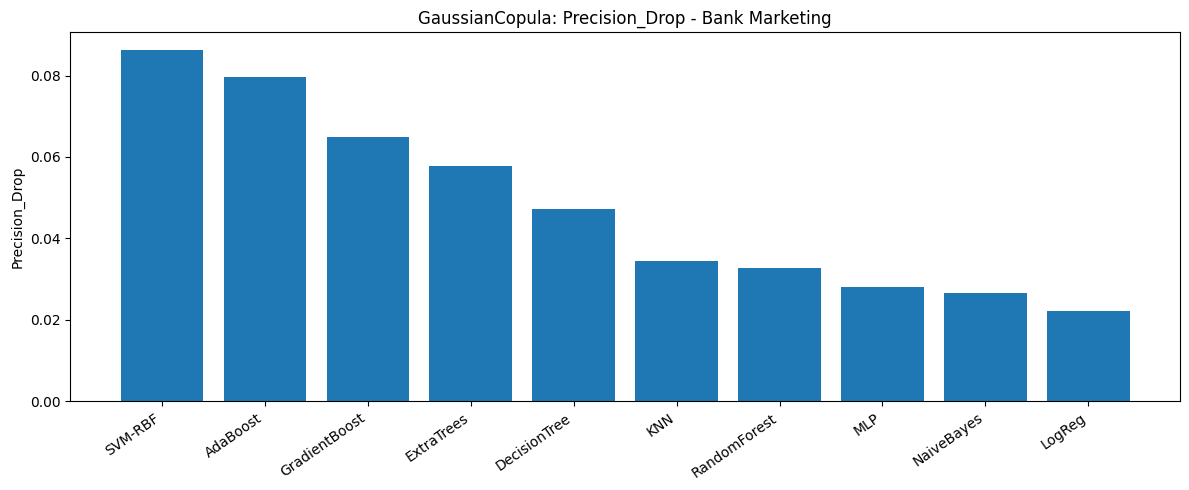

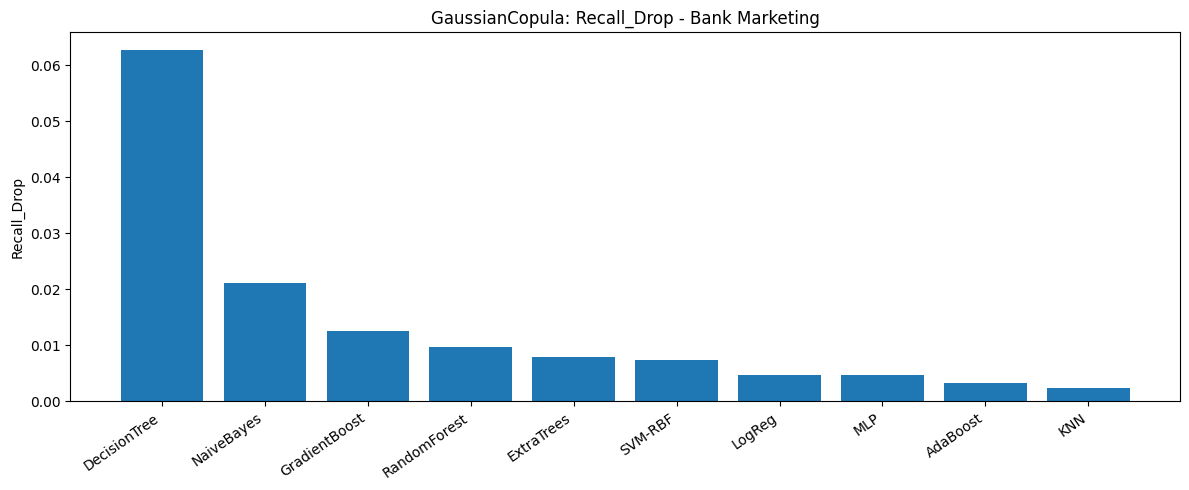

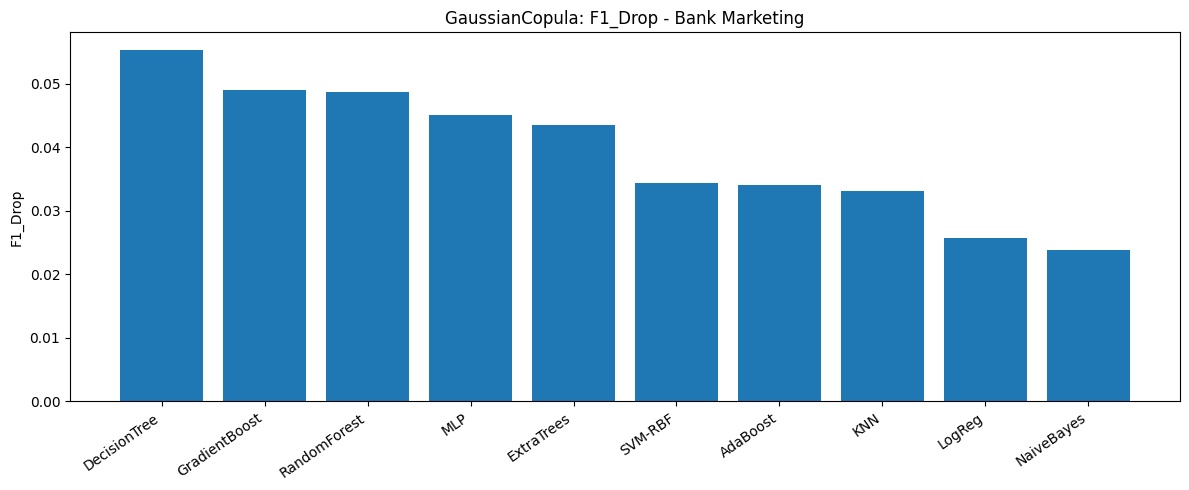


Average metric gap by synthetic generator:


,Synthetic_Model,Accuracy_Drop,Precision_Drop,Recall_Drop,F1_Drop
1,CopulaGAN,0.026098,0.007879,0.026098,0.013589
0,CTGAN,0.017284,0.022064,0.017284,0.021537
2,GaussianCopula,0.013646,0.048005,0.013646,0.039277
3,TVAE,0.083424,0.001497,0.083424,0.043981


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric="F1"):
    if metric not in trtr_results.columns or metric not in tstr_results.columns:
        return

    df = trtr_results[["Model", metric]].merge(
        tstr_results[["Model", metric]],
        on="Model",
        suffixes=("_TRTR", "_TSTR")
    )

    df["Diff"] = df[f"{metric}_TRTR"] - df[f"{metric}_TSTR"]
    df = df.sort_values("Diff", ascending=False)

    x = np.arange(len(df))
    w = 0.38

    plt.figure(figsize=(12, 5))
    plt.bar(x - w / 2, df[f"{metric}_TRTR"], w, label=f"{metric} TRTR")
    plt.bar(x + w / 2, df[f"{metric}_TSTR"], w, label=f"{metric} TSTR")
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel(metric)
    plt.title(f"{synth_name}: TRTR vs TSTR ({metric}) - Bank Marketing")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_metric_diff(comparison_df, synth_name, metric="F1_Drop"):
    if metric not in comparison_df.columns:
        return

    df = comparison_df.sort_values(metric, ascending=False)
    x = np.arange(len(df))

    plt.figure(figsize=(12, 5))
    plt.bar(x, df[metric])
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel(metric)
    plt.title(f"{synth_name}: {metric} - Bank Marketing")
    plt.tight_layout()
    plt.show()

label_col = "y"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

trtr_results = evaluate_bank_marketing_classification(
    train_df=data,
    test_df=data,
    label="y",
    models=models
)

all_comp = []

for synth_name in model_order:
    synth_train = synthetic_datasets[synth_name].reindex(columns=data.columns).copy()

    tstr_results = evaluate_bank_marketing_classification(
        train_df=synth_train,
        test_df=data,
        label="y",
        models=models
    )

    comparison = trtr_results.merge(
        tstr_results, on="Model", suffixes=("_TRTR", "_TSTR")
    )
    comparison["Accuracy_Drop"] = comparison["Accuracy_TRTR"] - comparison["Accuracy_TSTR"]
    comparison["Precision_Drop"] = comparison["Precision_TRTR"] - comparison["Precision_TSTR"]
    comparison["Recall_Drop"] = comparison["Recall_TRTR"] - comparison["Recall_TSTR"]
    comparison["F1_Drop"] = comparison["F1_TRTR"] - comparison["F1_TSTR"]
    comparison["Synthetic_Model"] = synth_name
    all_comp.append(comparison)

    print(f"\n{synth_name} - TSTR")
    display(tstr_results)

    for metric in ["Accuracy", "Precision", "Recall", "F1"]:
        plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric=metric)

    for diff_metric in ["Accuracy_Drop", "Precision_Drop", "Recall_Drop", "F1_Drop"]:
        plot_metric_diff(comparison, synth_name, metric=diff_metric)

combined_comparison = pd.concat(all_comp, ignore_index=True)

summary_gap = (
    combined_comparison
    .groupby("Synthetic_Model", as_index=False)[["Accuracy_Drop", "Precision_Drop", "Recall_Drop", "F1_Drop"]]
    .mean()
    .sort_values("F1_Drop")
)

print("\nAverage metric gap by synthetic generator:")
display(summary_gap)


In [23]:
import time
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

label_col = "y"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

# ---------- SPEED KNOBS ----------
MAX_ROWS_REAL = 1200
MAX_ROWS_SYNTH = 1200
TEST_SIZE = 0.2
SEED = 47
# --------------------------------

def speed_tune_estimator(est):
    e = clone(est)
    params = e.get_params()

    updates = {}
    if "n_jobs" in params:
        updates["n_jobs"] = -1
    if "n_estimators" in params:
        updates["n_estimators"] = min(params.get("n_estimators", 200), 120)
    if "max_iter" in params:
        updates["max_iter"] = min(params.get("max_iter", 1000), 400)
    if "random_state" in params and params["random_state"] is None:
        updates["random_state"] = SEED

    if updates:
        e.set_params(**updates)
    return e

def pick_10_models(models_dict):
    keys = list(models_dict.keys())
    if len(keys) < 10:
        raise ValueError(f"`models` has only {len(keys)} models; need at least 10.")
    chosen = keys[:10]
    return {k: speed_tune_estimator(models_dict[k]) for k in chosen}

def run_clf_models(X_train, y_train, X_test, y_test, models_dict):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    rows = []
    for name, clf in models_dict.items():
        t0 = time.time()
        m = clone(clf)
        m.fit(X_train_s, y_train)
        y_pred = m.predict(X_test_s)

        rows.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
            "Recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
            "F1": f1_score(y_test, y_pred, average="weighted", zero_division=0),
            "FitSec": round(time.time() - t0, 3),
        })
    return pd.DataFrame(rows)

# numeric-only features
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in num_cols if c != label_col]

# sample real once
real_eval = data.sample(n=min(MAX_ROWS_REAL, len(data)), random_state=SEED).copy()
X_real = real_eval[feature_cols].to_numpy(dtype=np.float32)
y_real = real_eval[label_col].to_numpy()

X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X_real, y_real, test_size=TEST_SIZE, random_state=SEED, stratify=y_real
)

models_used = pick_10_models(models)
print(f"Using {len(models_used)} models: {list(models_used.keys())}")

# TRTR baseline
trtr_results = run_clf_models(X_train_real, y_train_real, X_test_real, y_test_real, models_used)

all_comparisons = []

for synth_name in model_order:
    synth_df = synthetic_datasets[synth_name].reindex(columns=data.columns).copy()
    synth_eval = synth_df.sample(n=min(MAX_ROWS_SYNTH, len(synth_df)), random_state=SEED)

    X_synth = synth_eval[feature_cols].to_numpy(dtype=np.float32)
    y_synth = synth_eval[label_col].to_numpy()

    # train on synthetic, test on same real test split
    tstr_results = run_clf_models(X_synth, y_synth, X_test_real, y_test_real, models_used)

    comparison = trtr_results.merge(
        tstr_results, on="Model", suffixes=("_TRTR", "_TSTR")
    )
    comparison["Accuracy_Drop"] = comparison["Accuracy_TRTR"] - comparison["Accuracy_TSTR"]
    comparison["Precision_Drop"] = comparison["Precision_TRTR"] - comparison["Precision_TSTR"]
    comparison["Recall_Drop"] = comparison["Recall_TRTR"] - comparison["Recall_TSTR"]
    comparison["F1_Drop"] = comparison["F1_TRTR"] - comparison["F1_TSTR"]
    comparison["Synthetic_Model"] = synth_name

    all_comparisons.append(comparison)

combined_comparison = pd.concat(all_comparisons, ignore_index=True)

summary = (
    combined_comparison
    .groupby("Synthetic_Model", as_index=False)[["Accuracy_Drop", "Precision_Drop", "Recall_Drop", "F1_Drop"]]
    .mean()
    .sort_values("F1_Drop")
)

print("Average performance gap by synthetic generator (lower is better):")
display(summary)

print("\nPer-model timing (seconds):")
timing_cols = [c for c in combined_comparison.columns if "FitSec" in c]
display(combined_comparison[["Synthetic_Model", "Model"] + timing_cols].sort_values(timing_cols[-1], ascending=False))


Using 10 models: ['LogReg', 'SVM-RBF', 'KNN', 'NaiveBayes', 'DecisionTree', 'RandomForest', 'ExtraTrees', 'GradientBoost', 'AdaBoost', 'MLP']
Average performance gap by synthetic generator (lower is better):


,Synthetic_Model,Accuracy_Drop,Precision_Drop,Recall_Drop,F1_Drop
1,CopulaGAN,0.012500,-0.007589,0.012500,-0.004343
0,CTGAN,0.010833,0.019227,0.010833,0.011361
2,GaussianCopula,0.013750,0.066237,0.013750,0.032164
3,TVAE,0.072500,0.011201,0.072500,0.036297



Per-model timing (seconds):


,Synthetic_Model,Model,FitSec_TRTR,FitSec_TSTR
39,GaussianCopula,MLP,0.757,0.883
9,CTGAN,MLP,0.757,0.830
19,CopulaGAN,MLP,0.757,0.757
29,TVAE,MLP,0.757,0.691
7,CTGAN,GradientBoost,0.147,0.193
5,CTGAN,RandomForest,0.140,0.157
25,TVAE,RandomForest,0.140,0.146
17,CopulaGAN,GradientBoost,0.147,0.145
37,GaussianCopula,GradientBoost,0.147,0.144
35,GaussianCopula,RandomForest,0.140,0.143



CTGAN - TSTR


,Model,Accuracy,Precision,Recall,F1
0,LogReg,0.879100,0.859057,0.879100,0.865920
1,AdaBoost,0.882197,0.859142,0.882197,0.865614
2,GradientBoost,0.880383,0.857345,0.880383,0.864295
3,SVM-RBF,0.890248,0.865967,0.890248,0.864237
4,RandomForest,0.881688,0.856552,0.881688,0.863113
5,ExtraTrees,0.863750,0.842416,0.863750,0.851111
6,KNN,0.863706,0.841538,0.863706,0.850509
7,MLP,0.820353,0.839165,0.820353,0.829030
8,NaiveBayes,0.790317,0.861043,0.790317,0.816963
9,DecisionTree,0.793988,0.827846,0.793988,0.809205


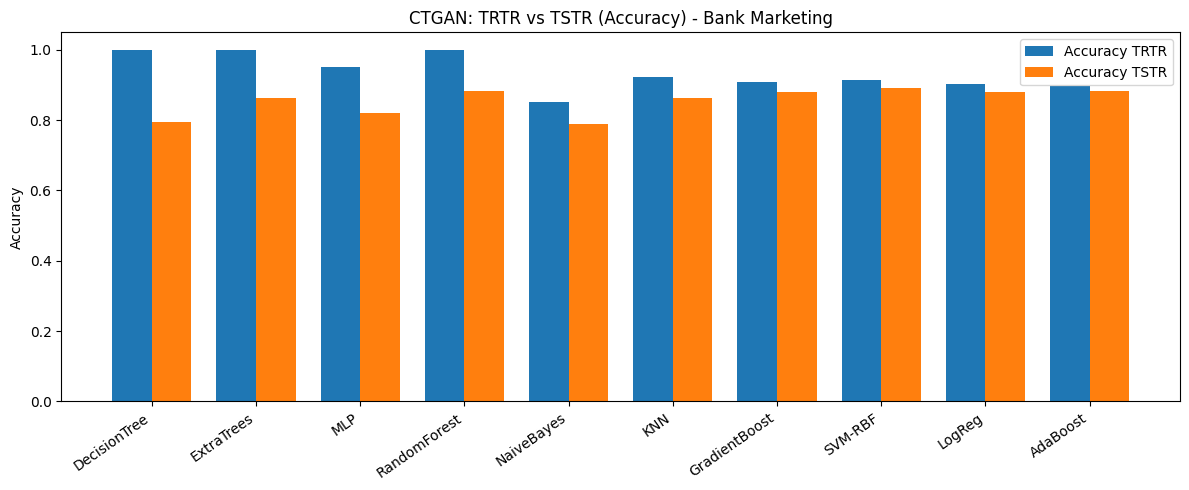

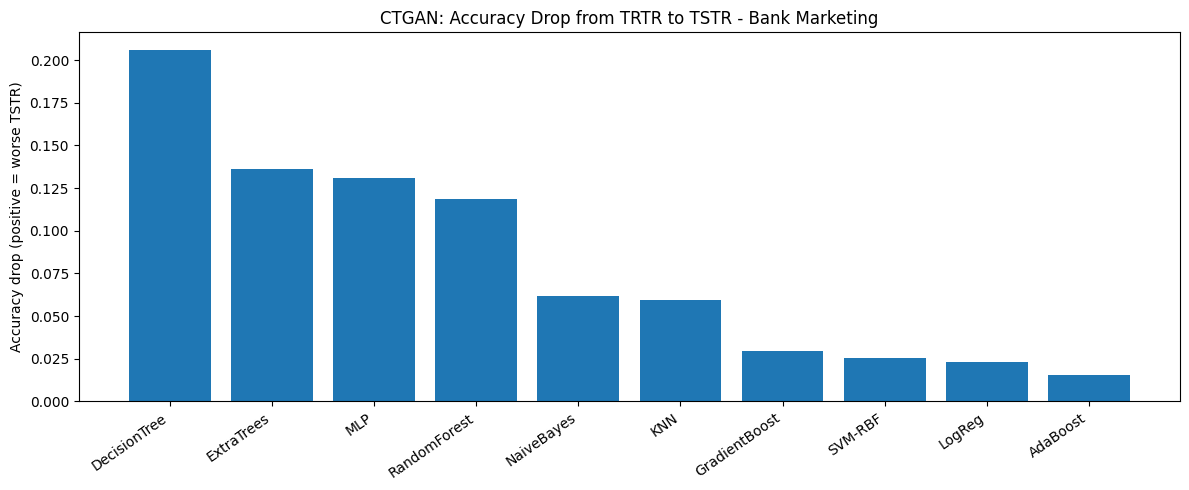

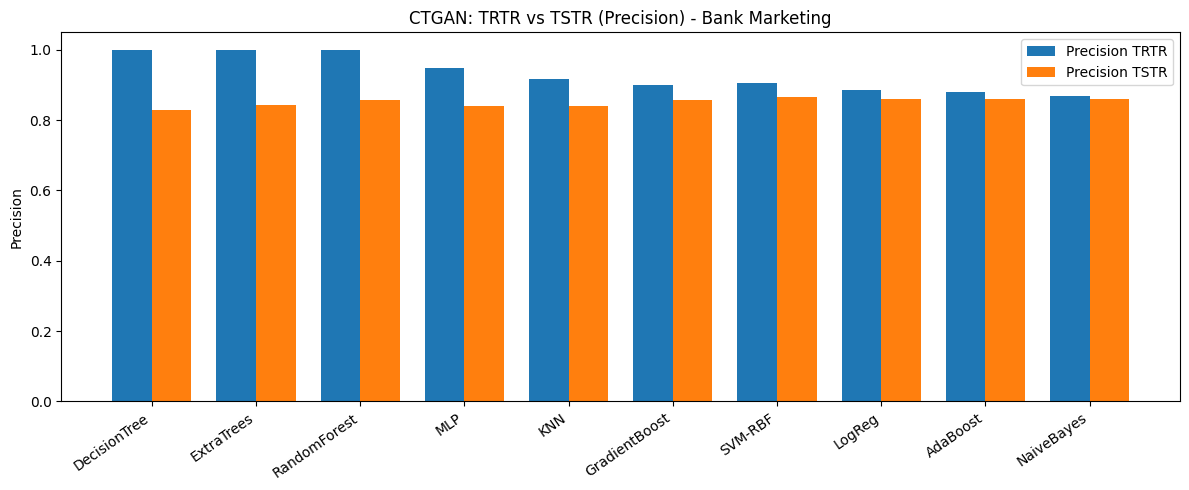

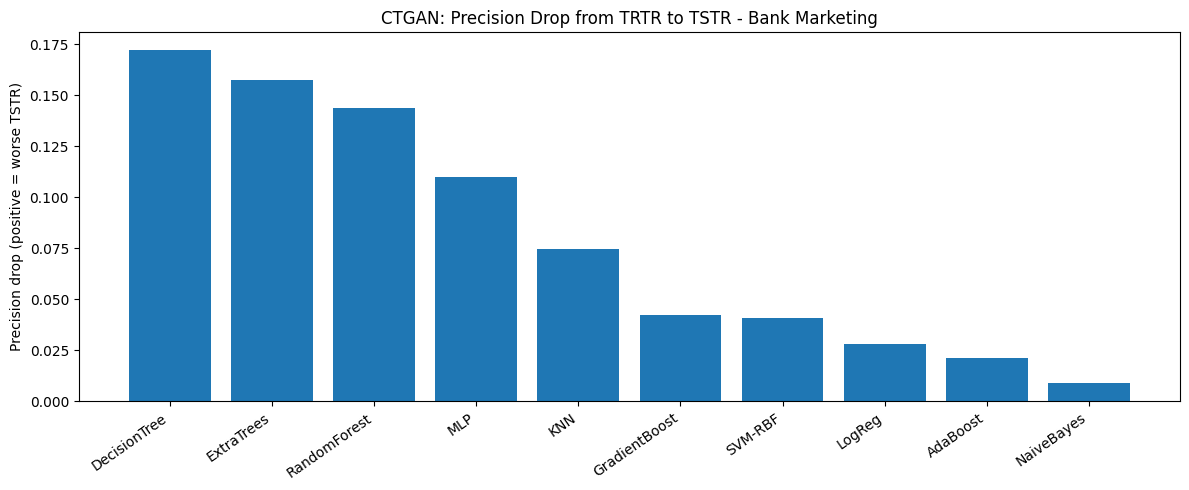

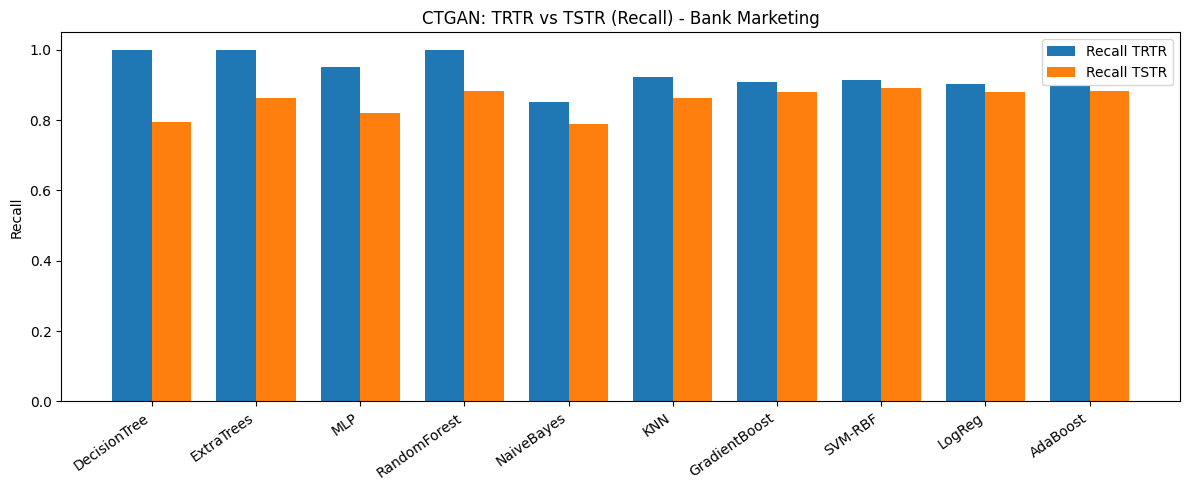

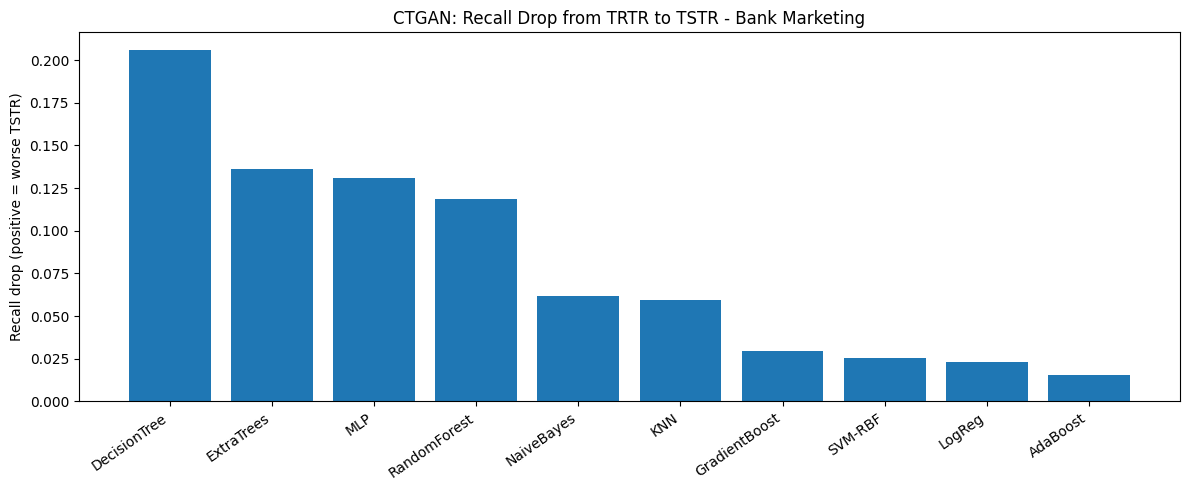

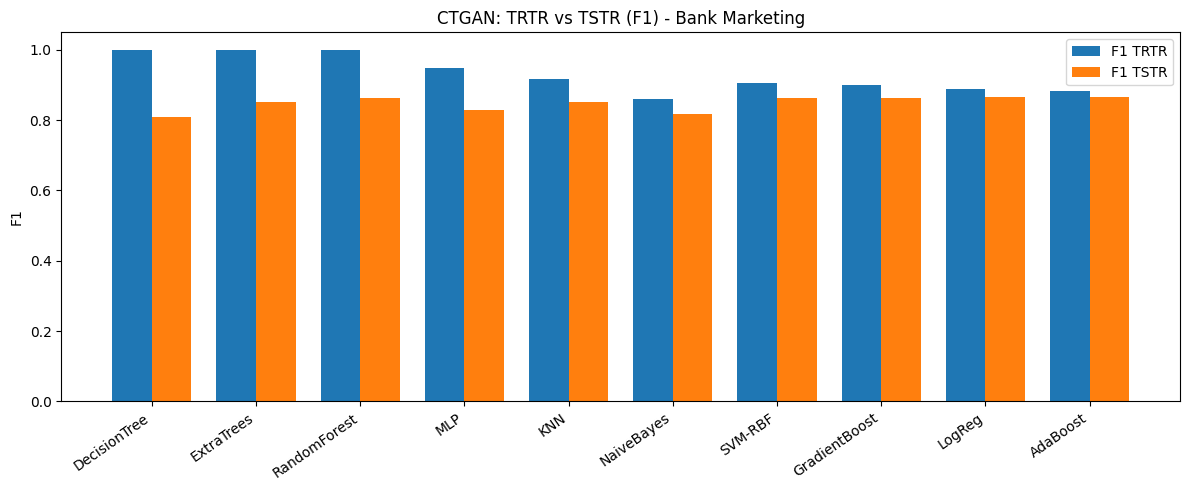

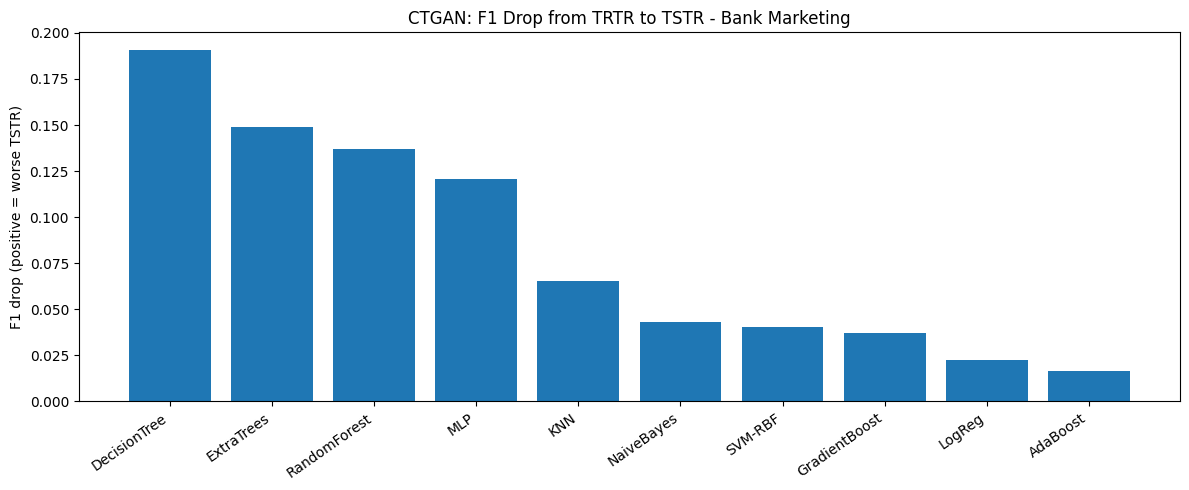


CopulaGAN - TSTR


,Model,Accuracy,Precision,Recall,F1
0,GradientBoost,0.886355,0.874920,0.886355,0.879417
1,LogReg,0.881710,0.875191,0.881710,0.878135
2,SVM-RBF,0.892261,0.872920,0.892261,0.876228
3,AdaBoost,0.879122,0.868441,0.879122,0.872961
4,RandomForest,0.878039,0.867788,0.878039,0.872186
5,KNN,0.852359,0.856360,0.852359,0.854303
6,MLP,0.857114,0.849857,0.857114,0.853284
7,ExtraTrees,0.844993,0.847393,0.844993,0.846176
8,NaiveBayes,0.780739,0.868409,0.780739,0.811847
9,DecisionTree,0.761629,0.843621,0.761629,0.793478


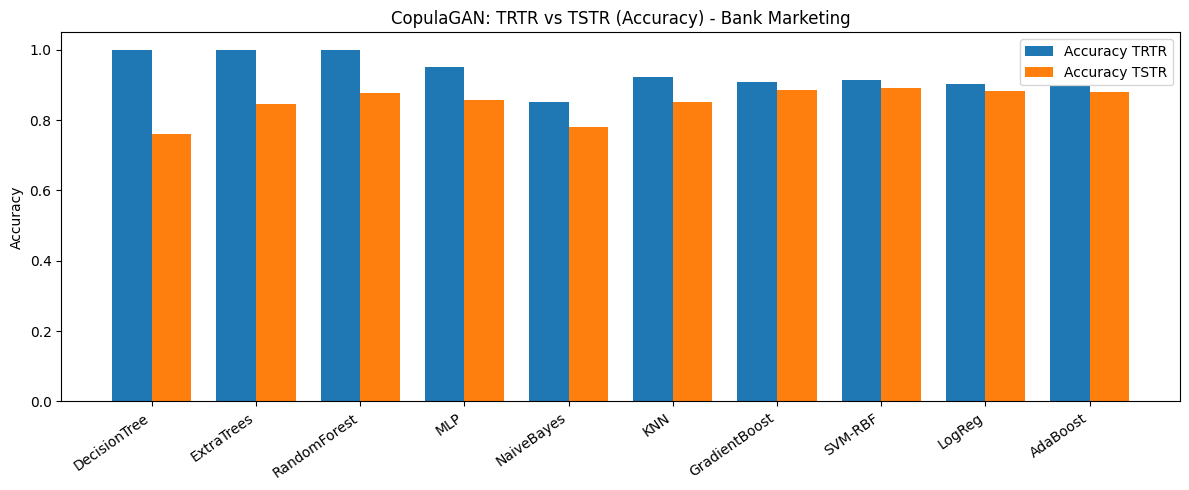

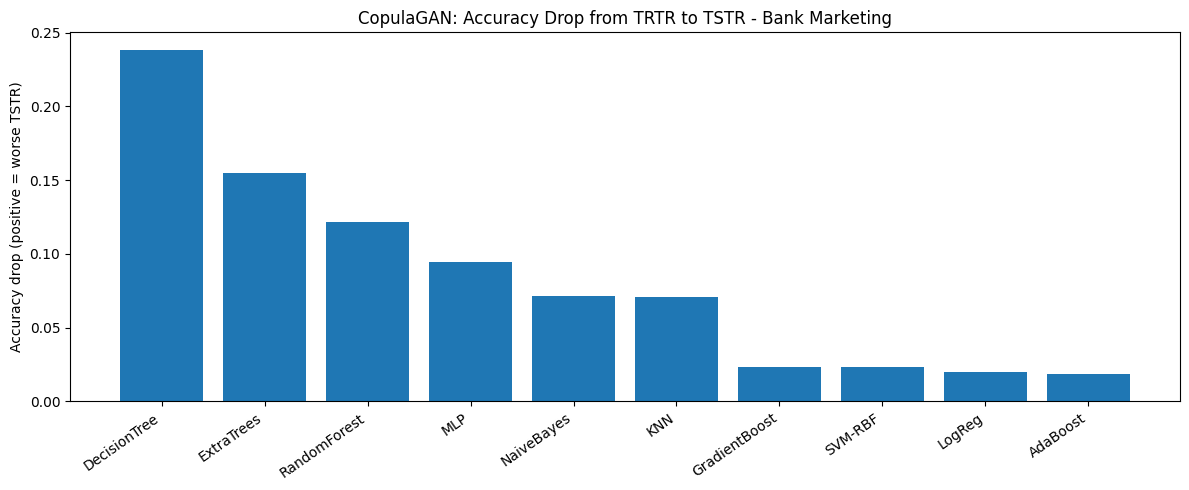

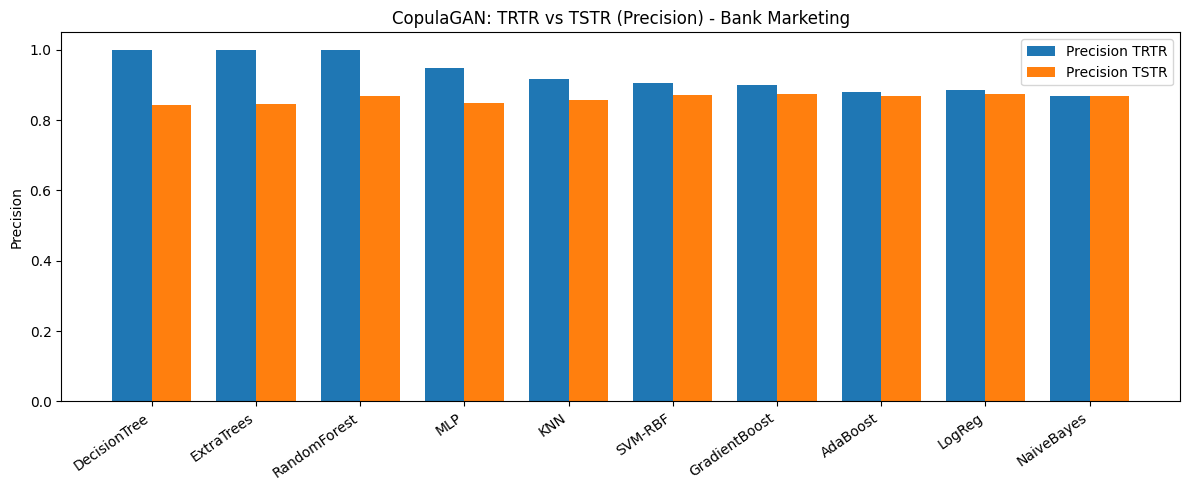

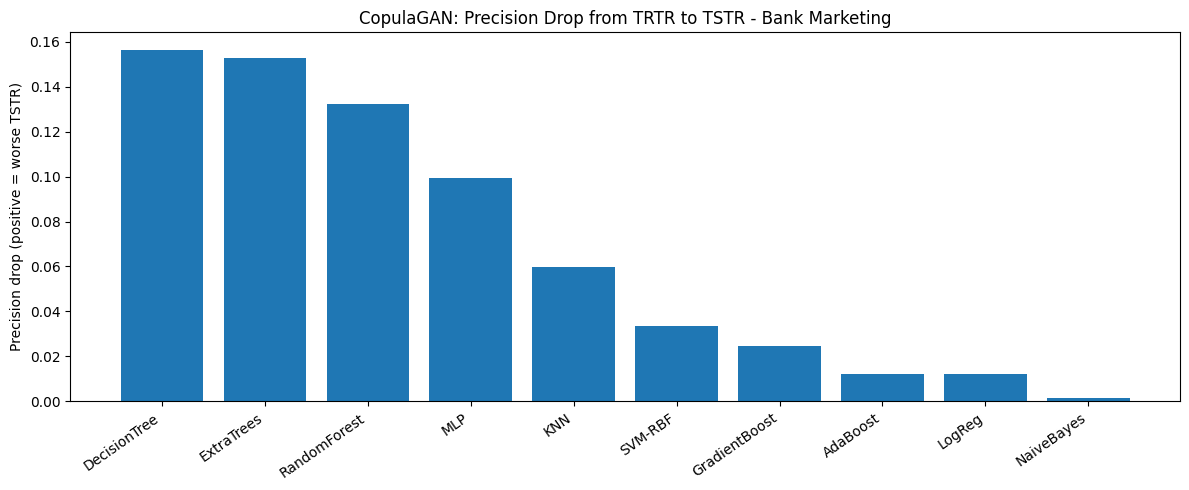

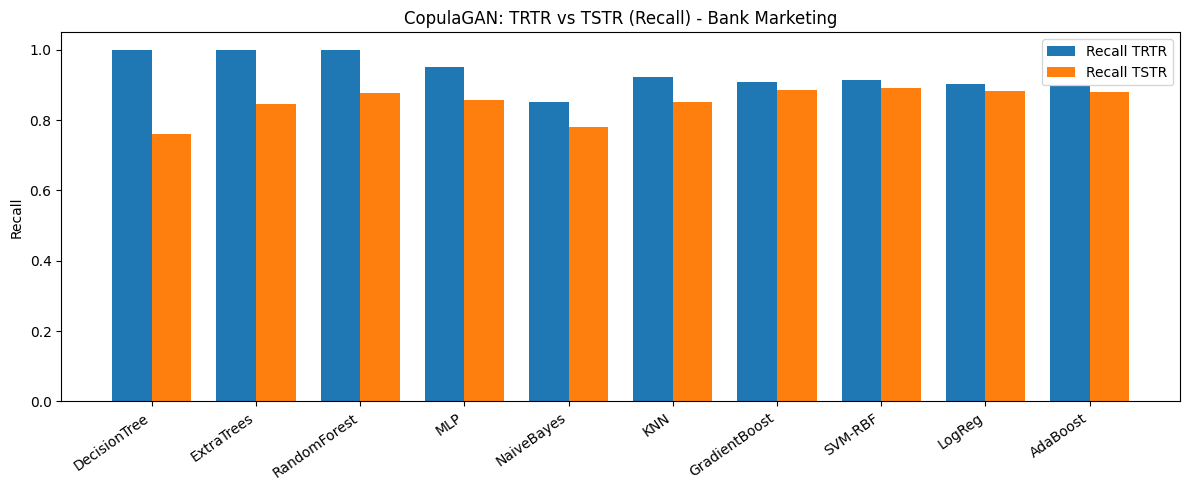

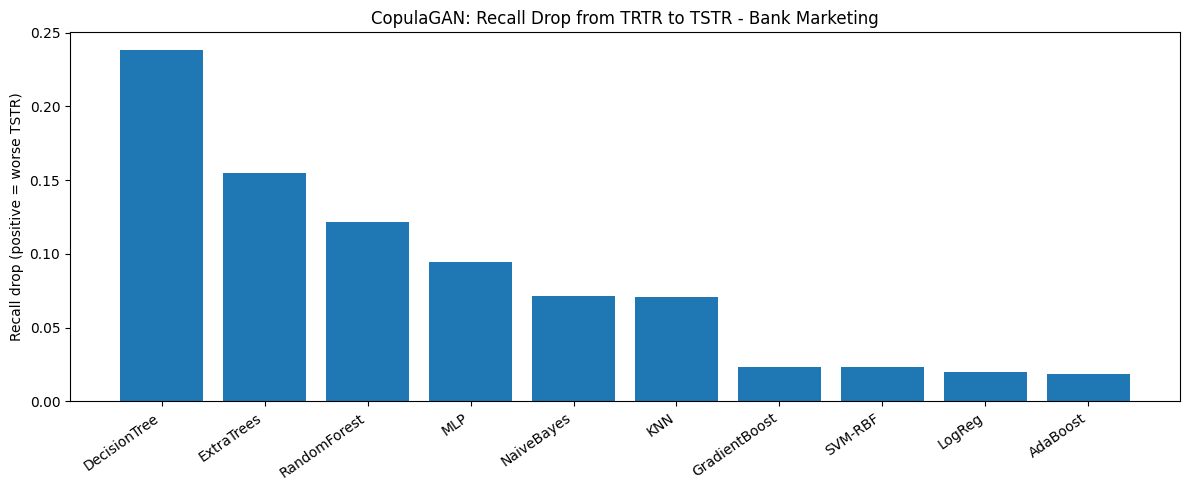

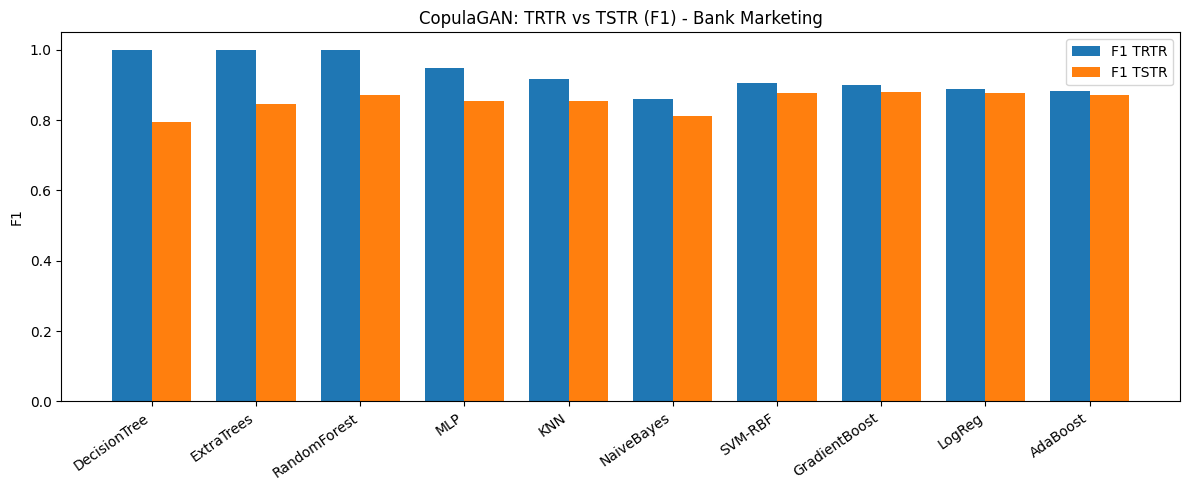

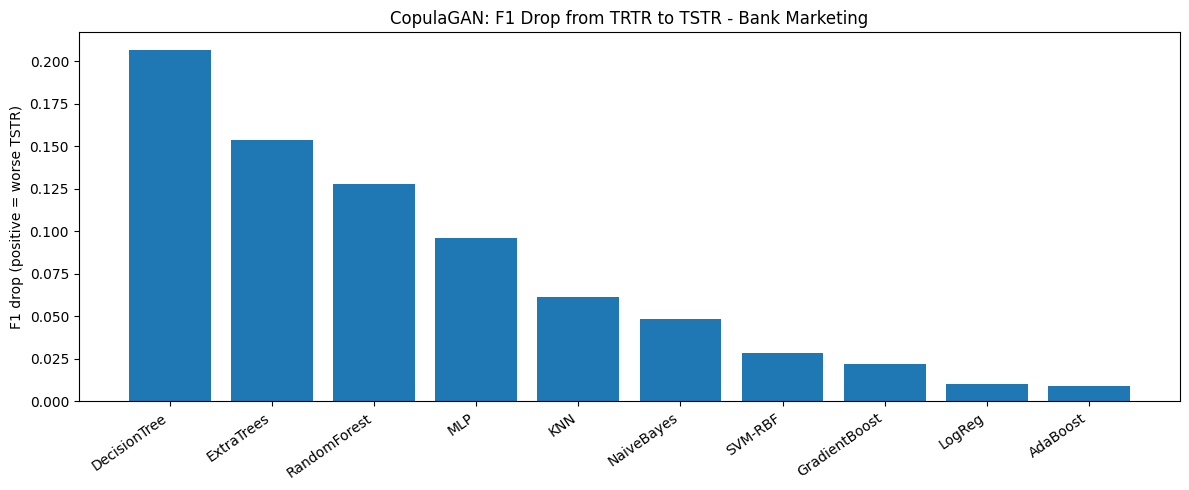


TVAE - TSTR


,Model,Accuracy,Precision,Recall,F1
0,ExtraTrees,0.871049,0.871811,0.871049,0.871427
1,RandomForest,0.853708,0.871443,0.853708,0.861435
2,AdaBoost,0.853133,0.870617,0.853133,0.860777
3,KNN,0.847183,0.879254,0.847183,0.859907
4,SVM-RBF,0.847803,0.872797,0.847803,0.858252
5,LogReg,0.838159,0.893224,0.838159,0.857257
6,MLP,0.834310,0.867408,0.834310,0.847894
7,GradientBoost,0.827918,0.879769,0.827918,0.847087
8,DecisionTree,0.781757,0.866245,0.781757,0.812150
9,NaiveBayes,0.615801,0.855370,0.615801,0.684257


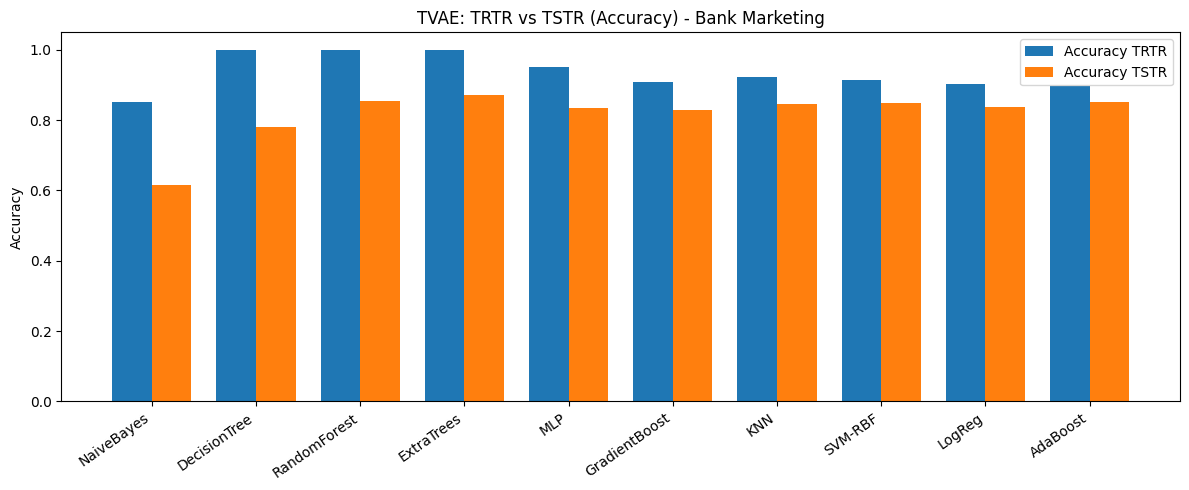

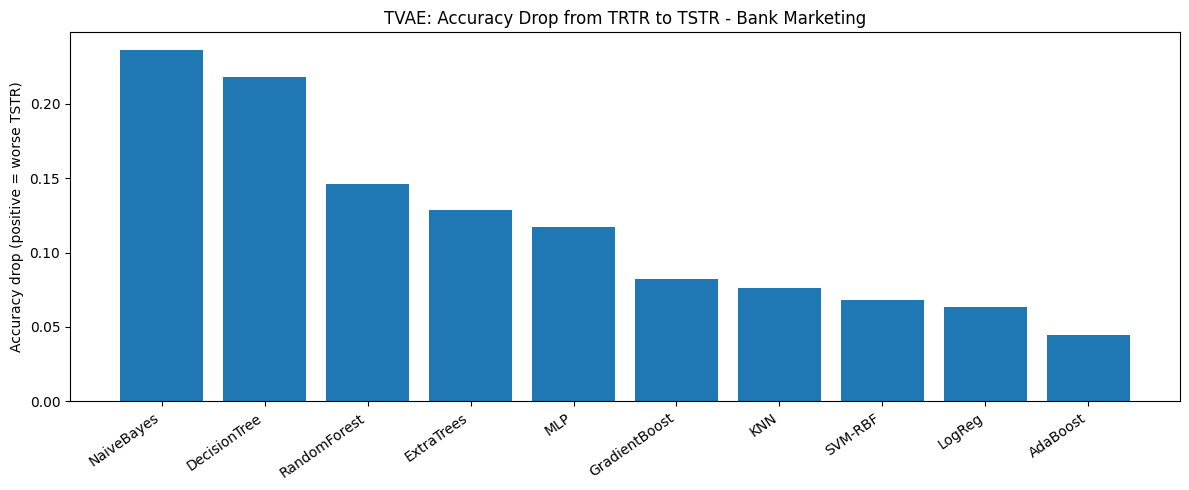

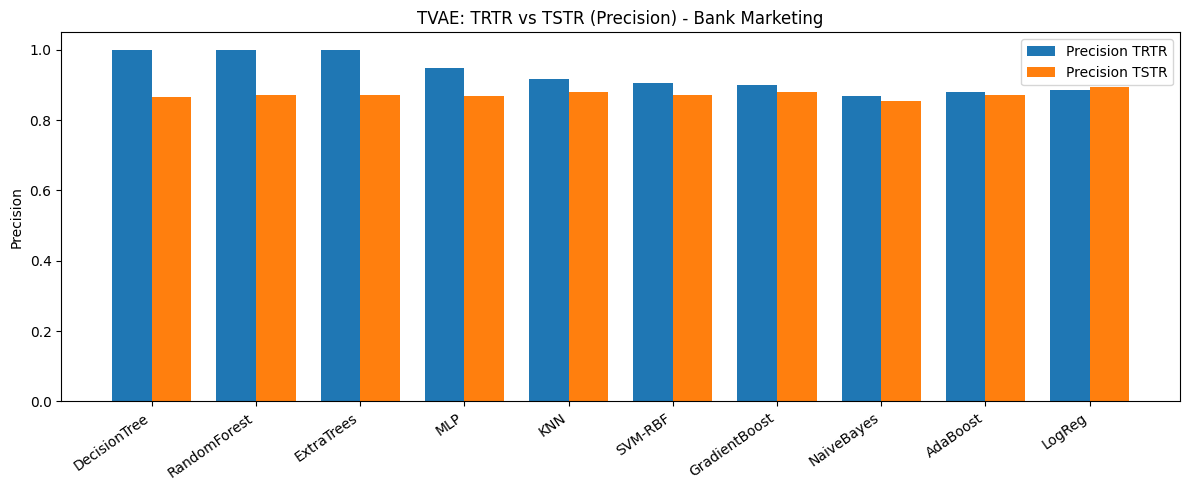

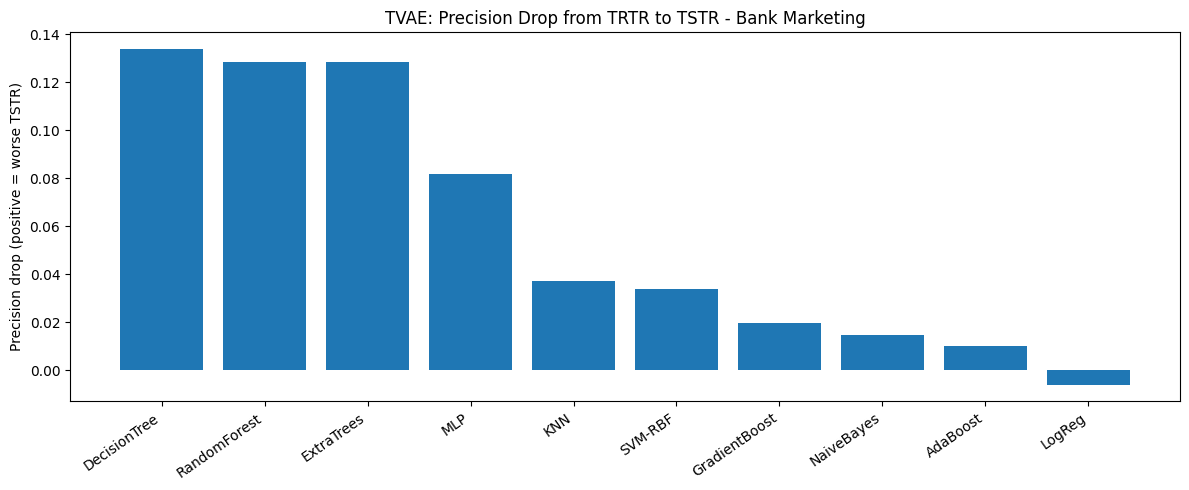

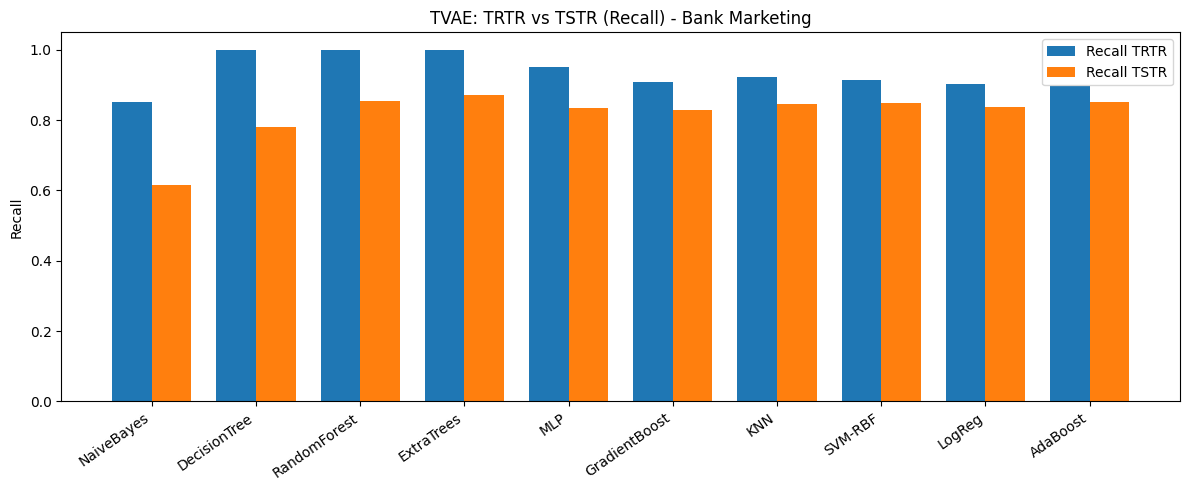

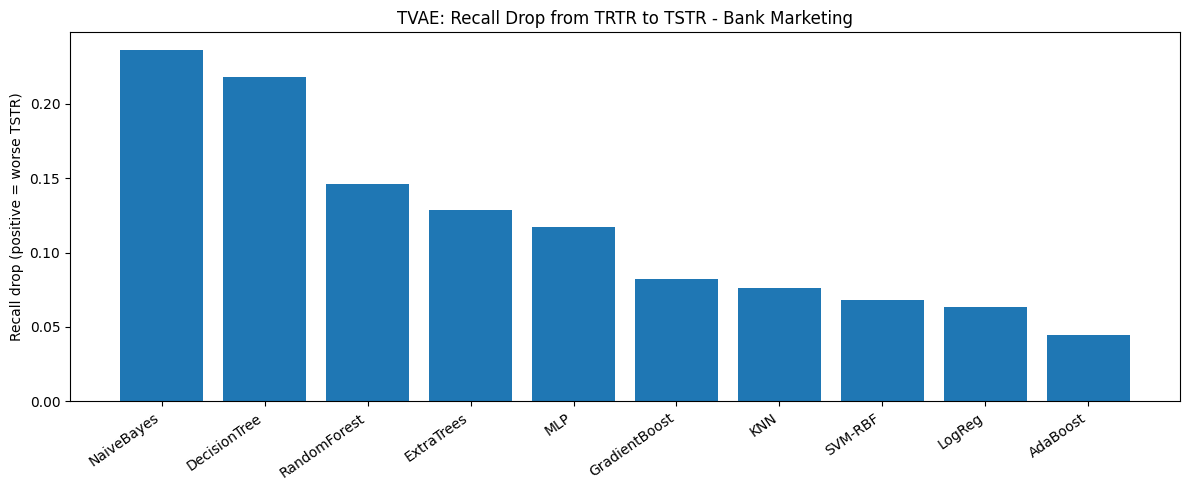

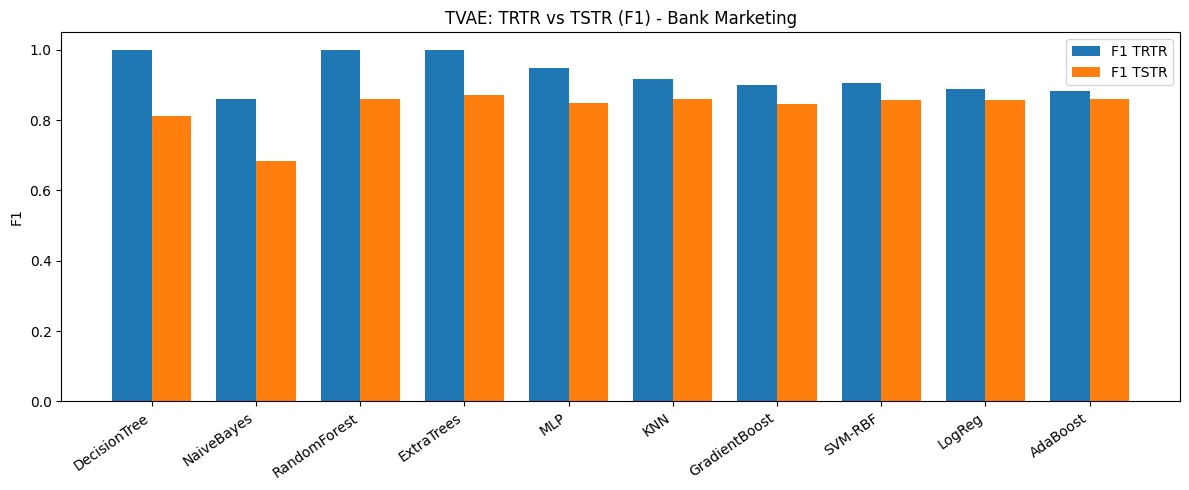

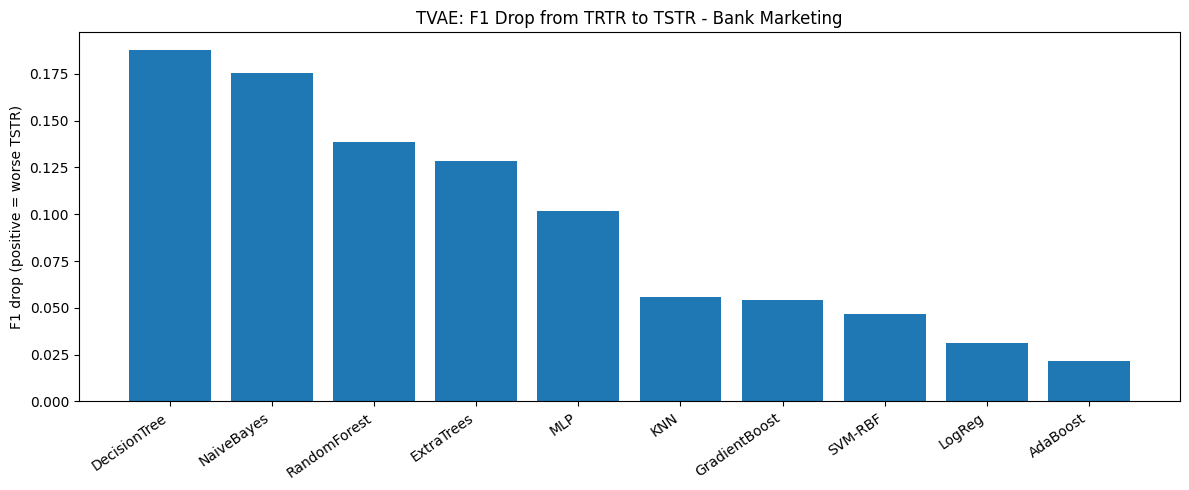


GaussianCopula - TSTR


,Model,Accuracy,Precision,Recall,F1
0,LogReg,0.884387,0.854115,0.884387,0.835691
1,KNN,0.872907,0.810864,0.872907,0.831170
2,GradientBoost,0.882728,0.833046,0.882728,0.830402
3,NaiveBayes,0.813917,0.848583,0.813917,0.828799
4,ExtraTrees,0.879941,0.804920,0.879941,0.828713
5,RandomForest,0.882993,0.826537,0.882993,0.828232
6,SVM-RBF,0.883015,0.779716,0.883015,0.828157
7,AdaBoost,0.883015,0.779716,0.883015,0.828157
8,MLP,0.810422,0.816054,0.810422,0.813192
9,DecisionTree,0.789321,0.812695,0.789321,0.800343


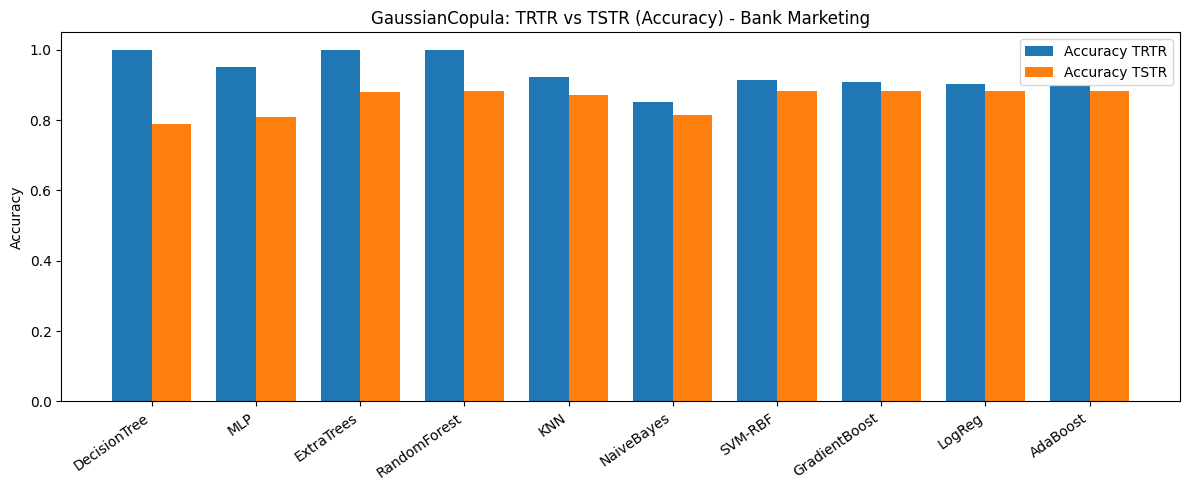

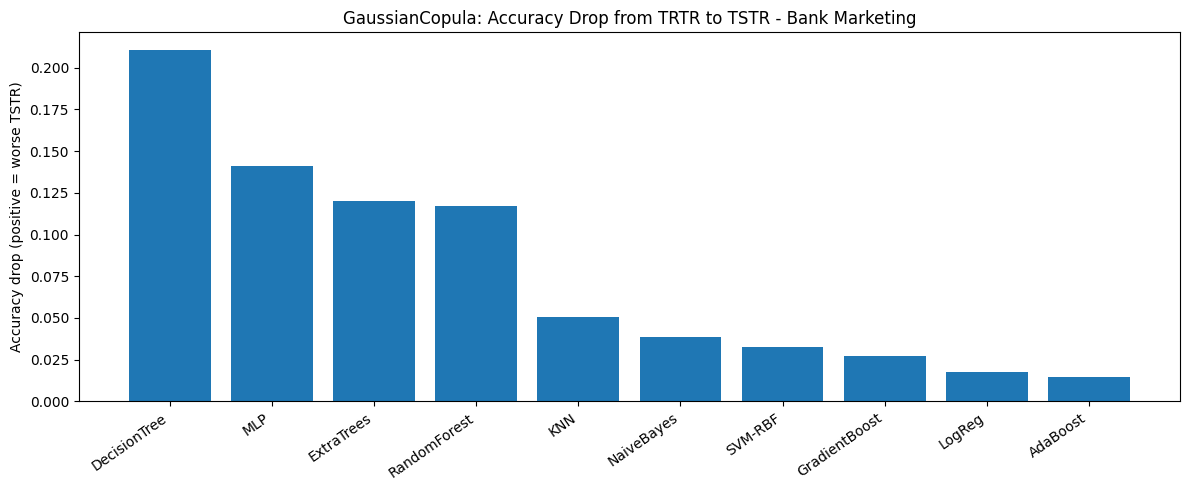

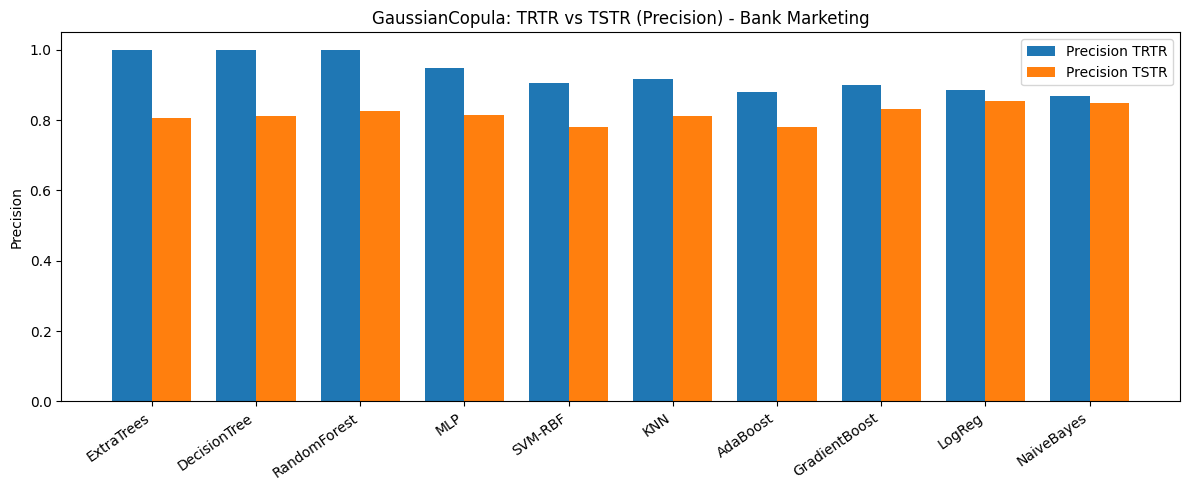

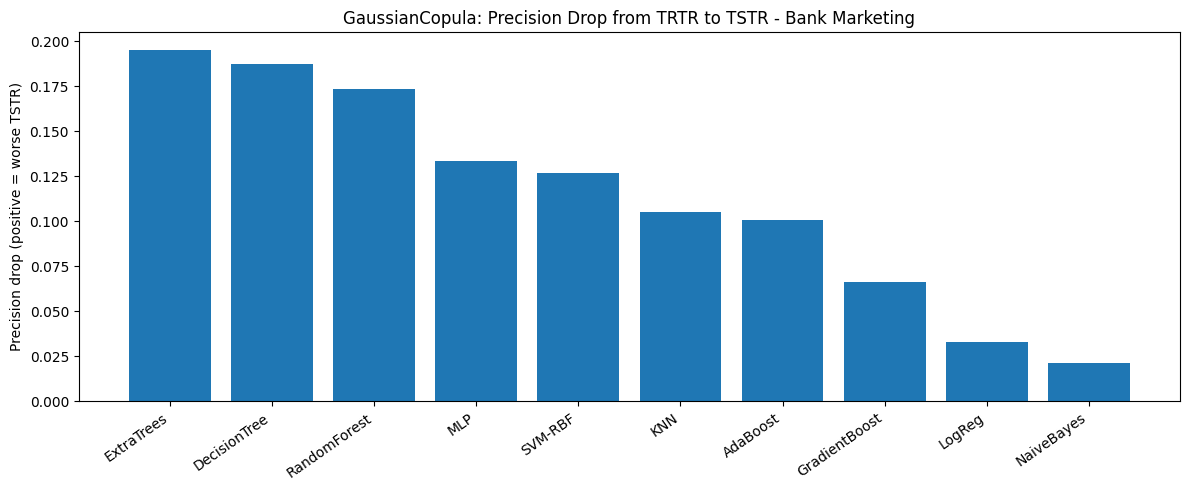

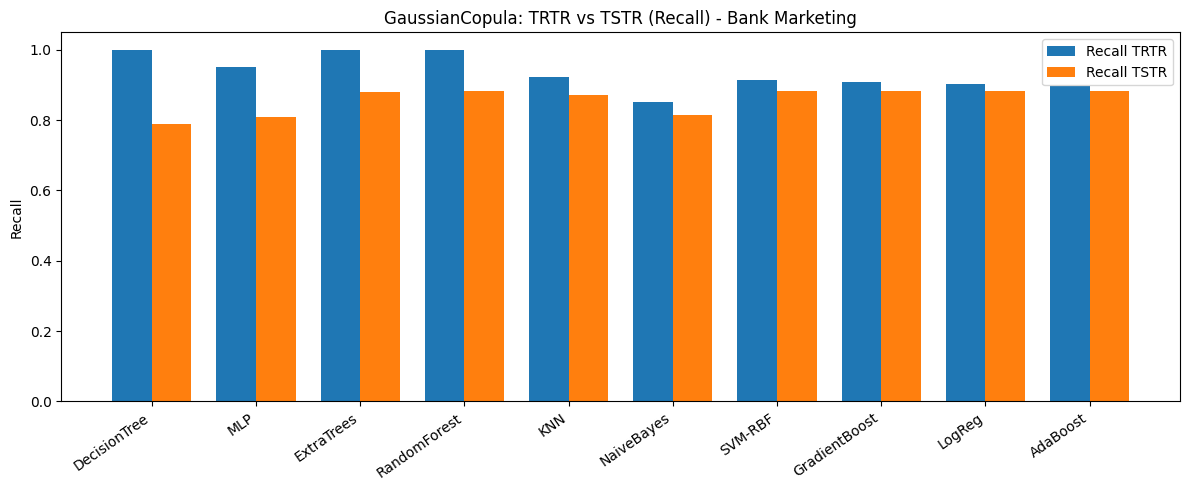

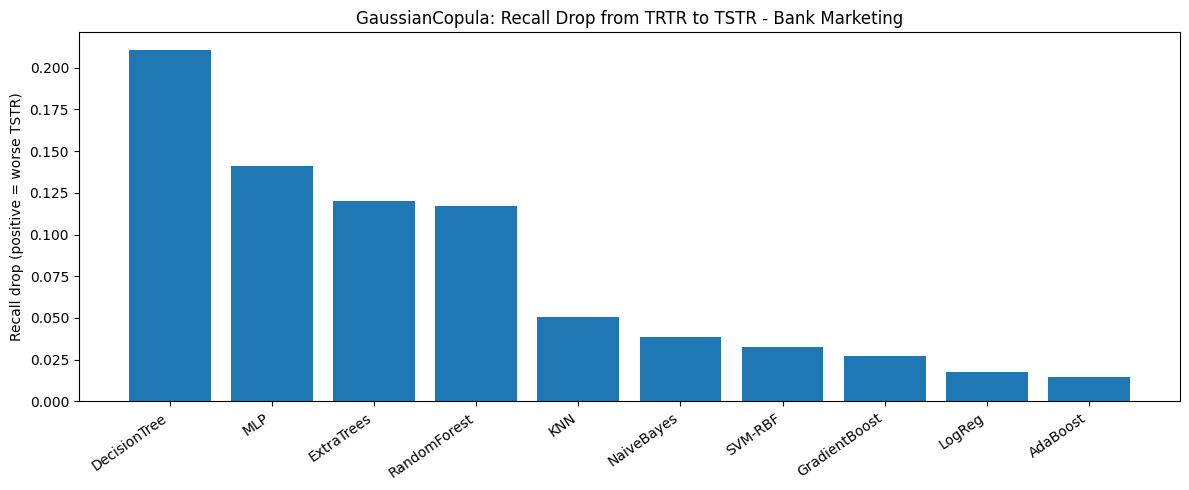

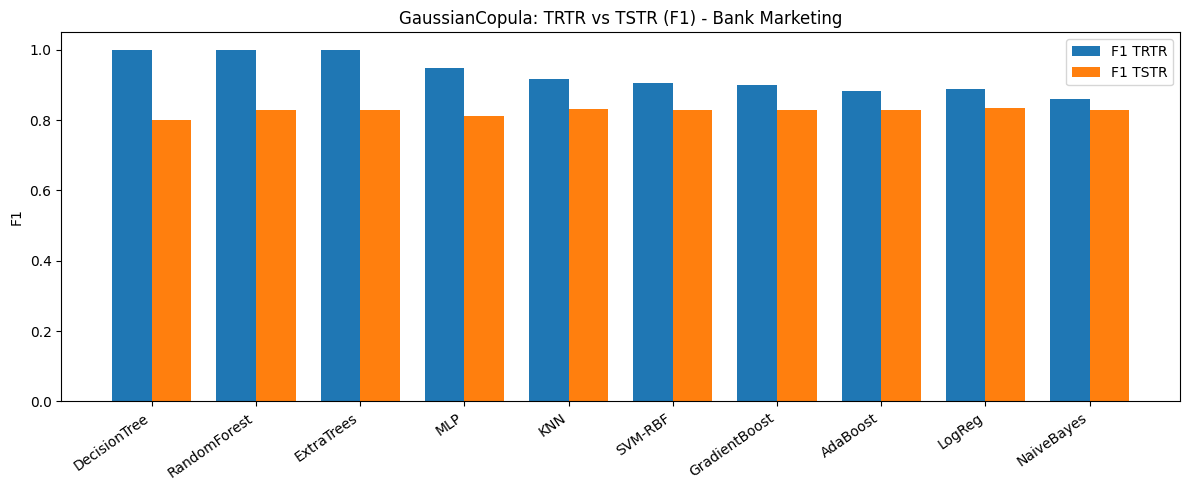

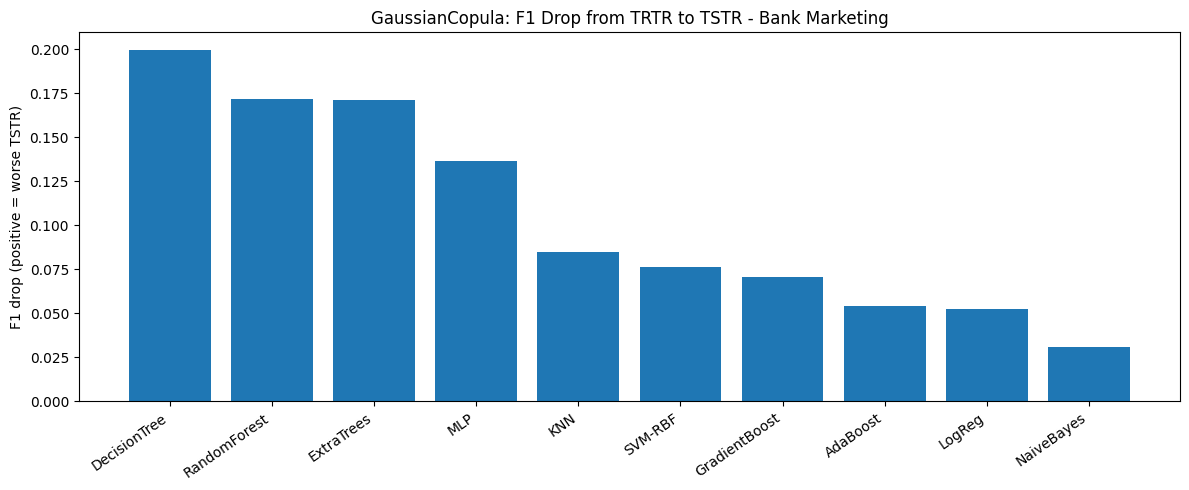


Average Accuracy drop by synthetic generator (positive = worse TSTR):


,Synthetic_Model,Accuracy_Drop
2,GaussianCopula,0.076919
0,CTGAN,0.080611
1,CopulaGAN,0.083752
3,TVAE,0.118102



Average Precision drop by synthetic generator (positive = worse TSTR):


,Synthetic_Model,Precision_Drop
3,TVAE,0.058129
1,CopulaGAN,0.068433
0,CTGAN,0.079915
2,GaussianCopula,0.114298



Average Recall drop by synthetic generator (positive = worse TSTR):


,Synthetic_Model,Recall_Drop
2,GaussianCopula,0.076919
0,CTGAN,0.080611
1,CopulaGAN,0.083752
3,TVAE,0.118102



Average F1 drop by synthetic generator (positive = worse TSTR):


,Synthetic_Model,F1_Drop
1,CopulaGAN,0.076359
0,CTGAN,0.082161
3,TVAE,0.094116
2,GaussianCopula,0.104875


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# -----------------------------
# Helpers
# -----------------------------
HIGHER_IS_BETTER = {"Accuracy", "Precision", "Recall", "F1"}

def compute_drop(trtr_val, tstr_val, metric):
    """Positive drop => TSTR is worse than TRTR."""
    if metric in HIGHER_IS_BETTER:
        return trtr_val - tstr_val
    return tstr_val - trtr_val

def make_ohe_dense():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def evaluate_models(train_df, test_df, label_col, models):
    """
    Classification evaluator for mixed-type tables.
    Handles:
    - numeric + categorical features
    - missing values
    - unknown categories in synthetic data
    """
    train_df = train_df.copy()
    test_df = test_df.copy()

    if label_col not in train_df.columns or label_col not in test_df.columns:
        raise ValueError(f"label_col='{label_col}' must exist in both train_df and test_df")

    X_train = train_df.drop(columns=[label_col]).copy()
    y_train = train_df[label_col].astype(str)

    X_test = test_df.drop(columns=[label_col]).copy()
    y_test = test_df[label_col].astype(str)

    num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X_train.columns if c not in num_cols]

    for c in cat_cols:
        X_train[c] = X_train[c].astype(str)
        X_test[c] = X_test[c].astype(str)

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                num_cols,
            ),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", make_ohe_dense()),
                    ]
                ),
                cat_cols,
            ),
        ],
        remainder="drop",
    )

    rows = []
    for model_name, estimator in models.items():
        pipe = Pipeline(
            steps=[
                ("prep", preprocessor),
                ("model", clone(estimator)),
            ]
        )
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        rows.append(
            {
                "Model": model_name,
                "Accuracy": float(accuracy_score(y_test, y_pred)),
                "Precision": float(precision_score(y_test, y_pred, average="weighted", zero_division=0)),
                "Recall": float(recall_score(y_test, y_pred, average="weighted", zero_division=0)),
                "F1": float(f1_score(y_test, y_pred, average="weighted", zero_division=0)),
            }
        )

    return pd.DataFrame(rows).sort_values("F1", ascending=False).reset_index(drop=True)

def plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric="F1"):
    if metric not in trtr_results.columns or metric not in tstr_results.columns:
        return

    df = trtr_results[["Model", metric]].merge(
        tstr_results[["Model", metric]],
        on="Model",
        suffixes=("_TRTR", "_TSTR")
    )

    df["Drop"] = df.apply(
        lambda r: compute_drop(r[f"{metric}_TRTR"], r[f"{metric}_TSTR"], metric),
        axis=1
    ).astype(float)

    df = df.sort_values("Drop", ascending=False)
    x = np.arange(len(df))
    w = 0.38

    plt.figure(figsize=(12, 5))
    plt.bar(x - w / 2, df[f"{metric}_TRTR"], w, label=f"{metric} TRTR")
    plt.bar(x + w / 2, df[f"{metric}_TSTR"], w, label=f"{metric} TSTR")
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel(metric)
    plt.title(f"{synth_name}: TRTR vs TSTR ({metric}) - Bank Marketing")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_metric_drop(comparison_df, synth_name, metric):
    drop_col = f"{metric}_Drop"
    if drop_col not in comparison_df.columns:
        return

    df = comparison_df.sort_values(drop_col, ascending=False)
    x = np.arange(len(df))

    plt.figure(figsize=(12, 5))
    plt.bar(x, df[drop_col])
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel(f"{metric} drop (positive = worse TSTR)")
    plt.title(f"{synth_name}: {metric} Drop from TRTR to TSTR - Bank Marketing")
    plt.tight_layout()
    plt.show()

# -----------------------------
# Main
# -----------------------------
label_col = "y"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

trtr_results = evaluate_models(
    train_df=data,
    test_df=data,
    label="y",
    models=models
)

metrics_to_use = ["Accuracy", "Precision", "Recall", "F1"]

all_comp = []

for synth_name in model_order:
    synth_train = synthetic_datasets[synth_name].reindex(columns=data.columns).copy()

    tstr_results = evaluate_models(
        train_df=synth_train,
        test_df=data,
        label="y",
        models=models
    )

    comparison = trtr_results.merge(
        tstr_results,
        on="Model",
        suffixes=("_TRTR", "_TSTR")
    )
    comparison["Synthetic_Model"] = synth_name

    for metric in metrics_to_use:
        comparison[f"{metric}_Drop"] = comparison.apply(
            lambda r: compute_drop(r[f"{metric}_TRTR"], r[f"{metric}_TSTR"], metric),
            axis=1
        )

    all_comp.append(comparison)

    print(f"\n{synth_name} - TSTR")
    display(tstr_results)

    for metric in metrics_to_use:
        plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric=metric)
        plot_metric_drop(comparison, synth_name, metric)

combined_comparison = pd.concat(all_comp, ignore_index=True)

for metric in metrics_to_use:
    summary = (
        combined_comparison
        .groupby("Synthetic_Model", as_index=False)[f"{metric}_Drop"]
        .mean()
        .sort_values(f"{metric}_Drop")
    )
    print(f"\nAverage {metric} drop by synthetic generator (positive = worse TSTR):")
    display(summary)


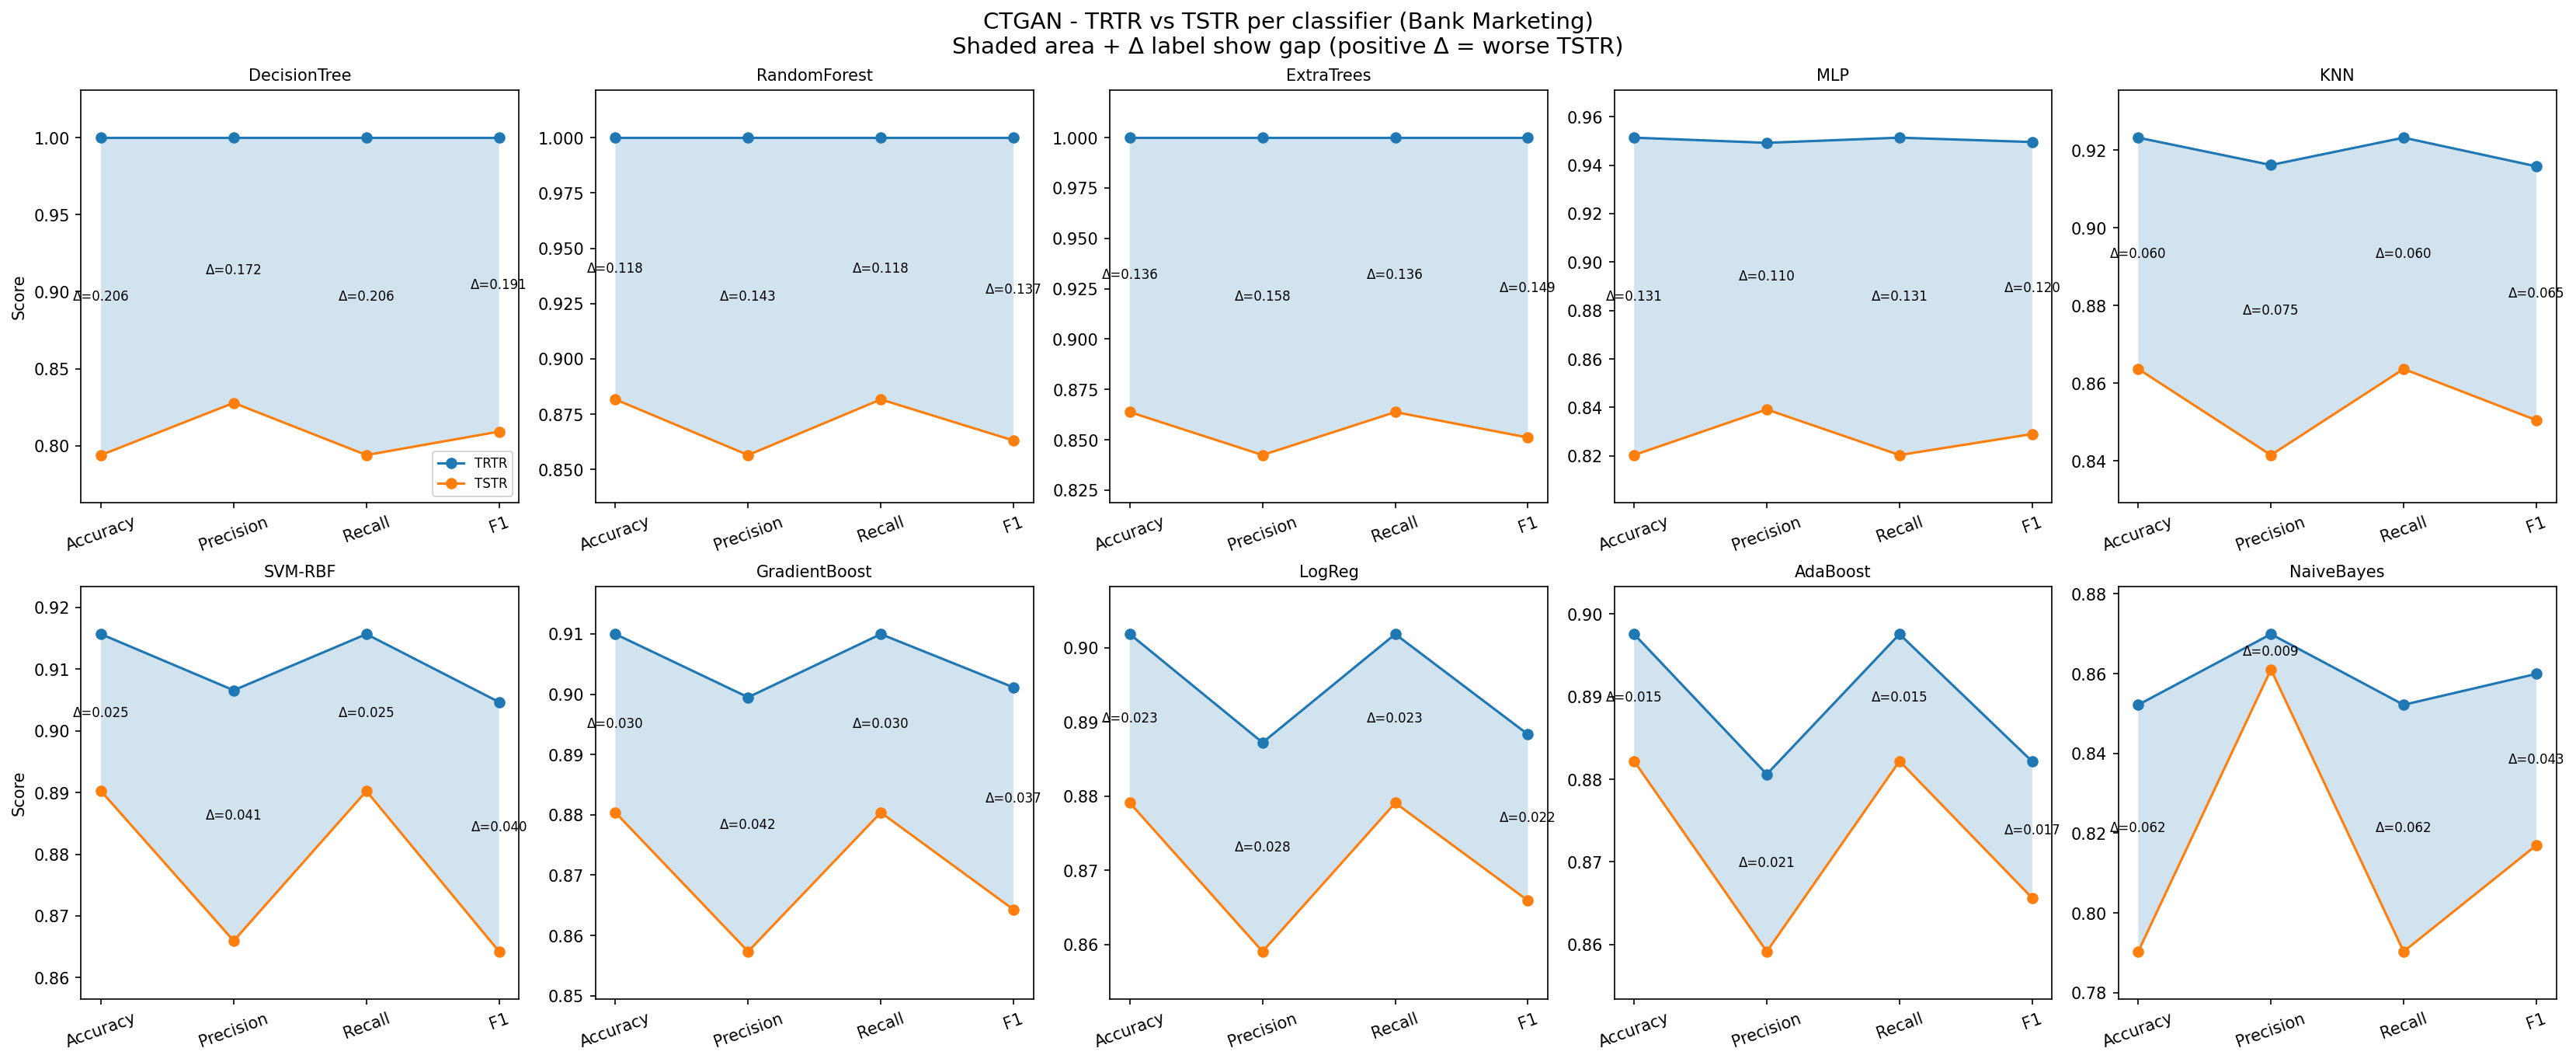

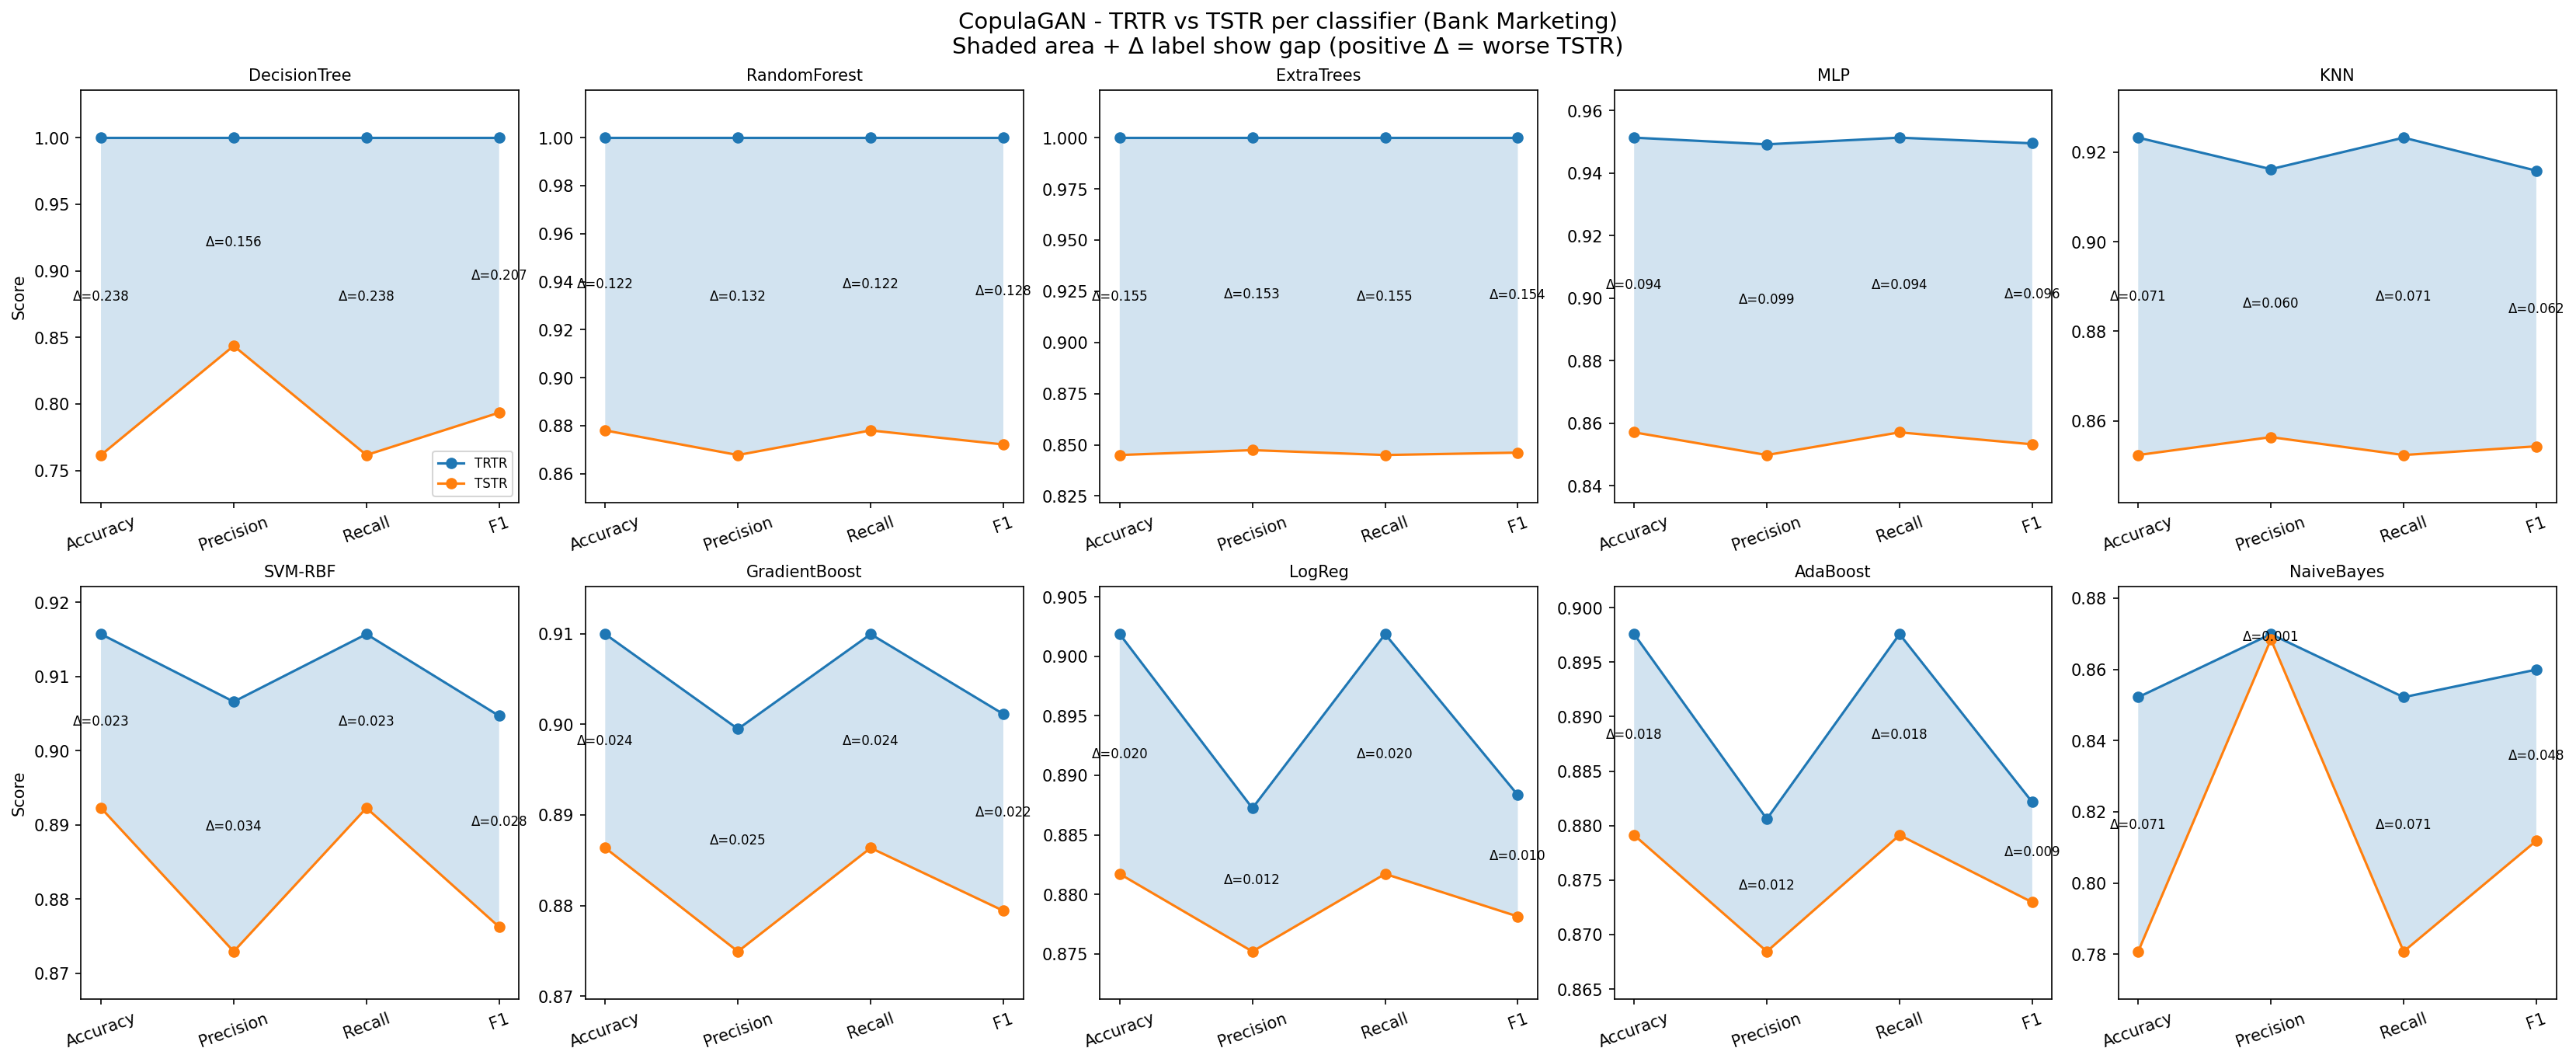

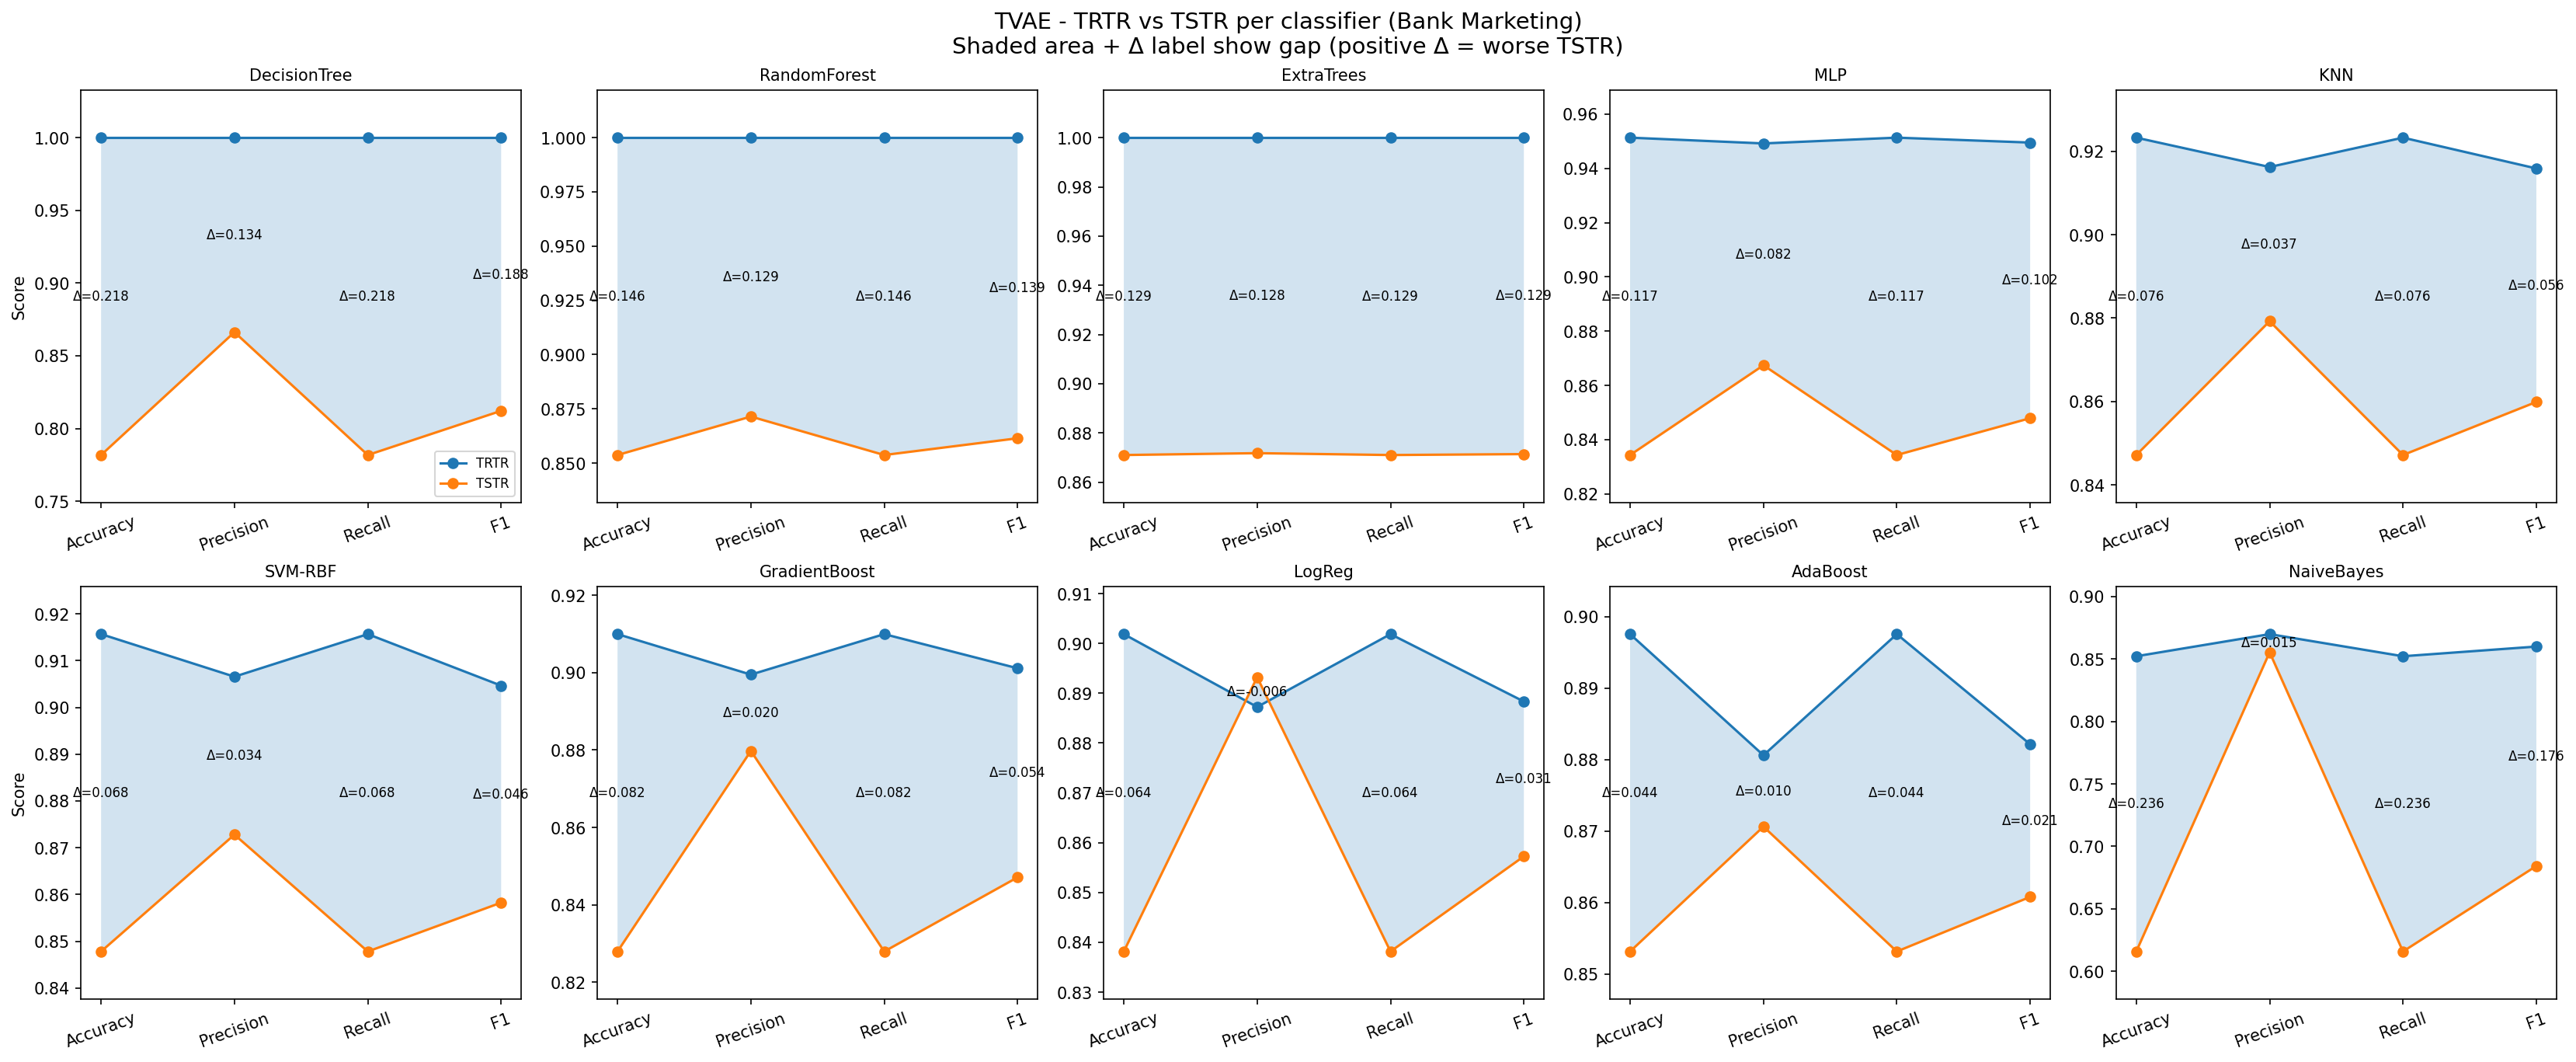

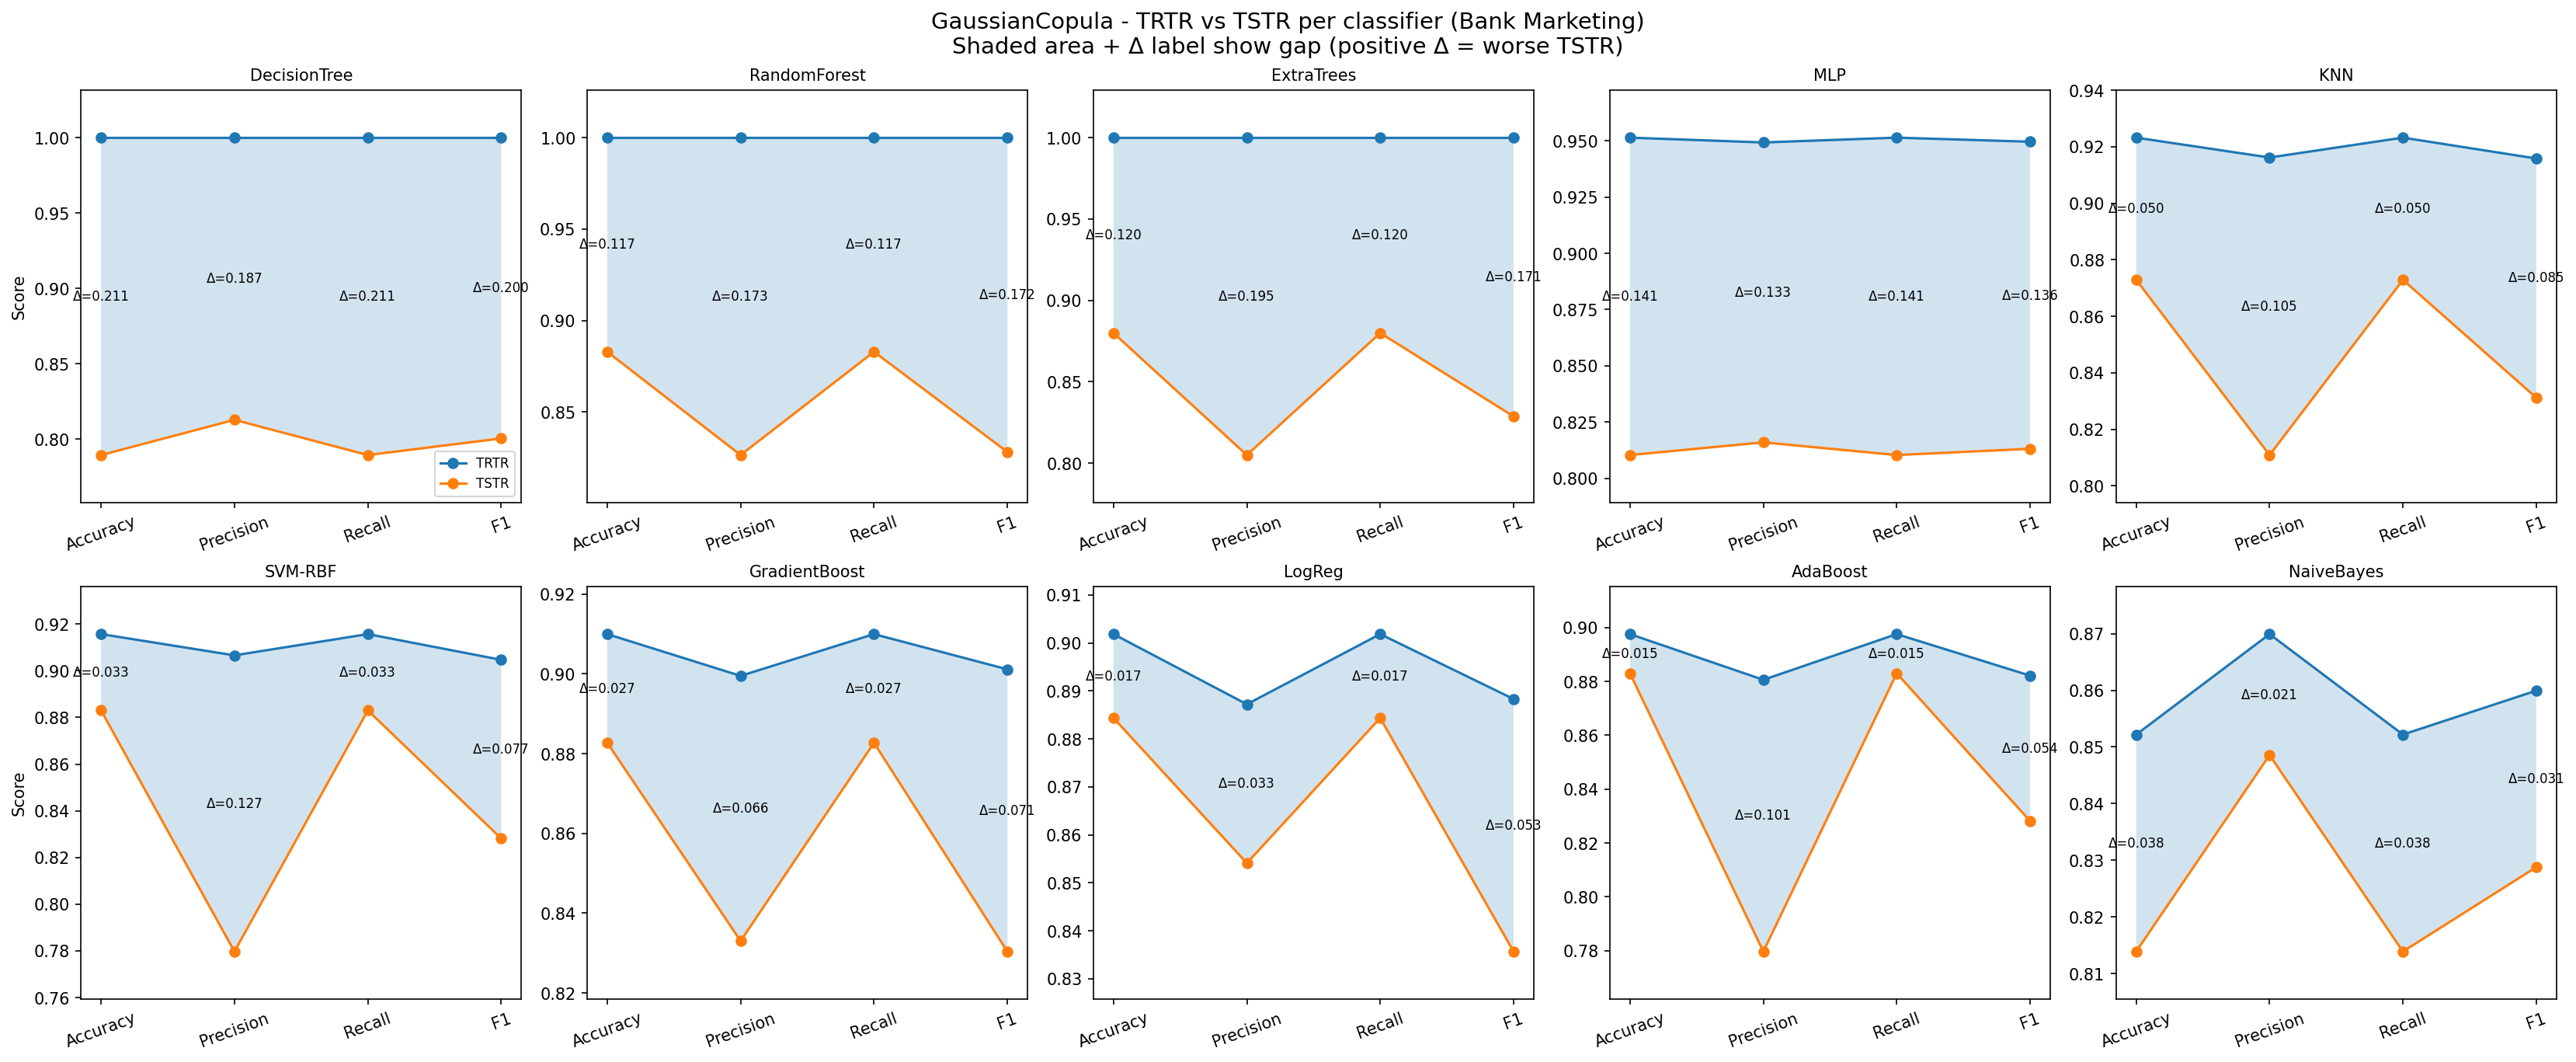

In [25]:
import numpy as np
import matplotlib.pyplot as plt

HIGHER_IS_BETTER = {"Accuracy", "Precision", "Recall", "F1"}

def compute_drop(trtr_value, tstr_value, metric):
    """
    Positive drop means TSTR is worse than TRTR.
    For classification metrics, higher is better:
    drop = TRTR - TSTR
    """
    if metric in HIGHER_IS_BETTER:
        return trtr_value - tstr_value
    return tstr_value - trtr_value

def plot_grid_line_metrics_with_gap(
    trtr_results,
    tstr_results,
    generator_name,
    ncols=5
):
    preferred_metrics = ["Accuracy", "Precision", "Recall", "F1"]
    metrics = [m for m in preferred_metrics if m in trtr_results.columns and m in tstr_results.columns]

    if not metrics:
        print(f"No common classification metrics found for {generator_name}.")
        return

    x = np.arange(len(metrics))

    trtr = trtr_results.set_index("Model")[metrics]
    tstr = tstr_results.set_index("Model")[metrics]
    models_local = [m for m in trtr.index if m in tstr.index]

    n = len(models_local)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(22, 9),
        dpi=150,
        constrained_layout=True
    )
    axes = np.array(axes).reshape(-1)

    for i, model_name in enumerate(models_local):
        ax = axes[i]
        a = trtr.loc[model_name].values.astype(float)
        b = tstr.loc[model_name].values.astype(float)
        d = np.array([compute_drop(ai, bi, metric) for ai, bi, metric in zip(a, b, metrics)])

        ax.plot(x, a, marker="o", label="TRTR")
        ax.plot(x, b, marker="o", label="TSTR")
        ax.fill_between(x, b, a, alpha=0.2)

        for xi, ai, bi, di in zip(x, a, b, d):
            ax.text(xi, (ai + bi) / 2, f"Δ={di:.3f}", ha="center", va="center", fontsize=8)

        ax.set_title(model_name, fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(metrics, rotation=20)

        y_min = min(np.nanmin(a), np.nanmin(b))
        y_max = max(np.nanmax(a), np.nanmax(b))
        if np.isfinite(y_min) and np.isfinite(y_max):
            pad = (y_max - y_min) * 0.15 if y_max > y_min else 0.05
            ax.set_ylim(max(0, y_min - pad), min(1.05, y_max + pad))

        if i % ncols == 0:
            ax.set_ylabel("Score")
        if i == 0:
            ax.legend(fontsize=8, loc="best")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        f"{generator_name} - TRTR vs TSTR per classifier (Bank Marketing)\n"
        f"Shaded area + Δ label show gap (positive Δ = worse TSTR)",
        fontsize=14
    )
    plt.show()

label_col = "y"
generators = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

trtr_results = evaluate_models(
    train_df=data,
    test_df=data,
    label="y",
    models=models
)

for gen in generators:
    tstr_results = evaluate_models(
        train_df=synthetic_datasets[gen].reindex(columns=data.columns),
        test_df=data,
        label="y",
        models=models
    )
    plot_grid_line_metrics_with_gap(
        trtr_results,
        tstr_results,
        generator_name=gen,
        ncols=5
    )


# 5 Statistical similarity tests 

Average feature-distribution error by model (Bank Marketing Dataset)


,Model,Mean Error %,Median Error %,Std Error %
0,CTGAN,15.683888,14.181028,11.198530
1,CopulaGAN,27.112464,12.072722,20.994955
2,TVAE,25.553935,16.731813,33.337731
3,GaussianCopula,59.045216,6.314740,15.253082


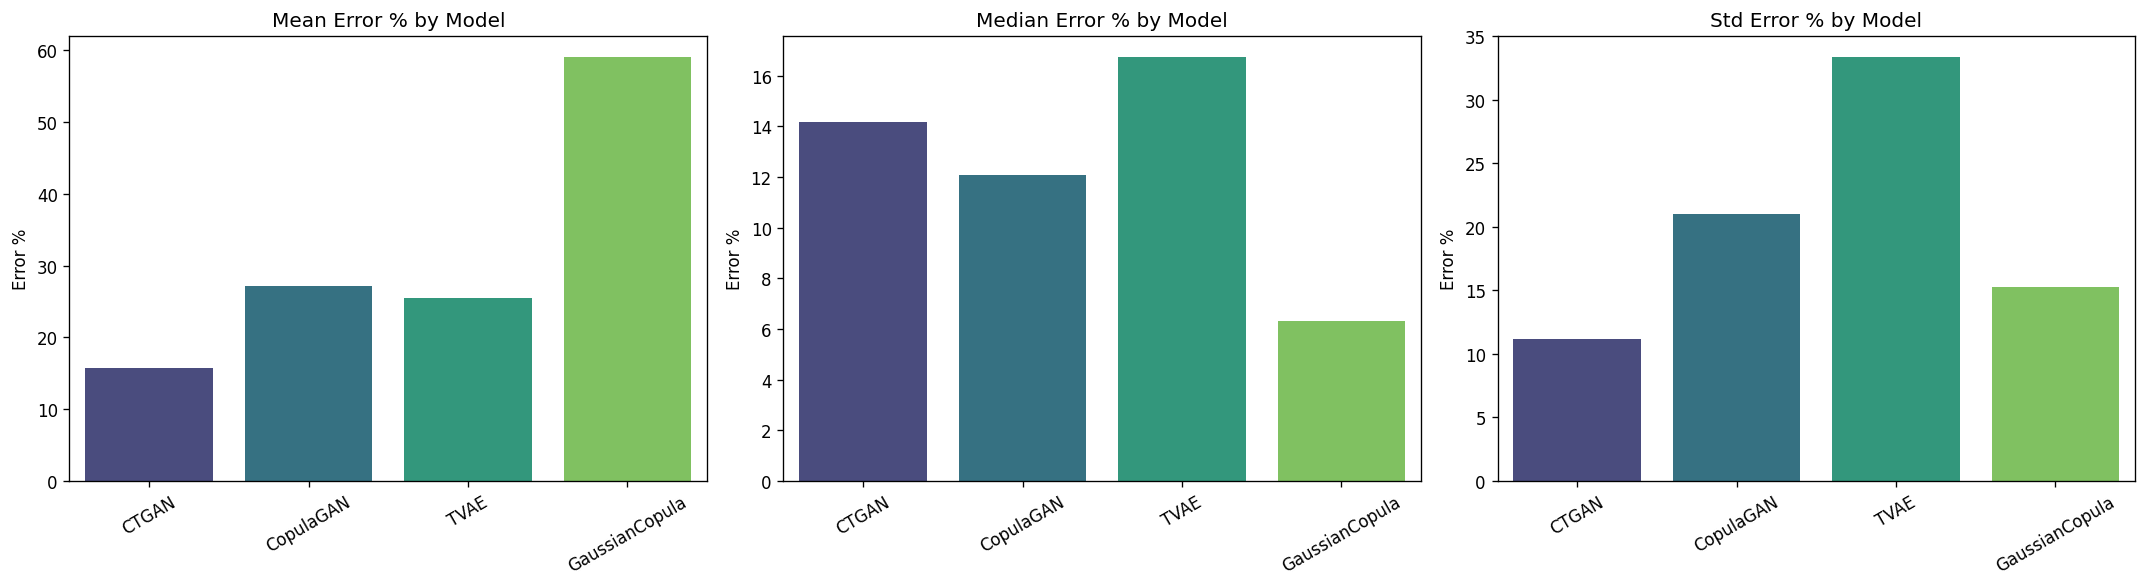

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "y"

real_df = data.copy()

# Numeric feature columns only
exclude_cols = {target_col}
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in exclude_cols]

summary_rows = []
feature_error_by_model = {}

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_df = synth_df.reindex(columns=real_df.columns)

    real_num = real_df[num_cols].apply(pd.to_numeric, errors="coerce").astype(np.float64)
    synth_num = synth_df[num_cols].apply(pd.to_numeric, errors="coerce").astype(np.float64)

    real_means = real_num.mean()
    synth_means = synth_num.mean()

    real_stds = real_num.std(ddof=1)
    synth_stds = synth_num.std(ddof=1)

    mean_error_pct = (np.abs(synth_means - real_means) / real_means.replace(0, np.nan).abs()) * 100
    std_error_pct = (np.abs(synth_stds - real_stds) / real_stds.replace(0, np.nan).abs()) * 100

    feature_error_df = pd.DataFrame({
        "Feature": num_cols,
        "Mean_Error_%": mean_error_pct.values,
        "Std_Error_%": std_error_pct.values
    }).replace([np.inf, -np.inf], np.nan)

    model_summary = {
        "Model": model_name,
        "Mean Error %": float(feature_error_df["Mean_Error_%"].mean(skipna=True)),
        "Median Error %": float(feature_error_df["Mean_Error_%"].median(skipna=True)),
        "Std Error %": float(feature_error_df["Std_Error_%"].mean(skipna=True))
    }

    summary_rows.append(model_summary)
    feature_error_by_model[model_name] = feature_error_df

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index("Model").loc[model_order].reset_index()

print("Average feature-distribution error by model (Bank Marketing Dataset)")
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
axes[0].set_title("Mean Error % by Model")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
axes[1].set_title("Median Error % by Model")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Std Error %", ax=axes[2], palette="viridis")
axes[2].set_title("Std Error % by Model")
axes[2].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Error %")

plt.tight_layout()
plt.show()


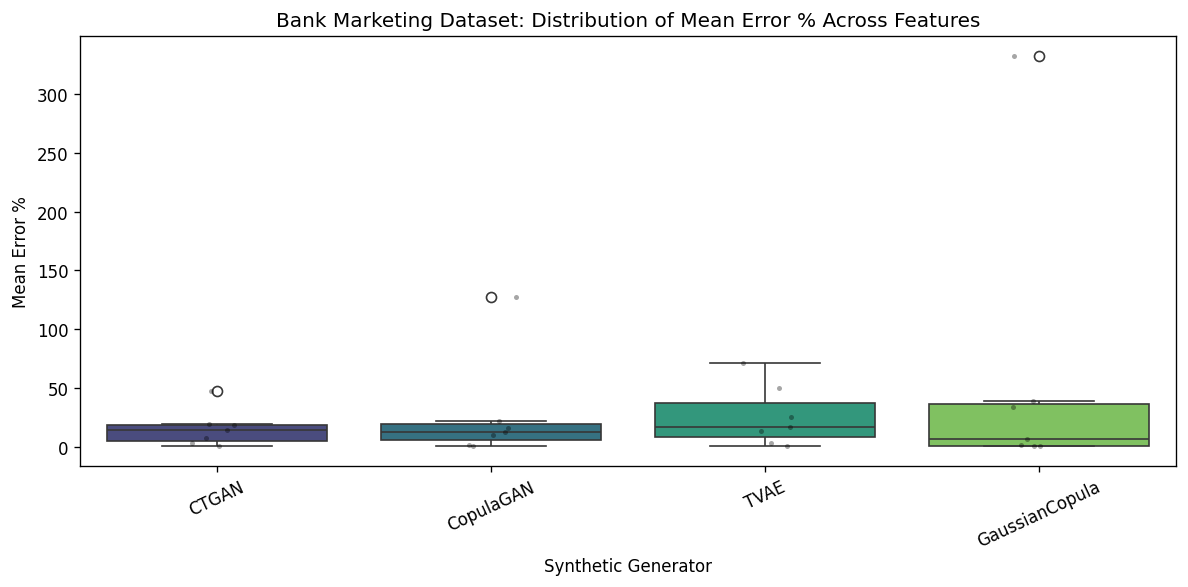

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

dist_df = pd.concat(
    [
        feature_error_by_model[m][["Feature", "Mean_Error_%"]].assign(Model=m)
        for m in model_order
        if m in feature_error_by_model
    ],
    ignore_index=True
).replace([float("inf"), float("-inf")], pd.NA).dropna(subset=["Mean_Error_%"])

plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=dist_df, x="Model", y="Mean_Error_%", order=model_order, palette="viridis")
sns.stripplot(
    data=dist_df,
    x="Model",
    y="Mean_Error_%",
    order=model_order,
    color="black",
    alpha=0.35,
    size=3
)

plt.title("Bank Marketing Dataset: Distribution of Mean Error % Across Features")
plt.xlabel("Synthetic Generator")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

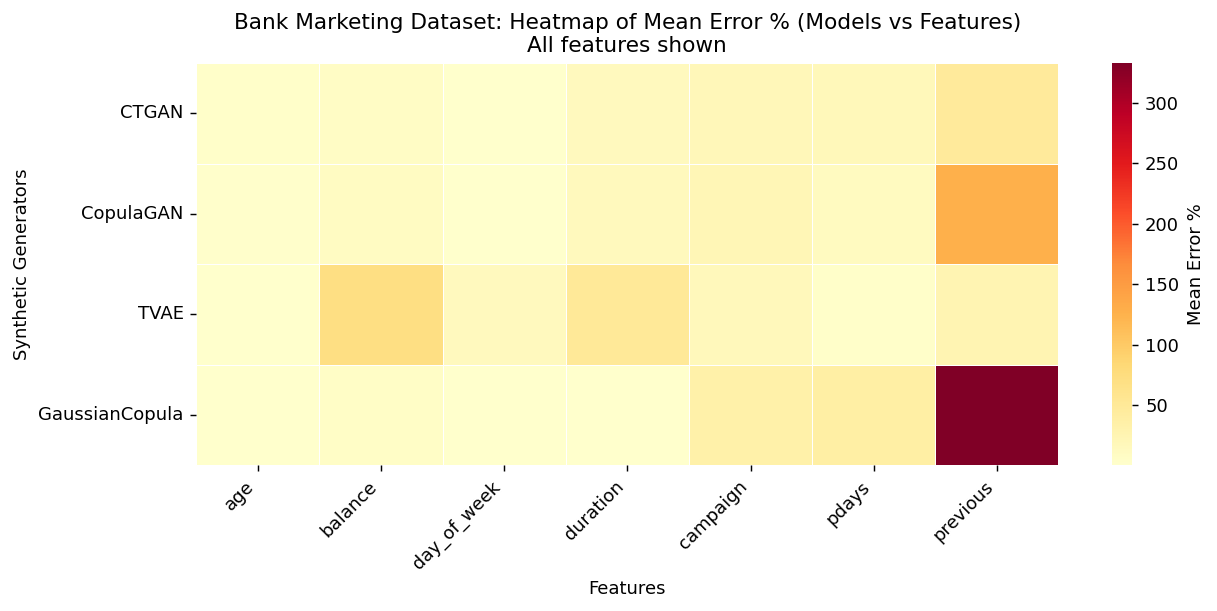

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
    if m in feature_error_by_model
}).T

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

max_features = 20
if heatmap_df.shape[1] > max_features:
    top_features = (
        heatmap_df.mean(axis=0, skipna=True)
        .sort_values(ascending=False)
        .head(max_features)
        .index
    )
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"

def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 1] + "..."

display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)
sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"}
)

plt.title(f"Bank Marketing Dataset: Heatmap of Mean Error % (Models vs Features)\n{truncated_note}")
plt.xlabel("Features")
plt.ylabel("Synthetic Generators")
plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

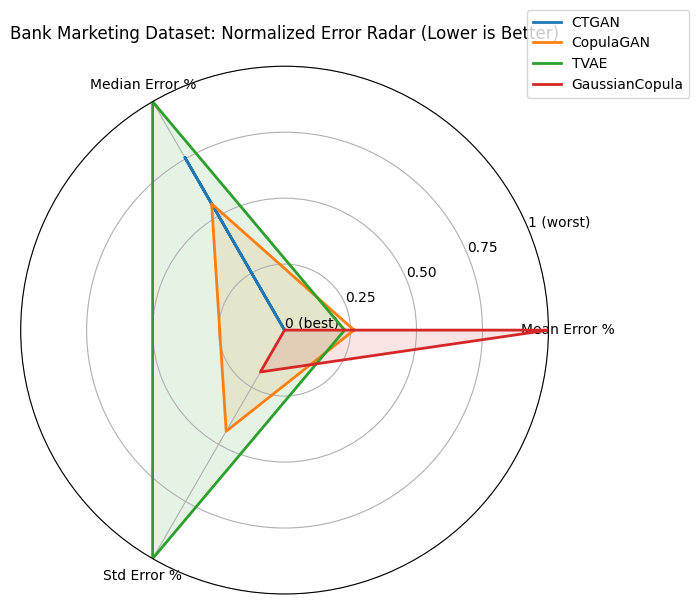

,Model,Mean Error %,Median Error %,Std Error %
0,CTGAN,0.000000,0.755134,0.000000
1,CopulaGAN,0.263566,0.552745,0.442492
2,TVAE,0.227623,1.000000,1.000000
3,GaussianCopula,1.000000,0.000000,0.183139


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

metrics = ["Mean Error %", "Median Error %", "Std Error %"]
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

radar_df = summary_df[["Model"] + metrics].copy()
radar_df = radar_df.set_index("Model").reindex(model_order).dropna(how="all").reset_index()

norm_df = radar_df.copy()
for m in metrics:
    mn, mx = norm_df[m].min(), norm_df[m].max()
    if mx > mn:
        norm_df[m] = (norm_df[m] - mn) / (mx - mn)
    else:
        norm_df[m] = 0.0

labels = metrics
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for _, row in norm_df.iterrows():
    values = row[metrics].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=row["Model"])
    ax.fill(angles, values, alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0 (best)", "0.25", "0.50", "0.75", "1 (worst)"])
ax.set_title("Bank Marketing Dataset: Normalized Error Radar (Lower is Better)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.28, 1.12))

plt.tight_layout()
plt.show()

display(norm_df)


Average absolute difference in outlier counts (Real vs Synthetic) by model:


,Model,Avg_Abs_Diff_Outlier_Count,Median_Abs_Diff_Outlier_Count,Max_Abs_Diff_Outlier_Count
0,CTGAN,2767.285714,2602.0,6121.0
1,CopulaGAN,3212.714286,2837.0,6859.0
2,TVAE,3101.142857,2862.0,6282.0
3,GaussianCopula,3544.285714,2828.0,7678.0


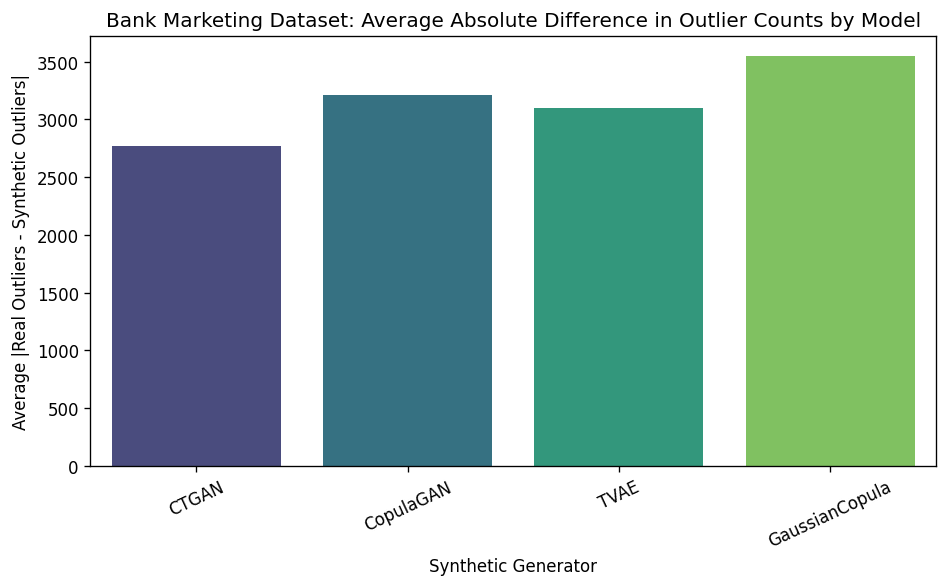

In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "y"

real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

def outlier_count_iqr(series):
    series = pd.to_numeric(series, errors="coerce").dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    return ((series < lo) | (series > hi)).sum()

rows = []
feature_diff_by_model = {}

real_outliers = {c: outlier_count_iqr(real_df[c]) for c in num_cols}

for model in model_order:
    synth_df = synthetic_datasets[model].reindex(columns=real_df.columns).copy()
    synth_outliers = {c: outlier_count_iqr(synth_df[c]) for c in num_cols}

    feat_df = pd.DataFrame({
        "Feature": num_cols,
        "Real_Outliers": [real_outliers[c] for c in num_cols],
        "Synthetic_Outliers": [synth_outliers[c] for c in num_cols]
    })
    feat_df["Abs_Diff_Outlier_Count"] = (feat_df["Real_Outliers"] - feat_df["Synthetic_Outliers"]).abs()

    feature_diff_by_model[model] = feat_df
    rows.append({
        "Model": model,
        "Avg_Abs_Diff_Outlier_Count": float(feat_df["Abs_Diff_Outlier_Count"].mean()),
        "Median_Abs_Diff_Outlier_Count": float(feat_df["Abs_Diff_Outlier_Count"].median()),
        "Max_Abs_Diff_Outlier_Count": float(feat_df["Abs_Diff_Outlier_Count"].max())
    })

outlier_summary_df = (
    pd.DataFrame(rows)
    .set_index("Model")
    .reindex(model_order)
    .reset_index()
)

print("Average absolute difference in outlier counts (Real vs Synthetic) by model:")
display(outlier_summary_df)

plt.figure(figsize=(8, 5), dpi=120)
sns.barplot(
    data=outlier_summary_df,
    x="Model",
    y="Avg_Abs_Diff_Outlier_Count",
    order=model_order,
    palette="viridis"
)
plt.title("Bank Marketing Dataset: Average Absolute Difference in Outlier Counts by Model")
plt.xlabel("Synthetic Generator")
plt.ylabel("Average |Real Outliers - Synthetic Outliers|")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


# 6. Cosine Similarity with Hungraian Mapping

In [31]:
from numpy.linalg import norm
import numpy as np
import pandas as pd
from sdv.single_table import CTGANSynthesizer, CopulaGANSynthesizer, TVAESynthesizer, GaussianCopulaSynthesizer

target_col = "y"

if "ctgan" not in globals():
    ctgan = CTGANSynthesizer(metadata=metadata)
    ctgan.fit(data)

if "copulagan" not in globals():
    copulagan = CopulaGANSynthesizer(metadata=metadata)
    copulagan.fit(data)

if "tvae" not in globals():
    tvae = TVAESynthesizer(metadata=metadata)
    tvae.fit(data)

if "gaussiancopula" not in globals():
    gaussiancopula = GaussianCopulaSynthesizer(metadata=metadata)
    gaussiancopula.fit(data)

synth_models = {
    "CTGAN": ctgan,
    "CopulaGAN": copulagan,
    "TVAE": tvae,
    "GaussianCopula": gaussiancopula
}

n_rows = 1000
synthetic_data = {}
for name, synth in synth_models.items():
    synthetic_data[name] = synth.sample(num_rows=n_rows).reindex(columns=data.columns)

def normalize_rows(X):
    X = np.asarray(X, dtype=np.float64)
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

cosine_results = {}
cosine_dfs = {}

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

real_matrix = normalize_rows(data[num_cols].apply(pd.to_numeric, errors="coerce").fillna(0).to_numpy(dtype=np.float64))

for model_name, synth_df in synthetic_data.items():
    print(f"Building cosine similarity DataFrame for {model_name}...")

    synth_matrix = normalize_rows(
        synth_df[num_cols].apply(pd.to_numeric, errors="coerce").fillna(0).to_numpy(dtype=np.float64)
    )
    cosine_matrix = real_matrix @ synth_matrix.T

    block_n = 10
    n = min(block_n, cosine_matrix.shape[0], cosine_matrix.shape[1])

    cosine_df = pd.DataFrame(
        cosine_matrix[:n, :n],
        index=[f"R{i+1}" for i in range(n)],
        columns=[f"S{j+1}" for j in range(n)]
    )

    cosine_dfs[model_name] = cosine_df
    cosine_results[model_name] = {
        "avg_cosine": float(cosine_matrix.mean()),
        "max_cosine": float(cosine_matrix.max())
    }

    print(cosine_df, "\n")

display(pd.DataFrame(cosine_results).T)

Building cosine similarity DataFrame for CTGAN...
           S1        S2        S3        S4        S5        S6        S7  \
R1   0.963643  0.963577  0.543635  0.274177  0.224325  0.995692  0.102440   
R2   0.542515  0.539223  0.828860  0.978468  0.975764  0.302893  0.955393   
R3   0.394983  0.403308  0.738258  0.935953  0.971043  0.158402  0.939194   
R4   0.946197  0.948263  0.499206  0.216334  0.170425  0.995419  0.042942   
R5   0.388676  0.374442  0.779076  0.984725  0.966918  0.121783  0.994013   
R6   0.986347  0.983730  0.787611  0.644540  0.602791  0.904830  0.501411   
R7   0.997969  0.991281  0.748614  0.572417  0.517326  0.937688  0.420605   
R8   0.388169  0.368848  0.784052  0.988119  0.957406  0.116783  0.997806   
R9   0.938093  0.963929  0.666618  0.504672  0.525646  0.911370  0.357661   
R10  0.956488  0.961211  0.522689  0.249467  0.210642  0.998359  0.076869   

           S8        S9       S10  
R1   0.638341  0.528499  0.998406  
R2   0.901150  0.945733  0.247

,avg_cosine,max_cosine
CTGAN,0.524247,1.0
CopulaGAN,0.593295,1.0
TVAE,0.563034,1.0
GaussianCopula,0.340717,1.0


In [32]:
import numpy as np
import pandas as pd
from numpy.linalg import norm

target_col = "y"

def normalize_rows(X):
    X = np.asarray(X, dtype=np.float64)
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

def associate_real_with_synthetic(real_data: pd.DataFrame, synthetic_data: pd.DataFrame):
    num_cols = real_data.select_dtypes(include=["number"]).columns.tolist()
    num_cols = [c for c in num_cols if c != target_col]

    R = real_data[num_cols].apply(pd.to_numeric, errors="coerce").fillna(0).to_numpy(dtype=np.float64)
    S = synthetic_data[num_cols].apply(pd.to_numeric, errors="coerce").fillna(0).to_numpy(dtype=np.float64)

    R_norm = normalize_rows(R)
    S_norm = normalize_rows(S)

    cos_sim = R_norm @ S_norm.T
    best_s_idx = np.argmax(cos_sim, axis=1)
    best_sim = cos_sim[np.arange(len(R)), best_s_idx]

    return best_s_idx, best_sim, cos_sim

data = data.copy()
results = {}

for name, synth_df in synthetic_data.items():
    synth_df = synth_df.reindex(columns=data.columns).copy()
    best_indices, best_sims, cos_matrix = associate_real_with_synthetic(data, synth_df)

    results[name] = {
        "best_indices": best_indices,
        "best_sims": best_sims,
        "cos_matrix": cos_matrix,
    }

    top_idx = np.argsort(best_sims)[::-1][:10]

    print(f"\n{name} - Top 10 Real -> Synthetic Matchings")
    for rank, i in enumerate(top_idx, 1):
        print(f"{rank:02d}. R{i+1} -> S{best_indices[i]+1}   cosine similarity = {best_sims[i]:.4f}")



CTGAN - Top 10 Real -> Synthetic Matchings
01. R8829 -> S253   cosine similarity = 1.0000
02. R26364 -> S891   cosine similarity = 1.0000
03. R21157 -> S891   cosine similarity = 1.0000
04. R25321 -> S780   cosine similarity = 1.0000
05. R25837 -> S71   cosine similarity = 1.0000
06. R33695 -> S351   cosine similarity = 1.0000
07. R30977 -> S302   cosine similarity = 1.0000
08. R26182 -> S302   cosine similarity = 1.0000
09. R40028 -> S253   cosine similarity = 1.0000
10. R19122 -> S66   cosine similarity = 1.0000

CopulaGAN - Top 10 Real -> Synthetic Matchings
01. R5299 -> S497   cosine similarity = 1.0000
02. R26730 -> S908   cosine similarity = 1.0000
03. R26485 -> S647   cosine similarity = 1.0000
04. R38905 -> S835   cosine similarity = 1.0000
05. R26190 -> S8   cosine similarity = 1.0000
06. R10582 -> S521   cosine similarity = 1.0000
07. R917 -> S287   cosine similarity = 1.0000
08. R3807 -> S908   cosine similarity = 1.0000
09. R25012 -> S855   cosine similarity = 1.0000
10. R

In [33]:
import numpy as np
import pandas as pd
from numpy.linalg import norm
from scipy.optimize import linear_sum_assignment

target_col = "y"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

def normalize_rows(X: np.ndarray) -> np.ndarray:
    X = np.asarray(X, dtype=np.float64)
    norms = norm(X, axis=1, keepdims=True) + 1e-12
    return X / norms

def cosine_similarity_matrix(real_df: pd.DataFrame, synth_df: pd.DataFrame, num_cols=None) -> np.ndarray:
    if num_cols is None:
        num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [c for c in num_cols if c != target_col]

    R = real_df[num_cols].apply(pd.to_numeric, errors="coerce").fillna(0).to_numpy(dtype=np.float64)
    S = synth_df[num_cols].apply(pd.to_numeric, errors="coerce").fillna(0).to_numpy(dtype=np.float64)
    return normalize_rows(R) @ normalize_rows(S).T

def hungarian_match(real_df: pd.DataFrame, synth_df: pd.DataFrame, num_cols=None):
    cos_sim = cosine_similarity_matrix(real_df, synth_df, num_cols)
    n_real, n_synth = cos_sim.shape

    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(1.0 - cos_sim)
    else:
        col_ind, row_ind = linear_sum_assignment(1.0 - cos_sim.T)

    sims = cos_sim[row_ind, col_ind]
    avg_sim = float(sims.mean())
    return row_ind, col_ind, sims, avg_sim, cos_sim

if "synthetic_datasets" in globals():
    synth_source = synthetic_datasets
elif "synthetic_data" in globals():
    synth_source = synthetic_data
else:
    raise NameError("No synthetic source found. Expected `synthetic_datasets` or `synthetic_data`.")

real_df = data.copy()
results = {}

for name in model_order:
    synth_df = synth_source[name].reindex(columns=real_df.columns).copy()

    print(f"\n==============================")
    print(f"{name}: Hungarian matching (cosine, numeric features excluding {target_col})")
    print(f"==============================")

    row_ind, col_ind, sims, avg_sim, cos_matrix = hungarian_match(real_df, synth_df)

    results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "similarities": sims,
        "avg_similarity": avg_sim,
        "cos_matrix": cos_matrix,
    }

    print(f"Average cosine similarity (Hungarian match): {avg_sim:.4f}\n")

    order = np.argsort(sims)[::-1]
    top_k = min(10, len(order))
    for r in range(top_k):
        k = order[r]
        print(f"R{row_ind[k]+1} <-> S{col_ind[k]+1}   cosine similarity = {sims[k]:.4f}")



CTGAN: Hungarian matching (cosine, numeric features excluding y)
Average cosine similarity (Hungarian match): 0.9997

R11993 <-> S3710   cosine similarity = 1.0000
R43868 <-> S3360   cosine similarity = 1.0000
R21157 <-> S6515   cosine similarity = 1.0000
R22255 <-> S457   cosine similarity = 1.0000
R8771 <-> S7571   cosine similarity = 1.0000
R9537 <-> S3429   cosine similarity = 1.0000
R27165 <-> S3208   cosine similarity = 1.0000
R9128 <-> S2915   cosine similarity = 1.0000
R25856 <-> S2414   cosine similarity = 1.0000
R27480 <-> S5740   cosine similarity = 1.0000

CopulaGAN: Hungarian matching (cosine, numeric features excluding y)
Average cosine similarity (Hungarian match): 0.9995

R35525 <-> S8790   cosine similarity = 1.0000
R5123 <-> S1503   cosine similarity = 1.0000
R18115 <-> S12   cosine similarity = 1.0000
R20179 <-> S8402   cosine similarity = 1.0000
R39712 <-> S7817   cosine similarity = 1.0000
R22646 <-> S981   cosine similarity = 1.0000
R26323 <-> S8392   cosine simi

In [34]:
import pandas as pd
import numpy as np

target_col = "y"

real_df = data.copy()
feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != target_col]

if "synthetic_datasets" in globals():
    synth_source = synthetic_datasets
elif "synthetic_data" in globals():
    synth_source = synthetic_data
else:
    raise NameError("No synthetic source found. Expected `synthetic_datasets` or `synthetic_data`.")

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
output_file = "Matchings_All_Models_Bank_Marketing.xlsx"

combined_rows = []
summary_rows = []

with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
    for model_name in model_order:
        if model_name not in results or model_name not in synth_source:
            continue

        model_res = results[model_name]

        if "row_ind" in model_res and "col_ind" in model_res:
            row_ind = np.asarray(model_res["row_ind"])
            col_ind = np.asarray(model_res["col_ind"])

            if "similarities" in model_res:
                score_key = "cosine_similarity"
                scores = np.asarray(model_res["similarities"])
            elif "distances" in model_res:
                score_key = "mahalanobis_distance"
                scores = np.asarray(model_res["distances"])
            else:
                raise KeyError(
                    f"No score array found for model {model_name}. "
                    "Expected 'similarities' or 'distances'."
                )

        elif "best_indices" in model_res and "best_sims" in model_res:
            row_ind = np.arange(len(model_res["best_indices"]))
            col_ind = np.asarray(model_res["best_indices"])
            score_key = "cosine_similarity"
            scores = np.asarray(model_res["best_sims"])
        else:
            raise KeyError(
                f"Unsupported results format for model {model_name}. "
                "Expected Hungarian keys or best-match keys."
            )

        mapping_df = pd.DataFrame({
            "Model": model_name,
            "real_index": row_ind,
            "synthetic_index": col_ind,
            "real_label": [f"R{i+1}" for i in row_ind],
            "synthetic_label": [f"S{j+1}" for j in col_ind],
            score_key: scores
        })

        real_part = real_df.iloc[row_ind][feature_cols].reset_index(drop=True)
        real_part.insert(0, "real_label", [f"R{i+1}" for i in row_ind])

        synth_df = synth_source[model_name].reindex(columns=real_df.columns).copy()
        synth_part = synth_df.iloc[col_ind][feature_cols].reset_index(drop=True)
        synth_part.insert(0, "synthetic_label", [f"S{j+1}" for j in col_ind])

        side_by_side = pd.concat(
            [
                mapping_df.reset_index(drop=True),
                real_part.add_prefix("real_"),
                synth_part.add_prefix("synth_")
            ],
            axis=1
        )

        side_by_side.to_excel(writer, sheet_name=model_name[:31], index=False)
        combined_rows.append(side_by_side)

        summary_row = {
            "Model": model_name,
            "Num_Matches": len(scores),
            f"Avg_{score_key}": float(np.mean(scores)),
            f"Median_{score_key}": float(np.median(scores)),
            f"Min_{score_key}": float(np.min(scores)),
            f"Max_{score_key}": float(np.max(scores)),
        }
        summary_rows.append(summary_row)

    if combined_rows:
        combined_df = pd.concat(combined_rows, ignore_index=True)
        combined_df.to_excel(writer, sheet_name="All_Models_Combined", index=False)

    if summary_rows:
        summary_df = pd.DataFrame(summary_rows)
        sort_col = [c for c in summary_df.columns if c.startswith("Avg_")][0]
        ascending = False if "cosine" in sort_col else True
        summary_df = summary_df.sort_values(sort_col, ascending=ascending)
        summary_df.to_excel(writer, sheet_name="Summary", index=False)

print(f"Saved: {output_file}")
display(summary_df)

Saved: Matchings_All_Models_Bank_Marketing.xlsx


,Model,Num_Matches,Avg_cosine_similarity,Median_cosine_similarity,Min_cosine_similarity,Max_cosine_similarity
0,CTGAN,10000,0.999669,0.999966,0.908905,1.0
1,CopulaGAN,10000,0.999473,0.999955,0.948405,1.0
2,TVAE,10000,0.998968,0.999845,0.936198,1.0
3,GaussianCopula,10000,0.993143,0.999958,0.869440,1.0


# 7. Mahalanobis distance with Hungrain Mapping  

In [35]:
import numpy as np
from numpy.linalg import inv, LinAlgError

target_col = "y"

def fit_mahalanobis_params(real_matrix, reg=1e-6):
    mu = np.mean(real_matrix, axis=0)
    cov = np.cov(real_matrix, rowvar=False)
    if cov.ndim == 0:
        cov = np.array([[cov]])
    p = cov.shape[0]
    try:
        inv_cov = inv(cov + reg * np.eye(p))
    except LinAlgError:
        inv_cov = np.linalg.pinv(cov + reg * np.eye(p))
    return mu, inv_cov

def mahalanobis_distances_to_distribution(synth_matrix, mu, inv_cov):
    delta = synth_matrix - mu
    d2 = np.einsum("ij,jk,ik->i", delta, inv_cov, delta)
    return np.sqrt(np.maximum(d2, 0.0))

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

data_numeric = data[num_cols].apply(pd.to_numeric, errors="coerce").dropna().copy()
real_matrix = data_numeric.to_numpy(dtype=np.float64)

mu_real, inv_cov_real = fit_mahalanobis_params(real_matrix)
print("Fitted mean and inverse covariance on real Bank Marketing feature data.")
print(f"Used features (excluding target): {len(num_cols)}")
print(f"Mean shape: {mu_real.shape}, Inv_cov shape: {inv_cov_real.shape}")

Fitted mean and inverse covariance on real Bank Marketing feature data.
Used features (excluding target): 7
Mean shape: (7,), Inv_cov shape: (7, 7)


In [36]:
import pandas as pd
import numpy as np

mahalanobis_results = {}
target_col = "y"

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

if "synthetic_datasets" in globals():
    synth_source = synthetic_datasets
elif "synthetic_data" in globals():
    synth_source = synthetic_data
else:
    raise NameError("No synthetic source found. Expected `synthetic_datasets` or `synthetic_data`.")

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_df = synth_source[name].reindex(columns=data.columns).copy()
    synth_numeric = (
        synth_df[num_cols]
        .apply(pd.to_numeric, errors="coerce")
        .dropna()
        .to_numpy(dtype=np.float64)
    )

    dists = mahalanobis_distances_to_distribution(synth_numeric, mu_real, inv_cov_real)

    mahalanobis_results[name] = {
        "mean": float(np.mean(dists)),
        "median": float(np.median(dists)),
        "std": float(np.std(dists)),
        "min": float(np.min(dists)),
        "max": float(np.max(dists)),
        "distances": dists,
    }

summary = pd.DataFrame({
    name: [r["mean"], r["median"], r["std"], r["min"], r["max"]]
    for name, r in mahalanobis_results.items()
}, index=["mean_dist", "median_dist", "std_dist", "min_dist", "max_dist"]).T

summary.index.name = "Model"
summary = summary.sort_values("mean_dist")

print("Mahalanobis distance to real Bank Marketing distribution (lower is better):")
display(summary)

Mahalanobis distance to real Bank Marketing distribution (lower is better):


,mean_dist,median_dist,std_dist,min_dist,max_dist
Model,,,,,
TVAE,1.919344,1.823717,0.694146,0.593057,9.505109
CopulaGAN,2.137410,2.019676,0.803697,0.649428,9.795306
CTGAN,2.254442,1.947063,1.212866,0.477175,12.282633
GaussianCopula,2.329350,2.114069,1.002012,0.541934,10.255516


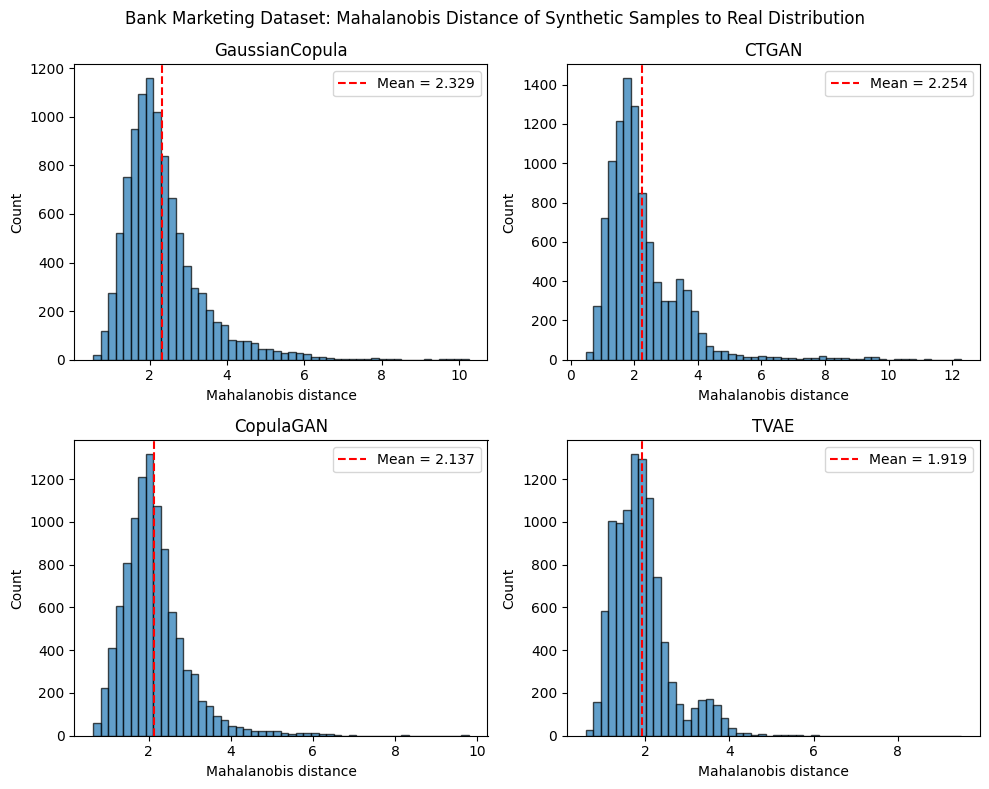

In [37]:
import os
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, (name, res) in zip(axes, mahalanobis_results.items()):
    ax.hist(res["distances"], bins=50, edgecolor="black", alpha=0.7)
    ax.axvline(res["mean"], color="red", linestyle="--", label=f"Mean = {res['mean']:.3f}")
    ax.set_title(name)
    ax.set_xlabel("Mahalanobis distance")
    ax.set_ylabel("Count")
    ax.legend()

for j in range(len(mahalanobis_results), len(axes)):
    axes[j].axis("off")

plt.suptitle(
    "Bank Marketing Dataset: Mahalanobis Distance of Synthetic Samples to Real Distribution",
    fontsize=12
)
plt.tight_layout()

ROOT = os.getcwd()
os.makedirs(os.path.join(ROOT, "figures"), exist_ok=True)
plt.savefig(
    os.path.join(ROOT, "figures", "mahalanobis_bank_marketing_by_model.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [38]:
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd

target_col = "y"

def pairwise_mahalanobis(real_matrix, synth_matrix, inv_cov):
    return cdist(real_matrix, synth_matrix, metric="mahalanobis", VI=inv_cov)

hungarian_results = {}

# --- Select numeric columns ---
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

# --- Prepare full real matrix ---
real_matrix_full = (
    data[num_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .to_numpy(dtype=np.float64)
)

# --- Detect synthetic source ---
if "synthetic_datasets" in globals():
    synth_source = synthetic_datasets
elif "synthetic_data" in globals():
    synth_source = synthetic_data
else:
    raise NameError("No synthetic source found. Expected `synthetic_datasets` or `synthetic_data`.")

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    
    # --- Prepare synthetic matrix ---
    synth_numeric = (
        synth_source[name]
        .reindex(columns=data.columns)[num_cols]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0)
        .to_numpy(dtype=np.float64)
    )

    sample_size = synth_numeric.shape[0]

    # --- Sample real data to match synthetic size ---
    real_sampled = (
        pd.DataFrame(real_matrix_full)
        .sample(n=sample_size, random_state=42)
        .to_numpy()
    )

    # --- Recompute covariance on sampled real ---
    cov_real = np.cov(real_sampled, rowvar=False)
    inv_cov_real = np.linalg.pinv(cov_real)

    # --- Compute distance matrix ---
    D = pairwise_mahalanobis(real_sampled, synth_numeric, inv_cov_real)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

    # --- Hungarian matching ---
    row_ind, col_ind = linear_sum_assignment(D)
    matched_distances = D[row_ind, col_ind]

    # --- Store results ---
    hungarian_results[name] = {
        "mean_distance_per_match": float(matched_distances.mean()),
        "median_distance_per_match": float(np.median(matched_distances)),
        "std_distance_per_match": float(np.std(matched_distances)),
        "max_distance_per_match": float(matched_distances.max()),
    }

# --- Summary table ---
hungarian_summary = pd.DataFrame.from_dict(hungarian_results, orient="index")
hungarian_summary.index.name = "Model"
hungarian_summary = hungarian_summary.sort_values("mean_distance_per_match")

print("Bank Marketing Dataset - Hungarian matching using Mahalanobis distance (lower is better):")
display(hungarian_summary)

Bank Marketing Dataset - Hungarian matching using Mahalanobis distance (lower is better):


,mean_distance_per_match,median_distance_per_match,std_distance_per_match,max_distance_per_match
Model,,,,
CTGAN,0.721561,0.437017,0.968016,26.581310
CopulaGAN,0.973256,0.730334,0.881404,29.229966
TVAE,1.065509,0.655953,1.348205,29.630884
GaussianCopula,1.536039,1.182877,1.248699,30.830646


In [39]:
import numpy as np
import pandas as pd

target_col = "y"

def greedy_one_to_one_matching_fast(D):
    n_rows, n_cols = D.shape
    n_match = min(n_rows, n_cols)

    used_rows = np.zeros(n_rows, dtype=bool)
    used_cols = np.zeros(n_cols, dtype=bool)

    flat_order = np.argsort(D, axis=None)
    pairs = []

    for idx in flat_order:
        i = idx // n_cols
        j = idx % n_cols
        if not used_rows[i] and not used_cols[j]:
            used_rows[i] = True
            used_cols[j] = True
            pairs.append((i, j, float(D[i, j])))
            if len(pairs) == n_match:
                break

    distances = np.array([p[2] for p in pairs], dtype=np.float64)
    total_distance = float(distances.sum()) if len(distances) else np.nan
    mean_distance = float(distances.mean()) if len(distances) else np.nan
    return total_distance, mean_distance, pairs

greedy_results = {}
comparison_rows = []

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

X_real_full = (
    data[num_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .to_numpy(dtype=np.float64)
)

MAX_ROWS = 2000
rng = np.random.default_rng(42)

real_idx = rng.choice(len(X_real_full), size=min(MAX_ROWS, len(X_real_full)), replace=False)
X_real = X_real_full[real_idx]

if "synthetic_datasets" in globals():
    synth_source = synthetic_datasets
elif "synthetic_data" in globals():
    synth_source = synthetic_data
else:
    raise NameError("No synthetic source found.")

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    X_synth_full = (
        synth_source[name]
        .reindex(columns=data.columns)[num_cols]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0)
        .to_numpy(dtype=np.float64)
    )

    synth_idx = rng.choice(len(X_synth_full), size=min(MAX_ROWS, len(X_synth_full)), replace=False)
    X_synth = X_synth_full[synth_idx]

    cov_real = np.cov(X_real, rowvar=False)
    inv_cov_real = np.linalg.pinv(cov_real)

    D = pairwise_mahalanobis(X_real, X_synth, inv_cov_real)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

    total_g, mean_g, _ = greedy_one_to_one_matching_fast(D)

    greedy_results[name] = {
        "total_distance": total_g,
        "mean_distance": mean_g
    }

    h_total = hungarian_results[name].get("total_distance", np.nan)
    h_mean = hungarian_results[name].get("mean_distance_per_match", np.nan)

    comparison_rows.append({
        "Model": name,
        "Rows_Used_For_Greedy": int(min(len(X_real), len(X_synth))),
        "Greedy total (sampled)": total_g,
        "Hungarian total (full)": h_total,
        "Greedy mean (sampled)": mean_g,
        "Hungarian mean (full)": h_mean,
        "Total diff": total_g - h_total if not np.isnan(h_total) else np.nan,
        "Mean diff": mean_g - h_mean if not np.isnan(h_mean) else np.nan,
    })

greedy_summary = pd.DataFrame({
    name: [greedy_results[name]["total_distance"], greedy_results[name]["mean_distance"]]
    for name in greedy_results
}, index=["total_distance", "mean_distance"]).T

greedy_summary.index.name = "Model"

print("Bank Marketing Dataset - Greedy one-to-one matching (fast sampled version):")
display(greedy_summary)

print("\nComparison table:")
comparison_df = pd.DataFrame(comparison_rows).set_index("Model")
display(comparison_df)

Bank Marketing Dataset - Greedy one-to-one matching (fast sampled version):


,total_distance,mean_distance
Model,,
GaussianCopula,3823.558687,1.911779
CTGAN,2005.518689,1.002759
CopulaGAN,2534.967169,1.267484
TVAE,2502.731259,1.251366



Comparison table:


,Rows_Used_For_Greedy,Greedy total (sampled),Hungarian total (full),Greedy mean (sampled),Hungarian mean (full),Total diff,Mean diff
Model,,,,,,,
GaussianCopula,2000,3823.558687,NaN,1.911779,1.536039,NaN,0.375740
CTGAN,2000,2005.518689,NaN,1.002759,0.721561,NaN,0.281199
CopulaGAN,2000,2534.967169,NaN,1.267484,0.973256,NaN,0.294227
TVAE,2000,2502.731259,NaN,1.251366,1.065509,NaN,0.185856


In [40]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

target_col = "y"

def mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real):
    R = real_df[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0).to_numpy(dtype=np.float64)
    S = synth_df[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0).to_numpy(dtype=np.float64)
    return cdist(R, S, metric="mahalanobis", VI=inv_cov_real)

def hungarian_match_mahalanobis(real_df, synth_df, feature_cols, inv_cov_real):
    D = mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real)
    D = np.nan_to_num(np.asarray(D, dtype=np.float64), nan=1e10, posinf=1e10, neginf=1e10)

    n_real, n_synth = D.shape
    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(D)
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)

    dists = D[row_ind, col_ind]
    return row_ind, col_ind, dists, float(dists.mean()), D

real_df = data.copy()

feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != target_col]
print("Using numeric non-target features:", len(feature_cols))

X_real = (
    real_df[feature_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .to_numpy(dtype=np.float64)
)
mu_real = X_real.mean(axis=0)
cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

if "synthetic_datasets" in globals():
    synth_source = synthetic_datasets
elif "synthetic_data" in globals():
    synth_source = synthetic_data
else:
    raise NameError("No synthetic source found. Expected `synthetic_datasets` or `synthetic_data`.")

mahalanobis_results = {}

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_df = synth_source[name].reindex(columns=real_df.columns).copy()

    row_ind, col_ind, dists, avg_dist, D = hungarian_match_mahalanobis(
        real_df=real_df,
        synth_df=synth_df,
        feature_cols=feature_cols,
        inv_cov_real=inv_cov_real
    )

    mahalanobis_results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "distances": dists,
        "avg_distance": avg_dist
    }

    print(f"{name}: avg matched Mahalanobis distance = {avg_dist:.4f}")

Using numeric non-target features: 7
GaussianCopula: avg matched Mahalanobis distance = 0.9155
CTGAN: avg matched Mahalanobis distance = 0.3454
CopulaGAN: avg matched Mahalanobis distance = 0.5855
TVAE: avg matched Mahalanobis distance = 0.2283


In [41]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

target_col = "y"

feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != target_col]

real_df = data.copy()
X_real = (
    real_df[feature_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .to_numpy(dtype=np.float64)
)

cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

if "synthetic_datasets" in globals():
    synth_source = synthetic_datasets
elif "synthetic_data" in globals():
    synth_source = synthetic_data
else:
    raise NameError("No synthetic source found. Expected `synthetic_datasets` or `synthetic_data`.")

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

for model_name in model_order:
    synth_df = synth_source[model_name].reindex(columns=real_df.columns).copy()
    X_synth = (
        synth_df[feature_cols]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0)
        .to_numpy(dtype=np.float64)
    )

    D = cdist(X_real, X_synth, metric="mahalanobis", VI=inv_cov_real)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

    row_ind, col_ind = linear_sum_assignment(D)
    dists = D[row_ind, col_ind]

    print(f"\n{model_name} - Hungarian mappings for R1 to R20:")
    for r in range(min(20, len(row_ind))):
        print(f"R{row_ind[r] + 1} -> S{col_ind[r] + 1}   distance = {dists[r]:.4f}")


CTGAN - Hungarian mappings for R1 to R20:
R2 -> S2031   distance = 0.1570
R10 -> S1104   distance = 0.1009
R18 -> S1687   distance = 0.0646
R27 -> S1298   distance = 0.1305
R30 -> S1437   distance = 0.1202
R42 -> S5333   distance = 0.1449
R72 -> S2030   distance = 0.0608
R83 -> S1394   distance = 0.1288
R89 -> S1363   distance = 0.1381
R91 -> S4480   distance = 0.0819
R97 -> S7847   distance = 0.0882
R110 -> S2511   distance = 0.2996
R113 -> S1314   distance = 0.0990
R116 -> S7271   distance = 0.1229
R118 -> S2221   distance = 0.1308
R121 -> S4649   distance = 0.1851
R123 -> S943   distance = 0.1028
R124 -> S3414   distance = 0.0988
R126 -> S81   distance = 0.0943
R128 -> S4847   distance = 0.0675

CopulaGAN - Hungarian mappings for R1 to R20:
R42 -> S4867   distance = 0.4917
R60 -> S665   distance = 0.6818
R69 -> S8374   distance = 0.5164
R89 -> S2984   distance = 0.4951
R90 -> S2656   distance = 0.4999
R92 -> S3844   distance = 0.5098
R113 -> S7912   distance = 0.4887
R116 -> S4100 

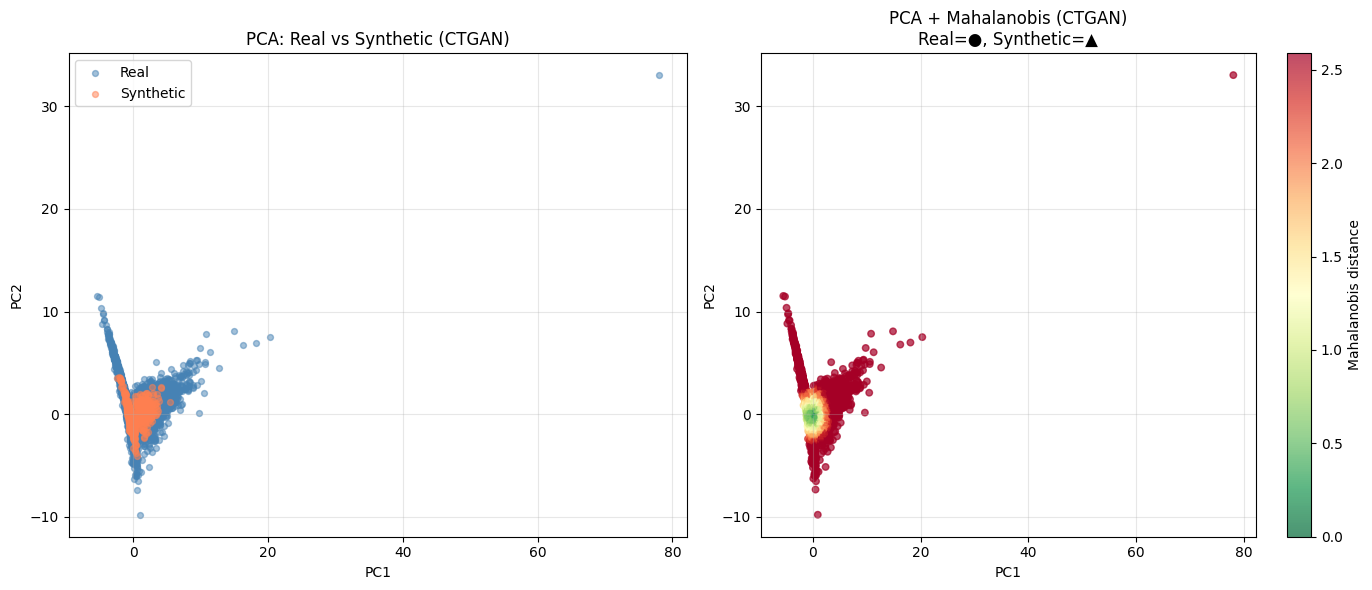

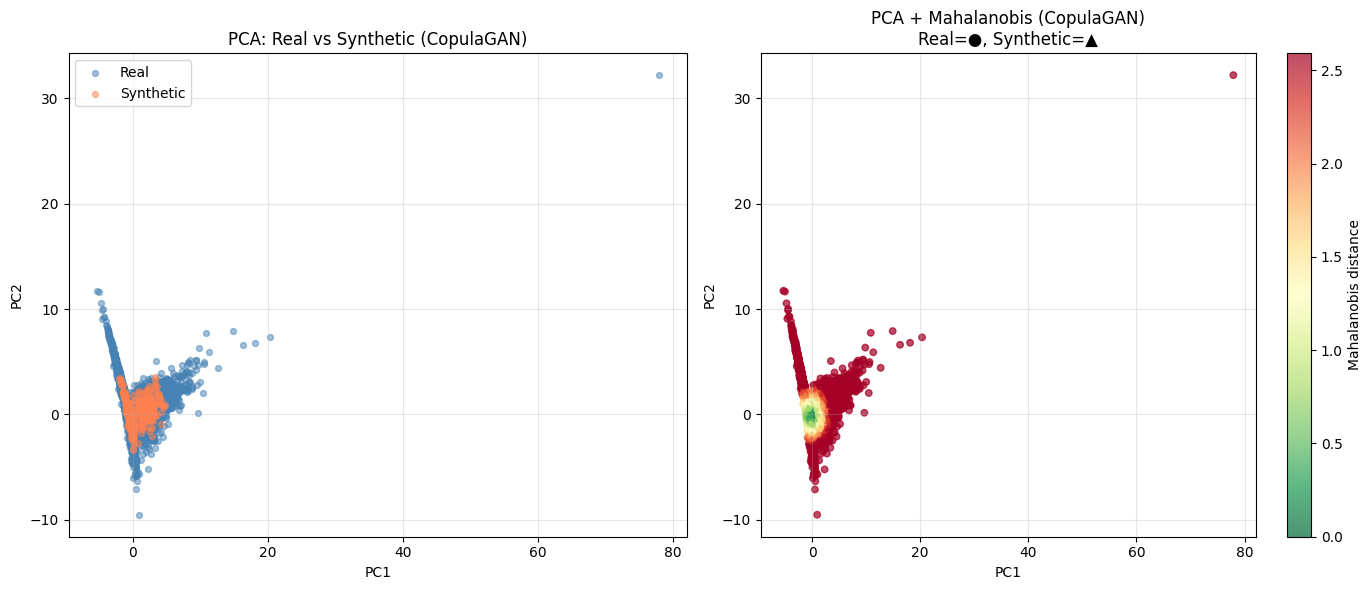

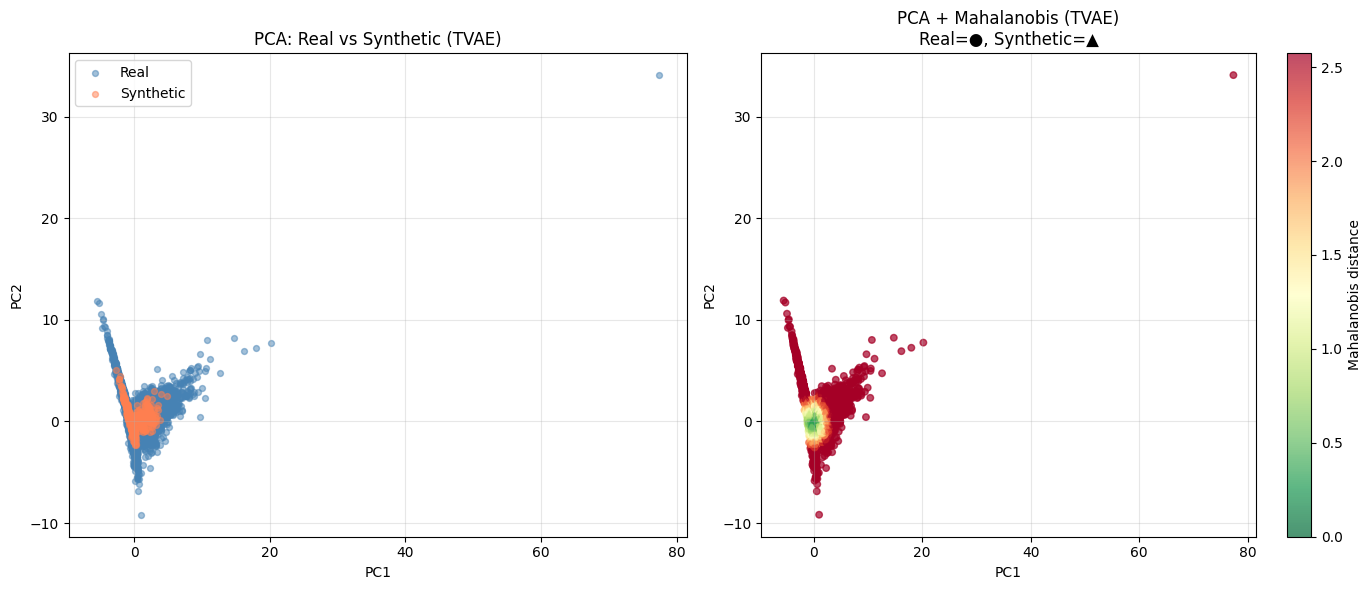

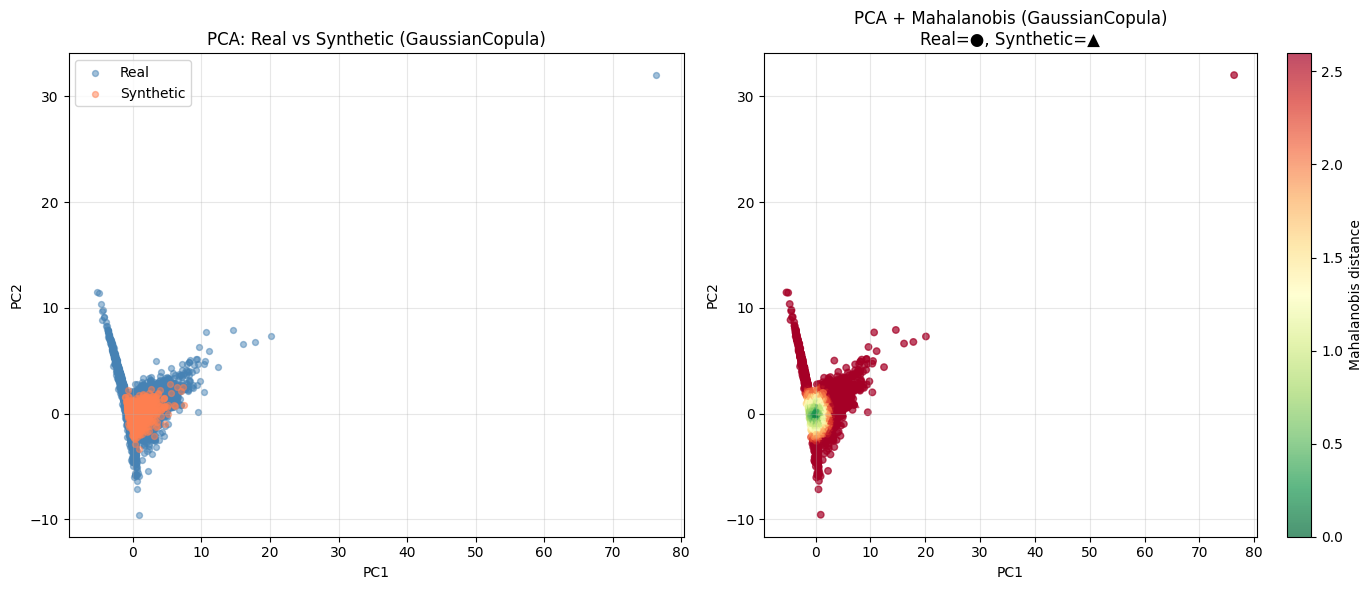

Bank Marketing Dataset - PCA + Mahalanobis summary:


,Model,Real_Mean_MD_2D,Synth_Mean_MD_2D,Delta_Synth_minus_Real
2,TVAE,1.070003,1.015078,-0.054925
3,GaussianCopula,1.074833,1.058052,-0.016782
0,CTGAN,1.069200,1.075318,0.006117
1,CopulaGAN,1.070028,1.100806,0.030778


In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import inv, LinAlgError
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

target_col = "y"

def _mahal_dist_2d(X, mu, inv_cov):
    delta = X - mu
    return np.sqrt(np.maximum(np.einsum("ij,jk,ik->i", delta, inv_cov, delta), 0.0))

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = data.copy()
feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != target_col]

X_r = (
    real_df[feature_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .to_numpy(dtype=np.float64)
)
scaler = StandardScaler().fit(X_r)
X_r_s = scaler.transform(X_r)

rows = []

for model_name in model_order:
    if model_name not in synthetic_data:
        print(f"{model_name} not found in synthetic_data, skipping.")
        continue

    synth_df = synthetic_data[model_name][real_df.columns].copy()
    X_s = (
        synth_df[feature_cols]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0)
        .to_numpy(dtype=np.float64)
    )
    X_s_s = scaler.transform(X_s)

    X_all = np.vstack([X_r_s, X_s_s])
    Z_all = PCA(n_components=2, random_state=42).fit_transform(X_all)

    n_r = len(X_r_s)
    Z_r = Z_all[:n_r]
    Z_s = Z_all[n_r:]

    mu_z = np.mean(Z_r, axis=0)
    cov_z = np.cov(Z_r, rowvar=False)
    reg = 1e-6

    try:
        inv_cov_z = inv(cov_z + reg * np.eye(2))
    except LinAlgError:
        inv_cov_z = np.linalg.pinv(cov_z + reg * np.eye(2))

    d_r = _mahal_dist_2d(Z_r, mu_z, inv_cov_z)
    d_s = _mahal_dist_2d(Z_s, mu_z, inv_cov_z)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    ax.scatter(Z_r[:, 0], Z_r[:, 1], c="steelblue", alpha=0.5, s=18, label="Real")
    ax.scatter(Z_s[:, 0], Z_s[:, 1], c="coral", alpha=0.5, s=18, label="Synthetic")
    ax.set_title(f"PCA: Real vs Synthetic ({model_name})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    vmax = np.percentile(np.hstack([d_r, d_s]), 95)
    sc = ax.scatter(
        Z_r[:, 0], Z_r[:, 1], c=d_r, cmap="RdYlGn_r", alpha=0.7, s=22, marker="o", vmin=0, vmax=vmax
    )
    ax.scatter(
        Z_s[:, 0], Z_s[:, 1], c=d_s, cmap="RdYlGn_r", alpha=0.55, s=12, marker="^", vmin=0, vmax=vmax
    )
    plt.colorbar(sc, ax=ax, label="Mahalanobis distance")
    ax.set_title(f"PCA + Mahalanobis ({model_name})\nReal=●, Synthetic=▲")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    rows.append({
        "Model": model_name,
        "Real_Mean_MD_2D": float(d_r.mean()),
        "Synth_Mean_MD_2D": float(d_s.mean()),
        "Delta_Synth_minus_Real": float(d_s.mean() - d_r.mean())
    })

summary_df = pd.DataFrame(rows).sort_values("Synth_Mean_MD_2D")
print("Bank Marketing Dataset - PCA + Mahalanobis summary:")
display(summary_df)

In [44]:
import pandas as pd
import numpy as np

def export_all_models_hungarian_mahalanobis_excel(
    real_df: pd.DataFrame,
    synthetic_data: dict,
    hungarian_results: dict,
    num_cols: list,
    filename: str = "Hungarian_Mahalanobis_Four_Models_Bank_Marketing.xlsx"
):
    dataset_name = "Bank_Marketing"
    model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
    summary_rows = []

    with pd.ExcelWriter(filename, engine="openpyxl") as writer:
        wrote_any_sheet = False

        for model_name in model_order:
            if model_name not in synthetic_data or model_name not in hungarian_results:
                continue

            synth_df = synthetic_data[model_name].copy().reindex(columns=real_df.columns)

            row_ind = hungarian_results[model_name]["row_ind"]
            col_ind = hungarian_results[model_name]["col_ind"]

            if "dists" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["dists"]
            elif "distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["distances"]
            elif "selected_distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["selected_distances"]
            elif "matched_distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["matched_distances"]
            else:
                raise KeyError(f"No distance array found for {model_name}")

            records = []
            for r_i, s_i, dist in zip(row_ind, col_ind, matched_distances):
                rec = {
                    "Dataset": dataset_name,
                    "Model": model_name,
                    "Real_Index": int(r_i),
                    "Synthetic_Index": int(s_i),
                    "Real_Label": f"R{int(r_i)+1}",
                    "Synthetic_Label": f"S{int(s_i)+1}",
                    "Mahalanobis_Distance": float(dist),
                }
                for c in num_cols:
                    rec[f"Real_{c}"] = real_df.iloc[r_i][c]
                    rec[f"Synth_{c}"] = synth_df.iloc[s_i][c]
                records.append(rec)

            matched_df = pd.DataFrame(records)
            sheet_name = f"{dataset_name}_{model_name}"[:31]
            matched_df.to_excel(writer, sheet_name=sheet_name, index=False)
            wrote_any_sheet = True

            summary_rows.append({
                "Dataset": dataset_name,
                "Model": model_name,
                "Num_Matches": len(matched_df),
                "Mean_Distance": float(np.mean(matched_distances)),
                "Median_Distance": float(np.median(matched_distances)),
                "Std_Distance": float(np.std(matched_distances)),
                "Min_Distance": float(np.min(matched_distances)),
                "Max_Distance": float(np.max(matched_distances)),
            })

        if summary_rows:
            summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Distance")
            summary_df.to_excel(writer, sheet_name=f"{dataset_name}_Summary"[:31], index=False)
            wrote_any_sheet = True

        if not wrote_any_sheet:
            pd.DataFrame({"Message": ["No Hungarian results were available to export."]}).to_excel(
                writer, sheet_name="Info", index=False
            )

    print(f"Excel file created: {filename}")

# 8. Privacy Metrics: Membership Inference Attack (MIA)

In [46]:
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

def model_confidence_per_sample_classification(model, X):
    proba = model.predict_proba(X)
    return np.max(proba, axis=1)

def privacy_metrics_mia_classification(model, X_train, y_train, X_test, y_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train.astype(str))
    y_test_enc = le.transform(y_test.astype(str))

    model.fit(X_train_s, y_train_enc)

    conf_train = model_confidence_per_sample_classification(model, X_train_s)
    conf_test = model_confidence_per_sample_classification(model, X_test_s)

    scores = np.concatenate([conf_train, conf_test])
    labels = np.concatenate([np.ones(len(conf_train)), np.zeros(len(conf_test))])

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    idx_fpr_001 = np.searchsorted(fpr, 0.01, side="right") - 1
    idx_fpr_001 = max(0, idx_fpr_001)
    tpr_at_fpr_001 = tpr[idx_fpr_001] if idx_fpr_001 < len(tpr) else float("nan")

    return {"AUC": auc, "Advantage": advantage, "TPR_at_FPR_001": tpr_at_fpr_001}

target_col = "y"
feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != target_col]

real_df = data.copy()

if "synthetic_datasets" in globals():
    synth_source = synthetic_datasets
elif "synthetic_data" in globals():
    synth_source = synthetic_data
else:
    raise NameError("No synthetic source found. Expected `synthetic_datasets` or `synthetic_data`.")

synth_df = synth_source["GaussianCopula"].reindex(columns=real_df.columns).copy()

X_train = real_df[feature_cols].to_numpy(dtype=np.float64)
y_train = real_df[target_col].to_numpy()

X_test = synth_df[feature_cols].to_numpy(dtype=np.float64)
y_test = synth_df[target_col].to_numpy()

model = LogisticRegression(max_iter=1000, random_state=42)
metrics = privacy_metrics_mia_classification(model, X_train, y_train, X_test, y_test)
print(metrics)

{'AUC': 0.5245664528543937, 'Advantage': np.float64(0.04721574837981912), 'TPR_at_FPR_001': np.float64(0.01512906151157904)}


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

target_col = "y"

def privacy_metrics_mia_mahalanobis(X_train, X_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    mu = np.mean(X_train_s, axis=0)
    cov = np.cov(X_train_s, rowvar=False)
    cov = cov + 1e-6 * np.eye(cov.shape[0])
    cov_inv = np.linalg.pinv(cov)

    diff_train = X_train_s - mu
    diff_test = X_test_s - muimport numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

target_col = "y"

def privacy_metrics_mia_mahalanobis(X_train, X_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    mu = np.mean(X_train_s, axis=0)
    cov = np.cov(X_train_s, rowvar=False)
    cov = cov + 1e-6 * np.eye(cov.shape[0])
    cov_inv = np.linalg.pinv(cov)

    diff_train = X_train_s - mu
    diff_test = X_test_s - mu

    md_train = np.sqrt(np.maximum(np.sum((diff_train @ cov_inv) * diff_train, axis=1), 0.0))
    md_test = np.sqrt(np.maximum(np.sum((diff_test @ cov_inv) * diff_test, axis=1), 0.0))

    scores = -np.concatenate([md_train, md_test])
    labels = np.concatenate([np.ones(len(md_train)), np.zeros(len(md_test))])

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    idx = np.searchsorted(fpr, 0.01, side="right") - 1
    idx = max(0, idx)
    tpr_at_fpr_001 = tpr[idx] if idx < len(tpr) else float("nan")

    return {
        "AUC": float(auc),
        "Advantage": float(advantage),
        "TPR_at_FPR_001": float(tpr_at_fpr_001),
        "Train_MD_Mean": float(md_train.mean()),
        "Test_MD_Mean": float(md_test.mean()),
    }

feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != target_col]
X_train = data[feature_cols].to_numpy(dtype=np.float64)

if "synthetic_datasets" in globals():
    synth_source = synthetic_datasets
elif "synthetic_data" in globals():
    synth_source = synthetic_data
else:
    raise NameError("No synthetic source found. Expected `synthetic_datasets` or `synthetic_data`.")

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
rows = []

for model_name in model_order:
    X_test = synth_source[model_name].reindex(columns=data.columns)[feature_cols].to_numpy(dtype=np.float64)
    m = privacy_metrics_mia_mahalanobis(X_train, X_test)
    m["Model"] = model_name
    rows.append(m)

comparison_df = pd.DataFrame(rows)[
    ["Model", "AUC", "Advantage", "TPR_at_FPR_001", "Train_MD_Mean", "Test_MD_Mean"]
].sort_values("AUC", ascending=False).reset_index(drop=True)

print("Bank Marketing Dataset - MIA (Mahalanobis) comparison across 4 synthetic models:")
display(comparison_df)

    md_train = np.sqrt(np.maximum(np.sum((diff_train @ cov_inv) * diff_train, axis=1), 0.0))
    md_test = np.sqrt(np.maximum(np.sum((diff_test @ cov_inv) * diff_test, axis=1), 0.0))

    scores = -np.concatenate([md_train, md_test])
    labels = np.concatenate([np.ones(len(md_train)), np.zeros(len(md_test))])

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    idx = np.searchsorted(fpr, 0.01, side="right") - 1
    idx = max(0, idx)
    tpr_at_fpr_001 = tpr[idx] if idx < len(tpr) else float("nan")

    return {
        "AUC": float(auc),
        "Advantage": float(advantage),
        "TPR_at_FPR_001": float(tpr_at_fpr_001),
        "Train_MD_Mean": float(md_train.mean()),
        "Test_MD_Mean": float(md_test.mean()),
    }

feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != target_col]
X_train = data[feature_cols].to_numpy(dtype=np.float64)

if "synthetic_datasets" in globals():
    synth_source = synthetic_datasets
elif "synthetic_data" in globals():
    synth_source = synthetic_data
else:
    raise NameError("No synthetic source found. Expected `synthetic_datasets` or `synthetic_data`.")

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
rows = []

for model_name in model_order:
    X_test = synth_source[model_name].reindex(columns=data.columns)[feature_cols].to_numpy(dtype=np.float64)
    m = privacy_metrics_mia_mahalanobis(X_train, X_test)
    m["Model"] = model_name
    rows.append(m)

comparison_df = pd.DataFrame(rows)[
    ["Model", "AUC", "Advantage", "TPR_at_FPR_001", "Train_MD_Mean", "Test_MD_Mean"]
].sort_values("AUC", ascending=False).reset_index(drop=True)

print("Bank Marketing Dataset - MIA (Mahalanobis) comparison across 4 synthetic models:")
display(comparison_df)

Bank Marketing Dataset - MIA (Mahalanobis) comparison across 4 synthetic models:


,Model,AUC,Advantage,TPR_at_FPR_001,Train_MD_Mean,Test_MD_Mean
0,GaussianCopula,0.579011,0.138376,0.021654,2.204495,2.329349
1,CopulaGAN,0.540008,0.103135,0.022052,2.204495,2.137408
2,CTGAN,0.524211,0.039759,0.011015,2.204495,2.254441
3,TVAE,0.457810,0.019470,0.024795,2.204495,1.919343
